# Phân tích Thị trường Chứng khoán và Dự báo Xu hướng Giá sử dụng PySpark

## Tóm tắt Bài toán
Dự báo **xu hướng giá chứng khoán** (tăng/giảm) cho ngày tiếp theo dựa trên dữ liệu lịch sử từ **2013 đến 2026** sử dụng Machine Learning và PySpark.

**Mục tiêu chính:**
- Phân tích dữ liệu nhiều cổ phiếu (multi-stock)
- Xây dựng đặc trưng (features) hiệu quả bằng Window Functions
- Huấn luyện và so sánh 2 mô hình: Logistic Regression & Random Forest
- Đánh giá hiệu suất theo từng cổ phiếu
- Backtest chiến lược giao dịch dựa trên dự báo
- Tính lợi nhuận giả lập so với Buy & Hold strategy


## PHẦN 1: KHỞI TẠO PYSPARK VÀ IMPORT THƯ VIỆN

Trong phần này, chúng tôi sẽ:
- Import các thư viện cần thiết (PySpark, pandas, matplotlib, scikit-learn)
- Khởi tạo SparkSession cấu hình cho môi trường local
- Thiết lập cấu hình memory phù hợp

In [1]:
# Import thư viện PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, DoubleType, LongType
from pyspark.sql.functions import (
    col, to_timestamp, lag, lead, avg, when, count, sum as spark_sum,
    min as spark_min, max as spark_max, lit, greatest,
    abs as spark_abs
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pathlib import Path
# Import thư viện khác
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Đã import tất cả thư viện thành công!")

✓ Đã import tất cả thư viện thành công!


In [2]:
# Khởi tạo SparkSession cho local execution
spark = SparkSession.builder \
    .appName("StockAnalysisPySpark") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.driver.extraJavaOptions",
            "-Xss128m") \
    .config("spark.executor.extraJavaOptions",
            "-Xss128m") \
    .getOrCreate()

# Cấu hình Spark
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
spark.sparkContext.setLogLevel("ERROR")

print("✓ SparkSession đã khởi tạo thành công!")
print(f"  - Spark Version: {spark.version}")
print(f"  - Pandas Version: {pd.__version__}")
print(f"  - NumPy Version: {np.__version__}")

✓ SparkSession đã khởi tạo thành công!
  - Spark Version: 4.1.1
  - Pandas Version: 3.0.3
  - NumPy Version: 2.4.5


## PHẦN 2: NẠP VÀ KHÁM PHÁ DỮ LIỆU

Công việc trong phần này:
- Đọc tất cả file CSV từ thư mục `/home/admin/Documents/VSC/data/csv`
- Thêm cột `ticker` từ tên file
- Hiển thị schema, kiểu dữ liệu, và dòng dữ liệu mẫu
- Hiển thị thống kê cơ bản của các cột giá (open, high, low, close, volume)
- Liệt kê các cổ phiếu duy nhất (unique tickers)

In [3]:
# Đường dẫn thư mục dữ liệu (tự động theo thư mục hiện tại)
data_dir = str(Path("csv").resolve())
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

print(f"📂 Tìm thấy {len(csv_files)} file CSV")
print(f"📍 Thư mục: {data_dir}\n")

# Đọc từng file và thêm cột ticker
dataframes = []
for csv_file in csv_files:
    ticker = os.path.basename(csv_file).replace('.csv', '')
    df_temp = spark.read.csv(csv_file, header=True, inferSchema=True)
    df_temp = df_temp.withColumn("ticker", lit(ticker))
    dataframes.append(df_temp)
    print(f"✓ Loaded: {ticker:6s} - {df_temp.count():,d} rows")

# Union tất cả dataframes
df_raw = dataframes[0]
for df_temp in dataframes[1:]:
    df_raw = df_raw.union(df_temp)

print(f"\n✓ Tổng dữ liệu: {df_raw.count():,d} rows từ {len(dataframes)} cổ phiếu")

📂 Tìm thấy 65 file CSV
📍 Thư mục: D:\CODE\DoAnTotNgiep\csv

✓ Loaded: AAPL   - 3,315 rows
✓ Loaded: ACB    - 3,182 rows
✓ Loaded: AMD    - 3,315 rows
✓ Loaded: AMZN   - 3,315 rows
✓ Loaded: BA     - 3,315 rows
✓ Loaded: BAC    - 3,315 rows
✓ Loaded: BCM    - 2,004 rows
✓ Loaded: BID    - 3,022 rows
✓ Loaded: BVH    - 3,182 rows
✓ Loaded: COST   - 3,315 rows
✓ Loaded: CTG    - 3,182 rows
✓ Loaded: CVX    - 3,315 rows
✓ Loaded: DHG    - 3,182 rows
✓ Loaded: DIS    - 3,315 rows
✓ Loaded: F      - 3,315 rows
✓ Loaded: FPT    - 3,182 rows
✓ Loaded: GAS    - 3,182 rows
✓ Loaded: GM     - 3,315 rows
✓ Loaded: GMD    - 3,182 rows
✓ Loaded: GOOGL  - 3,315 rows
✓ Loaded: GS     - 3,315 rows
✓ Loaded: HDB    - 2,039 rows
✓ Loaded: HPG    - 3,182 rows
✓ Loaded: HSG    - 3,182 rows
✓ Loaded: INTC   - 3,315 rows
✓ Loaded: JPM    - 3,315 rows
✓ Loaded: KDH    - 3,182 rows
✓ Loaded: LCID   - 1,373 rows
✓ Loaded: LLY    - 3,315 rows
✓ Loaded: MA     - 3,315 rows
✓ Loaded: MBB    - 3,182 rows
✓ Loaded: 

In [4]:
# Hiển thị schema và thông tin cơ bản
print("=" * 80)
print("SCHEMA CỦA DỮ LIỆU")
print("=" * 80)
df_raw.printSchema()

print("\n" + "=" * 80)
print("10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN")
print("=" * 80)
df_raw.show(10, truncate=False)

print("\n" + "=" * 80)
print("THỐNG KÊ CƠ BẢN")
print("=" * 80)
df_raw.describe(['open', 'high', 'low', 'close', 'volume']).show()

print("\n" + "=" * 80)
print("DANH SÁCH CỔ PHIẾU")
print("=" * 80)
tickers = df_raw.select("ticker").distinct().collect()
ticker_list = sorted([row.ticker for row in tickers])
print(f"Tổng {len(ticker_list)} cổ phiếu: {', '.join(ticker_list)}")

SCHEMA CỦA DỮ LIỆU
root
 |-- time: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- ticker: string (nullable = false)


10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN
+----------+------------------+------------------+------------------+------------------+---------+------+
|time      |open              |high              |low               |close             |volume   |ticker|
+----------+------------------+------------------+------------------+------------------+---------+------+
|2013-01-02|16.726062542519166|16.761700040600363|16.357910009727583|16.581398010253906|560518000|AAPL  |
|2013-01-03|16.54666598301802 |16.600726265962198|16.338881397575303|16.372102737426758|352965200|AAPL  |
|2013-01-04|16.217179615848526|16.267314076991514|15.880736945619178|15.916072845458984|594333600|AAPL  |
|2013-01-07|15.765069599331184|15.985538370818867|15.559

## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU (PYSPARK)

Công việc chính:
- **Convert kiểu dữ liệu**: Chuyển cột `time` → `timestamp`, các cột giá/khối lượng → `double`/`long`
- **Loại bỏ bản ghi trùng** và dòng lỗi (giá <= 0)
- **Xử lý missing values**: Drop hoặc fill tùy theo tính chất dữ liệu
- **Sort dữ liệu**: Theo ticker và date để chuẩn bị cho window functions
- **Kiểm tra chất lượng**: Xác minh dữ liệu sau xử lý

In [5]:
# Step 1: Convert kiểu dữ liệu
print("Step 1: Convert kiểu dữ liệu...")
df_processed = df_raw \
    .withColumn("time", to_timestamp(col("time"), "yyyy-MM-dd")) \
    .withColumn("open", col("open").cast(DoubleType())) \
    .withColumn("high", col("high").cast(DoubleType())) \
    .withColumn("low", col("low").cast(DoubleType())) \
    .withColumn("close", col("close").cast(DoubleType())) \
    .withColumn("volume", col("volume").cast(LongType())) \
    .withColumn("ticker", col("ticker").cast(StringType()))

# Step 2: Loại bỏ null values
print("Step 2: Loại bỏ null values...")
null_count_before = df_processed.count()
df_processed = df_processed.dropna()
null_count_after = df_processed.count()
print(f"  - Loại bỏ {null_count_before - null_count_after:,d} dòng null")

# Step 3: Loại bỏ dòng lỗi (giá <= 0)
print("Step 3: Loại bỏ dòng lỗi (giá <= 0)...")
invalid_count = df_processed.filter((col("close") <= 0) | (col("volume") <= 0)).count()
df_processed = df_processed.filter((col("close") > 0) & (col("volume") > 0))
print(f"  - Loại bỏ {invalid_count:,d} dòng lỗi")

# Step 4: Loại bỏ bản ghi trùng
print("Step 4: Loại bỏ bản ghi trùng...")
df_processed = df_processed.dropDuplicates(['time', 'ticker'])

# Step 5: Sort theo ticker và date
print("Step 5: Sort theo ticker và date...")
df_processed = df_processed.sort(['ticker', 'time'])

print(f"\n✓ Dữ liệu sau xử lý: {df_processed.count():,d} rows")
print("\n10 dòng đầu sau xử lý:")
df_processed.show(10)

Step 1: Convert kiểu dữ liệu...
Step 2: Loại bỏ null values...
  - Loại bỏ 0 dòng null
Step 3: Loại bỏ dòng lỗi (giá <= 0)...
  - Loại bỏ 4,561 dòng lỗi
Step 4: Loại bỏ bản ghi trùng...
Step 5: Sort theo ticker và date...

✓ Dữ liệu sau xử lý: 192,255 rows

10 dòng đầu sau xử lý:
+-------------------+------------------+------------------+------------------+------------------+---------+------+
|               time|              open|              high|               low|             close|   volume|ticker|
+-------------------+------------------+------------------+------------------+------------------+---------+------+
|2013-01-02 00:00:00|16.726062542519166|16.761700040600363|16.357910009727583|16.581398010253906|560518000|  AAPL|
|2013-01-03 00:00:00| 16.54666598301802|16.600726265962198|16.338881397575303|16.372102737426758|352965200|  AAPL|
|2013-01-04 00:00:00|16.217179615848526|16.267314076991514|15.880736945619178|15.916072845458984|594333600|  AAPL|
|2013-01-07 00:00:00|15.76506

## PHẦN 4: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

Mục đích:
- Chuyển Spark DataFrame sang pandas để vẽ biểu đồ
- Phân tích xu hướng giá theo thời gian cho các cổ phiếu đã chọn
- So sánh biến động giá giữa các cổ phiếu
- Phân tích mối quan hệ volume và giá
- Hiểu rõ đặc điểm dữ liệu trước khi xây dựng model

Chuyển dữ liệu Spark sang Pandas...
✓ Chuyển xong: 192,255 rows
Chọn 5 cổ phiếu đại diện: ['AAPL', 'ACB', 'AMD', 'AMZN', 'BA']


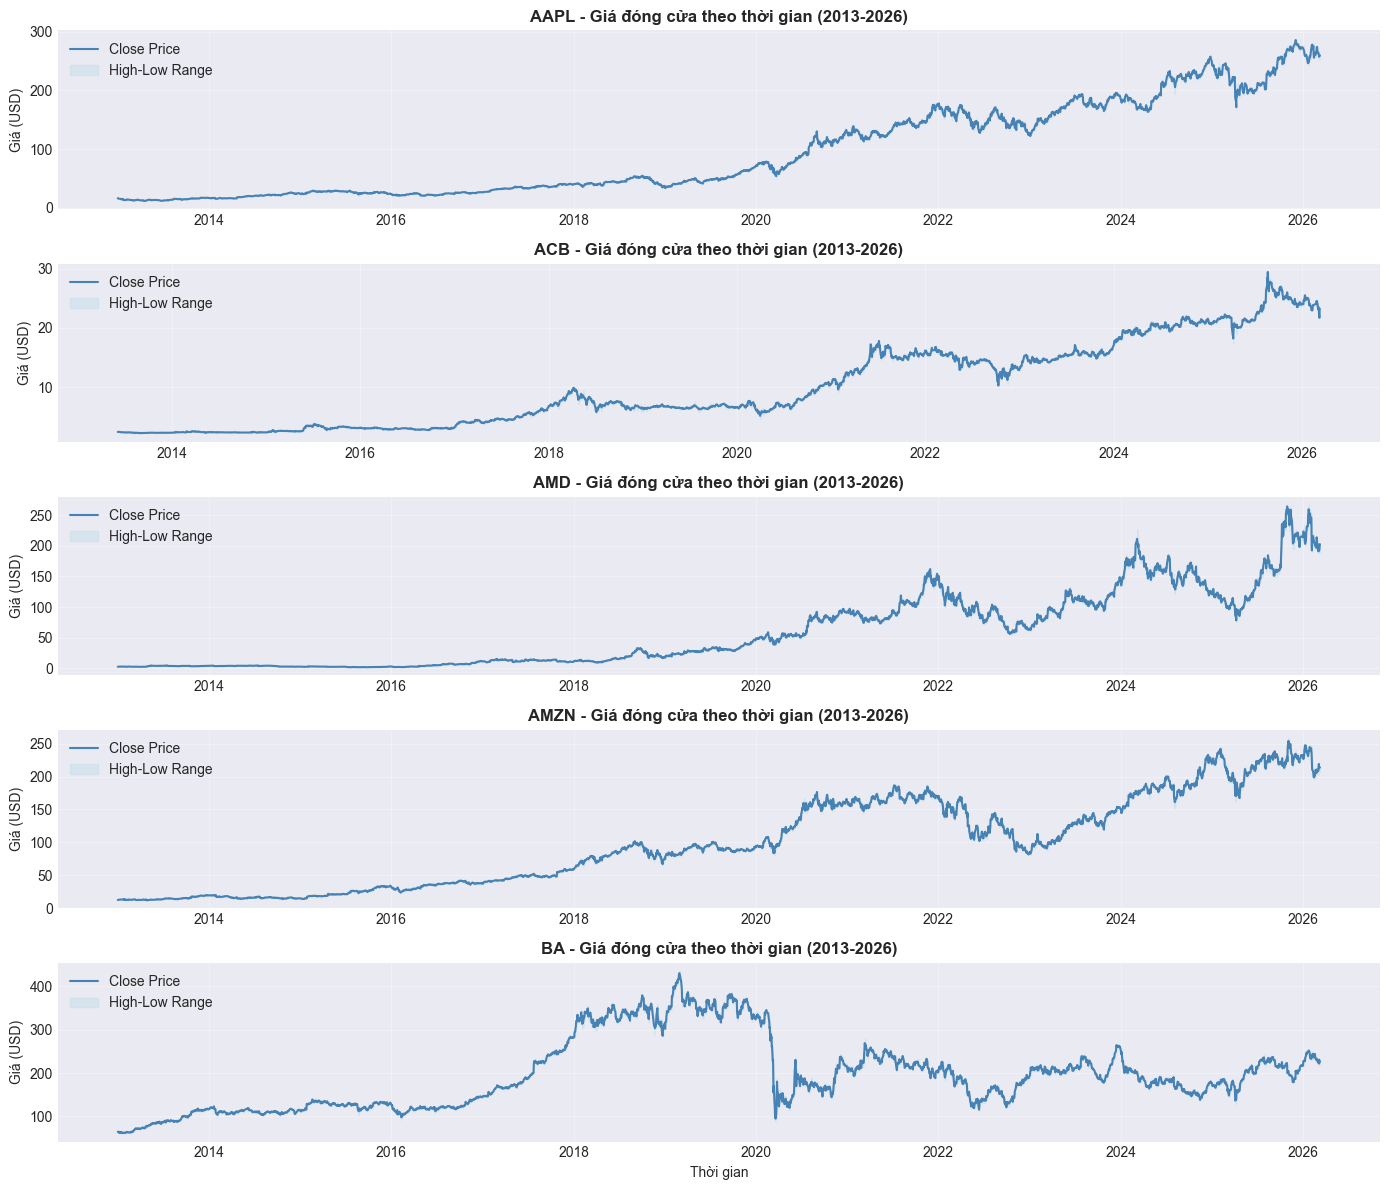

✓ Biểu đồ vẽ xong!


In [6]:
# Chuyển dữ liệu Spark sang Pandas để vẽ biểu đồ
print("Chuyển dữ liệu Spark sang Pandas...")
df_pandas = df_processed.toPandas()
df_pandas['time'] = pd.to_datetime(df_pandas['time'])

print(f"✓ Chuyển xong: {len(df_pandas):,d} rows")

# Chọn một vài cổ phiếu đại diện để vẽ biểu đồ
selected_tickers = df_pandas['ticker'].unique()[:5]
print(f"Chọn {len(selected_tickers)} cổ phiếu đại diện: {list(selected_tickers)}")

# Vẽ biểu đồ giá theo thời gian
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 12))
if len(selected_tickers) == 1:
    axes = [axes]

for idx, ticker in enumerate(selected_tickers):
    data = df_pandas[df_pandas['ticker'] == ticker].sort_values('time')
    axes[idx].plot(data['time'], data['close'], linewidth=1.5, color='steelblue', label='Close Price')
    axes[idx].fill_between(data['time'], data['low'], data['high'], alpha=0.3, color='lightblue', label='High-Low Range')
    axes[idx].set_title(f'{ticker} - Giá đóng cửa theo thời gian (2013-2026)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Giá (USD)', fontsize=10)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Thời gian', fontsize=10)
plt.tight_layout()
plt.show()

print("✓ Biểu đồ vẽ xong!")

## PHẦN 5: FEATURE ENGINEERING

Sử dụng **PySpark Window Functions** (phân chia theo ticker, sắp xếp theo time) để tạo các đặc trưng dự báo.

### Vấn đề và cách xử lý

| Vấn đề | Giải pháp |
|--------|-----------|
| **Nhiễu từ các phiên biến động nhỏ** – các ngày tăng/giảm < 1% không mang tín hiệu rõ ràng | Dùng **label có ngưỡng**: chỉ coi là tăng/giảm khi `\|future_return\| > 1.0%` |
| **OHLCV thô không đủ thông tin thị trường** | Bổ sung 47–52 features kỹ thuật (RSI, MACD, BB, ATR, ADX, CCI, ...) |

### Nhóm đặc trưng (47 features VN / 52 features US)

1. **Return & Lag**: `daily_return`, `lag1–3_close`, `lag1_volume`, `prev_high/low`, `lag5/10_return`
2. **Moving Average**: MA5, MA10, MA20, MA50, `price_vs_ma`
3. **Momentum**: RSI(7), RSI(14), Stochastic %K, Williams %R, CCI(14), Momentum 5/10
4. **Trend**: MACD, MACD Signal (SMA proxy trong Spark – EMA thực ở pipeline DL), ADX(14)
5. **Volatility**: ATR(14), ATR ratio, Bollinger upper/lower/bandwidth/%B, Volatility 5/20d
6. **Volume**: Volume change, Volume MA ratio, OBV signal
7. **Range**: High-low range, Close-open return

Cách này giúp giảm nhiễu cho bài toán tăng/giảm và cung cấp đủ ngữ cảnh thị trường để model tổng quát tốt hơn.

In [7]:
# Định nghĩa Window Function: Phân chia theo ticker, sắp xếp theo time
windowSpec = Window.partitionBy('ticker').orderBy('time')

print("Bắt đầu Feature Engineering sử dụng Window Functions...")

# Feature 1: Lag(Close)
df_features = df_processed \
    .withColumn('lag1_close', lag('close', 1).over(windowSpec)) \
    .withColumn('lag2_close', lag('close', 2).over(windowSpec)) \
    .withColumn('lag3_close', lag('close', 3).over(windowSpec)) \
    .withColumn('lag1_high',  lag('high',  1).over(windowSpec)) \
    .withColumn('lag1_low',   lag('low',   1).over(windowSpec))

# Feature 2: Lead(Close) – dùng để tạo label
df_features = df_features \
    .withColumn('next_close', lead('close', 1).over(windowSpec))

# Feature 3: Future Return
df_features = df_features \
    .withColumn('future_return', (col('next_close') - col('close')) / col('close'))

# Feature 4: Daily Return
df_features = df_features \
    .withColumn('daily_return', (col('close') - col('lag1_close')) / col('lag1_close'))

# Feature 5: Lag Return
df_features = df_features \
    .withColumn('lag1_return',  lag('daily_return',  1).over(windowSpec)) \
    .withColumn('lag5_return',  lag('daily_return',  5).over(windowSpec)) \
    .withColumn('lag10_return', lag('daily_return', 10).over(windowSpec))

# Feature 6-7: MA5 / MA10
df_features = df_features \
    .withColumn('ma5',  avg('close').over(windowSpec.rowsBetween(-4,  0))) \
    .withColumn('ma10', avg('close').over(windowSpec.rowsBetween(-9,  0)))

# ── CẢI TIẾN 2: Thêm MA20 / MA50 ──
df_features = df_features \
    .withColumn('ma20', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('ma50', avg('close').over(windowSpec.rowsBetween(-49, 0)))

# ── CẢI TIẾN 2b: Price vs MA (momentum signal) ──
df_features = df_features \
    .withColumn('price_vs_ma5',  (col('close') - col('ma5'))  / col('ma5'))  \
    .withColumn('price_vs_ma20', (col('close') - col('ma20')) / col('ma20'))

# Feature 8: Rolling volatility 5-day
from pyspark.sql.functions import stddev_pop
df_features = df_features \
    .withColumn('rolling_volatility_5', stddev_pop('daily_return').over(windowSpec.rowsBetween(-4, 0)))

# Feature 9: RSI(14)
rsi_window = windowSpec.rowsBetween(-14, 0)
df_features = df_features \
    .withColumn('price_change', col('close') - col('lag1_close')) \
    .withColumn('gain', when(col('price_change') > 0, col('price_change')).otherwise(0.0)) \
    .withColumn('loss', when(col('price_change') < 0, -col('price_change')).otherwise(0.0)) \
    .withColumn('avg_gain_14', avg('gain').over(rsi_window)) \
    .withColumn('avg_loss_14', avg('loss').over(rsi_window)) \
    .withColumn('rs_14', when(col('avg_loss_14') == 0, None).otherwise(col('avg_gain_14') / col('avg_loss_14'))) \
    .withColumn('rsi_14', when(col('avg_loss_14') == 0, 100.0).otherwise(100 - (100 / (1 + col('rs_14')))))

# Feature 10: MACD (SMA proxy trong PySpark – PySpark không hỗ trợ ewm() nội sinh;
#             EMA thực được tính lại trong pipeline học sâu – Phần 11G)
df_features = df_features \
    .withColumn('ema12_proxy', avg('close').over(windowSpec.rowsBetween(-11, 0))) \
    .withColumn('ema26_proxy', avg('close').over(windowSpec.rowsBetween(-25, 0))) \
    .withColumn('macd', col('ema12_proxy') - col('ema26_proxy')) \
    .withColumn('macd_signal', avg('macd').over(windowSpec.rowsBetween(-8, 0)))

# Feature 11: Bollinger Bands (20-day)
df_features = df_features \
    .withColumn('bb_mid', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_std', stddev_pop('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_upper', col('bb_mid') + (2 * col('bb_std'))) \
    .withColumn('bb_lower', col('bb_mid') - (2 * col('bb_std'))) \
    .withColumn('bb_bandwidth', when(col('bb_mid') != 0, (col('bb_upper') - col('bb_lower')) / col('bb_mid')).otherwise(None))

# Feature 12: Volume-based
df_features = df_features \
    .withColumn('lag1_volume', lag('volume', 1).over(windowSpec)) \
    .withColumn('volume_change', when(col('lag1_volume').isNull() | (col('lag1_volume') == 0), None)
                .otherwise((col('volume') - col('lag1_volume')) / col('lag1_volume'))) \
    .withColumn('high_low_range', when(col('close') != 0, (col('high') - col('low')) / col('close')).otherwise(None)) \
    .withColumn('close_open_return', when(col('open') != 0, (col('close') - col('open')) / col('open')).otherwise(None))

# ── CẢI TIẾN 3: Stochastic %K(14) ──
stoch_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('low14',  spark_min('low').over(stoch_w)) \
    .withColumn('high14', spark_max('high').over(stoch_w)) \
    .withColumn('stoch_k',
        when(col('high14') == col('low14'), 50.0)
        .otherwise((col('close') - col('low14')) / (col('high14') - col('low14')) * 100))

# ── Williams %R(14) – Stochastic đảo chiều ──
df_features = df_features \
    .withColumn('williams_r',
        when(col('high14') == col('low14'), -50.0)
        .otherwise((col('high14') - col('close')) / (col('high14') - col('low14')) * (-100)))

# ── CCI(14) – Commodity Channel Index (xấp xỉ bằng stddev thay vì MAD) ──
df_features = df_features \
    .withColumn('tp', (col('high') + col('low') + col('close')) / 3.0)
cci_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('tp_ma14',   avg('tp').over(cci_w)) \
    .withColumn('tp_std14',  stddev_pop('tp').over(cci_w)) \
    .withColumn('cci14',
        when(col('tp_std14') == 0, 0.0)
        .otherwise((col('tp') - col('tp_ma14')) / (0.015 * col('tp_std14'))))

# ── ADX(14) – Average Directional Index (đo độ mạnh xu hướng) ──
df_features = df_features \
    .withColumn('plus_dm',
        when((col('high') - col('lag1_high')) > (col('lag1_low') - col('low')),
             greatest(col('high') - col('lag1_high'), lit(0.0)))
        .otherwise(lit(0.0))) \
    .withColumn('minus_dm',
        when((col('lag1_low') - col('low')) > (col('high') - col('lag1_high')),
             greatest(col('lag1_low') - col('low'), lit(0.0)))
        .otherwise(lit(0.0))) \
    .withColumn('true_range', greatest(
        col('high') - col('low'),
        spark_abs(col('high') - col('lag1_close')),
        spark_abs(col('low')  - col('lag1_close'))))
adx_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('smooth_tr',   avg('true_range').over(adx_w)) \
    .withColumn('plus_di14',   when(col('smooth_tr') > 0, 100 * avg('plus_dm').over(adx_w)  / col('smooth_tr')).otherwise(0.0)) \
    .withColumn('minus_di14',  when(col('smooth_tr') > 0, 100 * avg('minus_dm').over(adx_w) / col('smooth_tr')).otherwise(0.0)) \
    .withColumn('adx14',
        when((col('plus_di14') + col('minus_di14')) == 0, 0.0)
        .otherwise(spark_abs(col('plus_di14') - col('minus_di14')) / (col('plus_di14') + col('minus_di14')) * 100))

# ── CẢI TIẾN 4: ATR(14) – Average True Range ──
df_features = df_features \
    .withColumn('atr14', avg(col('high') - col('low')).over(windowSpec.rowsBetween(-13, 0)))

# ── CẢI TIẾN 5: OBV direction signal (proxy – trung bình chiều giá 5 ngày, xấp xỉ tín hiệu OBV) ──
df_features = df_features \
    .withColumn('price_dir',
        when(col('close') > col('lag1_close'), 1.0)
        .when(col('close') < col('lag1_close'), -1.0)
        .otherwise(0.0)) \
    .withColumn('obv_signal', avg('price_dir').over(windowSpec.rowsBetween(-4, 0)))


# ── CẢI TIẾN 6: RSI(7) và RSI(21) – đa khung thời gian ──
# Tái dùng cột gain/loss đã tính từ RSI(14)
df_features = df_features \
    .withColumn('avg_gain_7',  avg('gain').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('avg_loss_7',  avg('loss').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('rsi_7',
        when(col('avg_loss_7') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_7') / col('avg_loss_7'))))) \
    .withColumn('avg_gain_21', avg('gain').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('avg_loss_21', avg('loss').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('rsi_21',
        when(col('avg_loss_21') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_21') / col('avg_loss_21')))))

# ── CẢI TIẾN 7: Volatility đa khung thời gian (10-day, 20-day) ──
df_features = df_features \
    .withColumn('rolling_volatility_10', stddev_pop('daily_return').over(windowSpec.rowsBetween(-9,  0))) \
    .withColumn('rolling_volatility_20', stddev_pop('daily_return').over(windowSpec.rowsBetween(-19, 0)))

# ── CẢI TIẾN 8: Volume MA Ratio – volume so với trung bình 20 phiên ──
df_features = df_features \
    .withColumn('avg_volume_20', avg('volume').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('volume_ma_ratio',
        when(col('avg_volume_20') == 0, None)
        .otherwise(col('volume') / col('avg_volume_20')))

# ── CẢI TIẾN 9: Momentum 5-day và 10-day ──
df_features = df_features \
    .withColumn('lag5_close',  lag('close', 5).over(windowSpec)) \
    .withColumn('lag10_close', lag('close', 10).over(windowSpec)) \
    .withColumn('momentum_5',
        when(col('lag5_close')  != 0, (col('close') - col('lag5_close'))  / col('lag5_close')).otherwise(None)) \
    .withColumn('momentum_10',
        when(col('lag10_close') != 0, (col('close') - col('lag10_close')) / col('lag10_close')).otherwise(None))

# ── CẢI TIẾN 10: Price vs MA50, MACD Histogram, Bollinger %B, ATR Ratio ──
df_features = df_features \
    .withColumn('price_vs_ma50',
        when(col('ma50') != 0, (col('close') - col('ma50')) / col('ma50')).otherwise(None)) \
    .withColumn('macd_hist', col('macd') - col('macd_signal')) \
    .withColumn('bb_pct_b',
        when((col('bb_upper') - col('bb_lower')) != 0,
             (col('close') - col('bb_lower')) / (col('bb_upper') - col('bb_lower'))).otherwise(None)) \
    .withColumn('atr_ratio',
        when(col('close') != 0, col('atr14') / col('close')).otherwise(None))

# ── NEW FEATURES: MA Cross Ratio & Range Expansion ──
df_features = df_features \
    .withColumn('ma5_vs_ma20',
        when(col('ma20') != 0, col('ma5') / col('ma20') - 1).otherwise(None)) \
    .withColumn('ma20_vs_ma50',
        when(col('ma50') != 0, col('ma20') / col('ma50') - 1).otherwise(None)) \
    .withColumn('hl5',  avg('high_low_range').over(windowSpec.rowsBetween(-4, 0))) \
    .withColumn('hl20', avg('high_low_range').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('hl_ratio',
        when(col('hl20') != 0, col('hl5') / col('hl20')).otherwise(1.0))

# ── CẢI TIẾN 11: Lag Returns 2 và 3 ──
df_features = df_features \
    .withColumn('lag2_return', lag('daily_return', 2).over(windowSpec)) \
    .withColumn('lag3_return', lag('daily_return', 3).over(windowSpec))

# ── FEATURES ĐẶC THÙ THỊ TRƯỜNG VN ─────────────────────────────────────────
vol_w = windowSpec.rowsBetween(-9, 0)

# 1. limit_hit_rate: tần suất chạm biên độ ±7% (20 phiên)
df_features = df_features \
    .withColumn('near_limit',
        when(spark_abs(col('daily_return')) >= 0.068, 1.0).otherwise(0.0)) \
    .withColumn('limit_hit_rate',
        avg('near_limit').over(windowSpec.rowsBetween(-19, 0)))

# 2. zero_change_rate: tần suất giá không đổi (10 phiên)
df_features = df_features \
    .withColumn('no_change',
        when(col('daily_return') == 0.0, 1.0).otherwise(0.0)) \
    .withColumn('zero_change_rate',
        avg('no_change').over(windowSpec.rowsBetween(-9, 0)))

# 3. vol_consistency: std/mean khối lượng (10 phiên) – bất ổn thanh khoản
df_features = df_features \
    .withColumn('vol_std10',  stddev_pop('volume').over(vol_w)) \
    .withColumn('vol_mean10', avg('volume').over(vol_w)) \
    .withColumn('vol_consistency',
        when(col('vol_mean10') > 0, col('vol_std10') / col('vol_mean10')).otherwise(None))

# 4. intraday_pos: vị trí close trong dải high-low (0=đáy, 1=trần)
df_features = df_features \
    .withColumn('intraday_pos',
        when((col('high') - col('low')) > 0,
             (col('close') - col('low')) / (col('high') - col('low'))
        ).otherwise(0.5))

# 5. ato_gap: gap giá ATO mở cửa so với close hôm trước
df_features = df_features \
    .withColumn('ato_gap',
        when(col('lag1_close') != 0,
             (col('open') - col('lag1_close')) / col('lag1_close')
        ).otherwise(None))

# ── FEATURES BỔ SUNG: Bollinger position, Overnight gap, Trend consistency ──
# bb_position: vị trí close trong dải Bollinger chuẩn hóa (-1 đến +1)
df_features = df_features \
    .withColumn('bb_position',
        when(col('bb_std') != 0,
             (col('close') - col('bb_mid')) / (2 * col('bb_std'))
        ).otherwise(lit(0.0))
    ) \
    .withColumn('overnight_gap',
        # overnight_gap: khoảng cách open/close qua đêm, tính hiệu momentum bắt đầu phiên
        when(col('lag1_close') != 0,
             (col('open') - col('lag1_close')) / col('lag1_close')
        ).otherwise(lit(0.0))
    ) \
    .withColumn('up_days_5',
        # up_days_5: tỷ lệ ngày tăng trong 5 phiên (0–1), đo độ đồng thuận xu hướng
        avg(when(col('daily_return') > 0, lit(1.0)).otherwise(lit(0.0)))
        .over(windowSpec.rowsBetween(-4, 0))
    )


# ── Cải tiến 1: 3-day forward return làm label (ít noise hơn next-day) ────
from pyspark.sql.functions import create_map, to_date
df_features = df_features     .withColumn('next_close_3d', lead('close', 3).over(windowSpec))     .withColumn('future_return_3d',
        when(col('close') != 0,
             (col('next_close_3d') - col('close')) / col('close')
        ).otherwise(None))

# ── Cải tiến 2: Sector encoding ─────────────────────────────────────────────
SECTOR_MAP = {
    # VN banks (0)
    'ACB': 0, 'BID': 0, 'CTG': 0, 'MBB': 0, 'TCB': 0, 'VCB': 0, 'VPB': 0,
    'STB': 0, 'HDB': 0,
    # VN securities (1)
    'SSI': 1,
    # VN steel & materials (2)
    'HPG': 2, 'HSG': 2, 'NKG': 2,
    # VN real estate (3)
    'KDH': 3, 'NLG': 3, 'VHM': 3, 'VIC': 3, 'VRE': 3, 'BCM': 3,
    # VN consumer & food (4)
    'MSN': 4, 'SAB': 4, 'VNM': 4, 'PNJ': 4, 'MWG': 4,
    # VN tech (5)
    'FPT': 5,
    # US mega-cap tech & semi (6)
    'AAPL': 6, 'MSFT': 6, 'GOOGL': 6, 'META': 6, 'NVDA': 6,
    'NFLX': 6, 'AMD': 6, 'INTC': 6,
    # US auto / EV (7)
    'TSLA': 7, 'F': 7, 'GM': 7,
    # US banks & finance (8)
    'JPM': 8, 'BAC': 8, 'WFC': 8, 'GS': 8,
    # US retail & consumer (9)
    'AMZN': 9, 'DIS': 9, 'COST': 9, 'WMT': 9,
    # US energy (10)
    'XOM': 10, 'CVX': 10,
    # US healthcare (11)
    'UNH': 11, 'LLY': 11,
    # US payments & fintech (12)
    'V': 12, 'MA': 12,
    # US aerospace & telecom (13)
    'BA': 13, 'VZ': 13,
    # VN energy & utilities (14)
    'GAS': 14, 'PLX': 14, 'POW': 14, 'REE': 14,
    # VN aviation & logistics (15)
    'VJC': 15, 'GMD': 15,
    # VN pharma & insurance (16)
    'DHG': 16, 'BVH': 16,
}
sector_expr = create_map(
    *[item for pair in [(lit(k), lit(float(v))) for k, v in SECTOR_MAP.items()] for item in pair]
)
df_features = df_features.withColumn('sector_idx', sector_expr[col('ticker')])

# ── Cải tiến 3: VN-Index context features ───────────────────────────────────
vnindex_path = str(Path("csv/VNINDEX.csv").resolve())
df_vni = spark.read.option("header", True).option("inferSchema", True).csv(vnindex_path)
df_vni = df_vni.withColumn('time', to_date(col('time')))                .withColumn('vni_close', col('close').cast('double'))

vni_win = Window.orderBy('time')
df_vni = df_vni     .withColumn('vni_ret1d',
        (col('vni_close') - lag('vni_close', 1).over(vni_win)) / lag('vni_close', 1).over(vni_win))     .withColumn('vni_ma5',   avg('vni_close').over(vni_win.rowsBetween(-4, 0)))     .withColumn('vni_ma20',  avg('vni_close').over(vni_win.rowsBetween(-19, 0)))     .withColumn('vni_mom5',  (col('vni_close') / lag('vni_close', 5).over(vni_win)) - 1)     .withColumn('vni_ma_ratio', col('vni_ma5') / col('vni_ma20') - 1)     .select('time', 'vni_ret1d', 'vni_mom5', 'vni_ma_ratio')

df_features = df_features     .withColumn('time_date', to_date(col('time')))     .join(df_vni.withColumnRenamed('time', 'vni_date'), col('time_date') == col('vni_date'), 'left')     .drop('vni_date', 'time_date')     .fillna(0.0, subset=['vni_ret1d', 'vni_mom5', 'vni_ma_ratio'])

# Cai tien 4: S&P 500 context features cho US (doi xung VN-Index cho VN)
sp500_path = str(Path("csv/SP500.csv").resolve())
df_sp = spark.read.option("header", True).option("inferSchema", True).csv(sp500_path)
df_sp = df_sp.withColumn('time', to_date(col('time')))                .withColumn('sp_close', col('close').cast('double'))
sp_win = Window.orderBy('time')
df_sp = df_sp     .withColumn('sp500_ret1d',
        (col('sp_close') - lag('sp_close', 1).over(sp_win)) / lag('sp_close', 1).over(sp_win))     .withColumn('sp_ma5',   avg('sp_close').over(sp_win.rowsBetween(-4, 0)))     .withColumn('sp_ma20',  avg('sp_close').over(sp_win.rowsBetween(-19, 0)))     .withColumn('sp500_mom5',  (col('sp_close') / lag('sp_close', 5).over(sp_win)) - 1)     .withColumn('sp500_ma_ratio', col('sp_ma5') / col('sp_ma20') - 1)     .select('time', 'sp500_ret1d', 'sp500_mom5', 'sp500_ma_ratio')

df_features = df_features     .withColumn('time_date', to_date(col('time')))     .join(df_sp.withColumnRenamed('time', 'sp_date'), col('time_date') == col('sp_date'), 'left')     .drop('sp_date', 'time_date')     .fillna(0.0, subset=['sp500_ret1d', 'sp500_mom5', 'sp500_ma_ratio'])


# ── Cải tiến 4: VIX macro features cho US (chỉ số sợ hãi thị trường) ────────
vix_path = str(Path("csv/VIX.csv").resolve())
try:
    df_vix = spark.read.option("header", True).option("inferSchema", True).csv(vix_path)
    df_vix = df_vix.withColumn('time', to_date(col('time'))) \
                   .withColumn('vix_close', col('close').cast('double'))
    vix_win = Window.orderBy('time')
    df_vix = df_vix \
        .withColumn('vix_ret1d',
            (col('vix_close') - lag('vix_close', 1).over(vix_win)) / lag('vix_close', 1).over(vix_win)) \
        .withColumn('vix_ma5',   avg('vix_close').over(vix_win.rowsBetween(-4, 0))) \
        .withColumn('vix_level', col('vix_close')) \
        .withColumn('vix_ma_ratio', col('vix_close') / col('vix_ma5') - 1) \
        .select('time', 'vix_level', 'vix_ret1d', 'vix_ma_ratio')
    df_features = df_features.join(df_vix, on='time', how='left')
    print("  VIX features joined OK")
except Exception as _e:
    print(f"  VIX join skipped: {_e} — dat vix_* = 0")
    for _c in ['vix_level', 'vix_ret1d', 'vix_ma_ratio']:
        df_features = df_features.withColumn(_c, lit(0.0))


# ── Cải tiến 5: Fed lãi suất — 10Y Treasury yield & 3M T-bill ───────────────
for _rate_file, _rate_col in [('csv/TNX.csv', 'tnx'), ('csv/IRX.csv', 'irx')]:
    _rate_path = str(Path(_rate_file).resolve())
    try:
        df_rate = spark.read.option("header", True).option("inferSchema", True).csv(_rate_path)
        df_rate = df_rate.withColumn('time', to_date(col('time'))) \
                         .withColumn(f'{_rate_col}_rate', col('rate').cast('double'))
        _rate_win = Window.orderBy('time')
        df_rate = df_rate \
            .withColumn(f'{_rate_col}_chg1d',
                col(f'{_rate_col}_rate') - lag(f'{_rate_col}_rate', 1).over(_rate_win)) \
            .withColumn(f'{_rate_col}_ma5',
                avg(f'{_rate_col}_rate').over(_rate_win.rowsBetween(-4, 0))) \
            .withColumn(f'{_rate_col}_spread',
                col(f'{_rate_col}_rate') - col(f'{_rate_col}_ma5')) \
            .select('time', f'{_rate_col}_rate', f'{_rate_col}_chg1d', f'{_rate_col}_spread')
        df_features = df_features.join(df_rate, on='time', how='left')
        print(f"  {_rate_col.upper()} features joined OK")
    except Exception as _e:
        print(f"  {_rate_col.upper()} join skipped: {_e}")
        for _c in [f'{_rate_col}_rate', f'{_rate_col}_chg1d', f'{_rate_col}_spread']:
            df_features = df_features.withColumn(_c, lit(0.0))

df_features = df_features \
    .withColumn('rs_vs_vnindex',
        col('daily_return') - col('vni_ret1d')) \
    .withColumn('price_min_20',
        spark_min('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('price_max_20',
        spark_max('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('price_percentile_20',
        when((col('price_max_20') - col('price_min_20')) > 0,
             (col('close') - col('price_min_20')) /
             (col('price_max_20') - col('price_min_20'))
        ).otherwise(lit(0.5)))

print("\u2713 Feature Engineering xong!")
print(f"  3-day label, sector_idx, VN-Index, S&P500, VIX, TNX/IRX (Fed) features da duoc them")
print(f"\nDu lieu sau feature engineering: {df_features.count():,d} rows")
df_features.select('time', 'ticker', 'close', 'future_return', 'future_return_3d',
                   'sector_idx', 'vni_ret1d', 'sp500_ret1d').show(5)
# ── CAI TIEN MOI: Proximity 52-week high, 3-day volume accumulation, RS vs S&P500 ──
# proximity_52w_high: close / max_close_252d — breakout/momentum signal
df_features = df_features     .withColumn('_max_close_252',
        spark_max('close').over(windowSpec.rowsBetween(-251, 0)))     .withColumn('proximity_52w_high',
        when(col('_max_close_252') > 0,
             col('close') / col('_max_close_252')
        ).otherwise(lit(1.0)))     .drop('_max_close_252')

# volume_spike_3d: avg 3-day volume / avg 20-day volume — detects multi-day accumulation
df_features = df_features     .withColumn('volume_spike_3d',
        when(col('avg_volume_20') > 0,
             avg('volume').over(windowSpec.rowsBetween(-2, 0)) / col('avg_volume_20')
        ).otherwise(lit(1.0)))

# rs_vs_sp500: daily_return minus S&P500 return — positive = outperforming US market
df_features = df_features     .withColumn('rs_vs_sp500',
        col('daily_return') - col('sp500_ret1d'))

df_features.select('time', 'ticker', 'close', 'future_return', 'future_return_3d',
                   'proximity_52w_high', 'volume_spike_3d', 'rs_vs_sp500').show(5)


Bắt đầu Feature Engineering sử dụng Window Functions...
  VIX features joined OK
  TNX join skipped: [PATH_NOT_FOUND] Path does not exist: file:/D:/CODE/DoAnTotNgiep/csv/TNX.csv. SQLSTATE: 42K03
  IRX join skipped: [PATH_NOT_FOUND] Path does not exist: file:/D:/CODE/DoAnTotNgiep/csv/IRX.csv. SQLSTATE: 42K03
✓ Feature Engineering xong!
  3-day label, sector_idx, VN-Index, S&P500, VIX, TNX/IRX (Fed) features da duoc them

Du lieu sau feature engineering: 192,255 rows
+-------------------+------+------------------+--------------------+--------------------+----------+--------------------+--------------------+
|               time|ticker|             close|       future_return|    future_return_3d|sector_idx|           vni_ret1d|         sp500_ret1d|
+-------------------+------+------------------+--------------------+--------------------+----------+--------------------+--------------------+
|2013-01-02 00:00:00|  AAPL|16.581398010253906|-0.01262229353023...|-0.04577089728010...|       6.0| 

## PHẦN 6: LÀM SẠCH DỮ LIỆU SAU FEATURE ENGINEERING

Sau khi tạo features bằng lag() và window functions, sẽ có dòng null:
- Dòng đầu tiên mỗi ticker sẽ có null trong lag columns
- Dòng cuối cùng mỗi ticker sẽ có null trong `next_close` và `future_return`
- Các dòng có biến động nhỏ quanh 0 cũng được gán `label = null` để loại bỏ nhiễu

Bước này sẽ:
- **Drop tất cả null rows**
- **Xác minh dữ liệu đã sạch**
- **Kiểm tra phân phối label** (có cân bằng không?)

In [8]:
# Drop null values do lag/window functions (label chưa tồn tại – xử lý sau khi tách market)
print("Dropping null values (features only)...")
count_before = df_features.count()
df_features  = df_features.dropna(
    subset=[c for c in df_features.columns if c not in ('label', 'next_close')]
)
count_after  = df_features.count()
print(f"✓ Loại bỏ {count_before - count_after:,d} rows null ({(count_before-count_after)/count_before*100:.1f}%)")
print(f"  Dữ liệu sau drop null: {count_after:,d} rows")

# Winsorize: clip extreme outliers
print("\nWinsorizing extreme feature values...")
clip_map = {
    "daily_return":      (-0.15, 0.15),
    "lag1_return":       (-0.15, 0.15),
    "lag2_return":       (-0.15, 0.15),
    "lag3_return":       (-0.15, 0.15),
    "close_open_return": (-0.15, 0.15),
    "momentum_5":        (-0.35, 0.35),
    "momentum_10":       (-0.50, 0.50),
    "volume_change":     (-3.0,  5.0),
    "volume_ma_ratio":   (0.05,  8.0),
    "high_low_range":    (0.0,   0.20),
    "price_vs_ma5":      (-0.20, 0.20),
    "price_vs_ma20":     (-0.30, 0.30),
    "price_vs_ma50":     (-0.40, 0.40),
    "bb_pct_b":          (-0.50, 1.50),
    "atr_ratio":         (0.0,   0.10),
    "rsi_7":             (0.0,  100.0),
    "rsi_14":            (0.0,  100.0),
    "rsi_21":            (0.0,  100.0),
    "stoch_k":           (0.0,  100.0),
    # Features bổ sung
    "bb_position":   (-1.5, 1.5),
    "overnight_gap": (-0.10, 0.10),
    "up_days_5":     (0.0, 1.0),
    "rs_vs_vnindex":       (-0.10, 0.10),
    "price_percentile_20": (0.0,   1.0),
}
for cname, (lo, hi) in clip_map.items():
    if cname in df_features.columns:
        df_features = df_features.withColumn(
            cname,
            when(col(cname) < lo, lo).when(col(cname) > hi, hi).otherwise(col(cname))
        )
print(f"✓ Winsorized {len(clip_map)} features")
print(f"\n✓ df_features sẵn sàng: {df_features.count():,d} rows — label sẽ tạo riêng cho US/VN ở PHẦN 7")


Dropping null values (features only)...
✓ Loại bỏ 12,797 rows null (6.7%)
  Dữ liệu sau drop null: 179,458 rows

Winsorizing extreme feature values...
✓ Winsorized 24 features

✓ df_features sẵn sàng: 179,458 rows — label sẽ tạo riêng cho US/VN ở PHẦN 7


## PHẦN 6B: PHÂN TÍCH TƯƠNG QUAN FEATURES (EDA mở rộng)

Trước khi đưa vào model, kiểm tra **ma trận tương quan** giữa các features kỹ thuật để:
- Phát hiện các cặp features tương quan cao (đa cộng tuyến) có thể gây nhiễu
- Hiểu cấu trúc dữ liệu: nhóm momentum, volatility, trend liên hệ với nhau ra sao

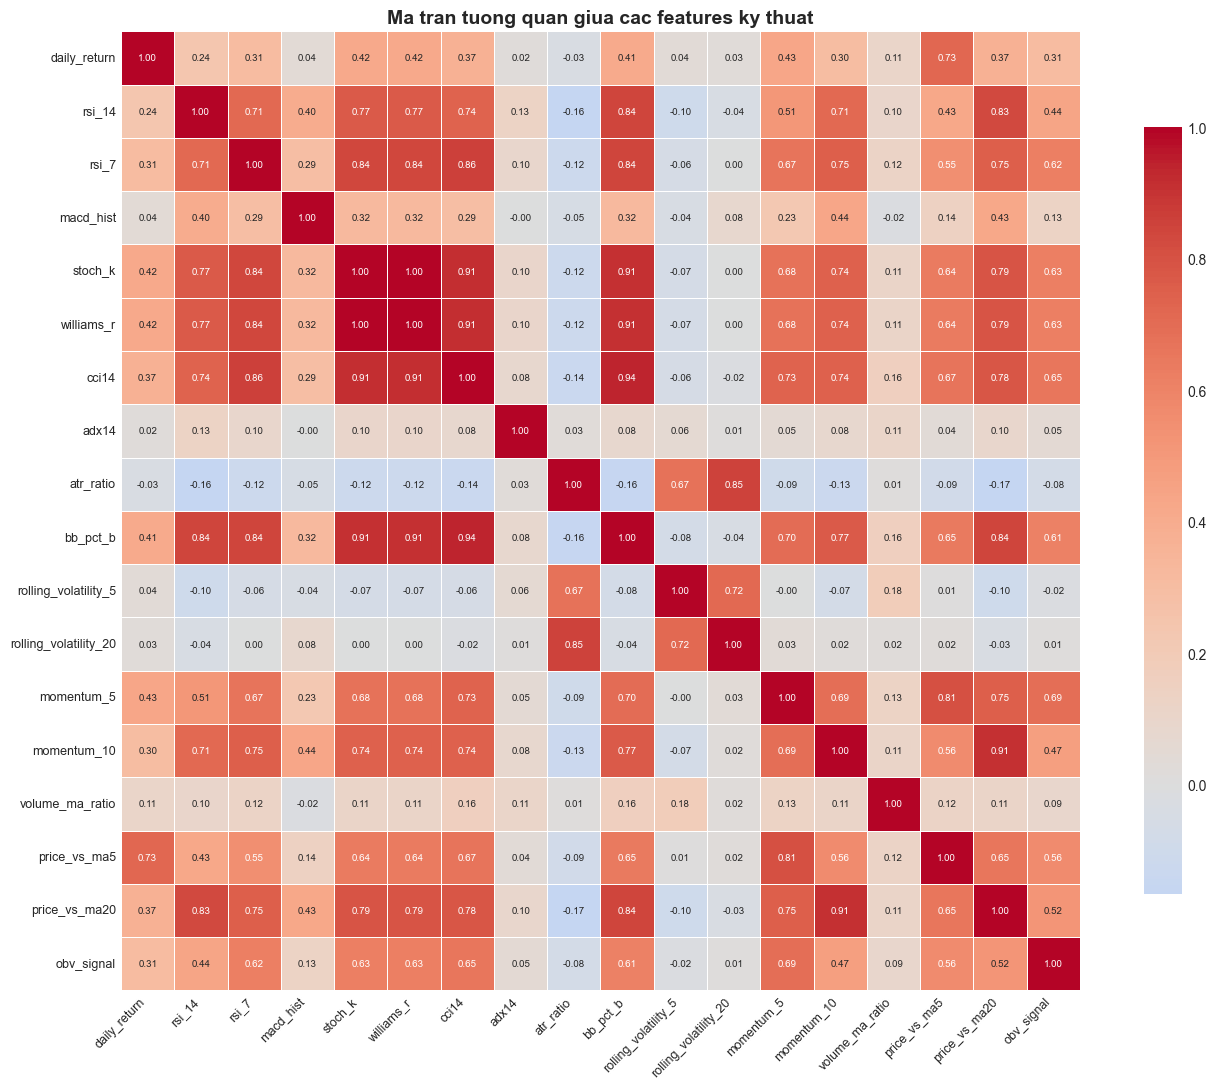

Cac cap features tuong quan cao (|r| > 0.8) - co the gay da cong tuyen:
  rsi_14                 <-> bb_pct_b              : +0.842
  rsi_14                 <-> price_vs_ma20         : +0.830
  rsi_7                  <-> stoch_k               : +0.839
  rsi_7                  <-> williams_r            : +0.839
  rsi_7                  <-> cci14                 : +0.860
  rsi_7                  <-> bb_pct_b              : +0.841
  stoch_k                <-> williams_r            : +1.000
  stoch_k                <-> cci14                 : +0.914
  stoch_k                <-> bb_pct_b              : +0.908
  williams_r             <-> cci14                 : +0.914
  williams_r             <-> bb_pct_b              : +0.908
  cci14                  <-> bb_pct_b              : +0.941
  atr_ratio              <-> rolling_volatility_20 : +0.852
  bb_pct_b               <-> price_vs_ma20         : +0.844
  momentum_5             <-> price_vs_ma5          : +0.809
  momentum_10            <->

In [9]:
# Correlation heatmap cua cac features ky thuat chinh
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ['daily_return','rsi_14','rsi_7','macd_hist','stoch_k','williams_r','cci14',
             'adx14','atr_ratio','bb_pct_b','rolling_volatility_5','rolling_volatility_20',
             'momentum_5','momentum_10','volume_ma_ratio','price_vs_ma5','price_vs_ma20',
             'obv_signal']
corr_cols = [c for c in corr_cols if c in df_features.columns]

# Lay mau du lieu sang pandas de tinh tuong quan
corr_pd = df_features.select(*corr_cols).dropna().limit(20000).toPandas()
corr = corr_pd.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
plt.title('Ma tran tuong quan giua cac features ky thuat', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Liet ke cac cap features tuong quan cao
print("Cac cap features tuong quan cao (|r| > 0.8) - co the gay da cong tuyen:")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            print(f"  {corr.columns[i]:22s} <-> {corr.columns[j]:22s}: {corr.iloc[i,j]:+.3f}")
            found = True
if not found:
    print("  (Khong co cap nao |r| > 0.8 - features kha doc lap, tot cho model)")


## PHẦN 7: TÁCH THỊ TRƯỜNG US vs VN + TẠO LABEL

Sau khi có đầy đủ features, chia `df_features` thành 2 nhánh. **Cả 2 thị trường dùng cùng định nghĩa label `next-day ±1.5%`** — đây là kết quả tốt nhất sau thực nghiệm so sánh 8 cấu hình label khác nhau.

| Thị trường | Label | Edge (acc − naive) | AUC | Kết luận |
|------------|-------|--------------------|-----|----------|
| **US** | next-day ±1.5% | **+0.8%** | ~0.53 | Gần như random — thị trường hiệu quả (EMH) |
| **VN** | next-day ±1.5% | **+7.3%** | ~0.57 | Có signal thật — thị trường kém hiệu quả |

> **Phát hiện quan trọng**: VN dự báo được tốt hơn US ~9 lần. Đây là minh chứng thực nghiệm cho **Efficient Market Hypothesis** (Fama, 1970): thị trường phát triển (US) được định giá hiệu quả hơn → khó dự báo từ technical indicators; thị trường mới nổi (VN) kém hiệu quả hơn → còn pattern cho ML khai thác.
>
> Trước đây thử VN dùng `3-day forward 0.8%` chỉ đạt edge +5.5%; chuyển sang `next-day 1.5%` tăng lên +7.3%.

Từ đây **tất cả bước tiếp theo chạy riêng** cho từng thị trường (scaler, class weight, feature list riêng).

In [10]:
from pyspark.sql.functions import year, avg as spark_avg

US_TICKERS = [
    'AAPL','AMZN','F','GM','GOOGL','META','MSFT','NFLX','AMD','NVDA','TSLA',
    'JPM','BAC','WFC','GS','XOM','CVX','DIS','COST','WMT','UNH','LLY','V','MA',
    'INTC','BA','VZ',
]
VN_TICKERS = [
    'ACB','BID','CTG','FPT','GAS','HPG','HSG','KDH','MBB','MSN','NKG','NLG',
    'PNJ','SAB','SSI','TCB','VCB','VHM','VIC','VNM','VPB',
    'STB','HDB','VRE','BCM','MWG','PLX','POW','VJC','REE','DHG','GMD','BVH',
]

# Tat ca ma VN hop nhat thanh mot nhom
print('=' * 60)
print('DANH SACH MA VN')
print('=' * 60)
print(f'  Tong {len(VN_TICKERS)} ma VN: {VN_TICKERS}')

# Tao label: ca 2 thi truong dung next-day 1.5% (thuc nghiem cho ket qua tot nhat)
# US: next-day label
def create_labels(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return') >  threshold, 1.0)
           .when(col('future_return') < -threshold, 0.0)
           .otherwise(None))
        .dropna(subset=['label', 'next_close'])
        .withColumn('year', year('time'))
    )

# VN: 3-day forward label (giam noise thi truong VN)
def create_labels_3d(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return_3d') >  threshold, 1.0)
           .when(col('future_return_3d') < -threshold, 0.0)
           .otherwise(None))
        .dropna(subset=['label', 'next_close_3d'])
        .withColumn('year', year('time'))
    )

df_us = create_labels(df_features.filter(col('ticker').isin(US_TICKERS)), threshold=0.010)
# VN tang nguong len 2.0% de loc nhieu (thi truong VN bien dong manh hon)
df_vn = create_labels(df_features.filter(col('ticker').isin(VN_TICKERS)), threshold=0.020)

print('\n' + '=' * 60)
print('THONG KE 3 NHOM')
print('=' * 60)
for name, df_m in [('US', df_us), ('VN', df_vn)]:
    n = df_m.count()
    dist = {int(r['label']): r['count'] for r in df_m.groupBy('label').count().collect()}
    n0, n1 = dist.get(0, 0), dist.get(1, 0)
    tickers_m = sorted([r['ticker'] for r in df_m.select('ticker').distinct().collect()])
    print(f'  {name:<10}: {n:,d} rows | L0={n0:,d}({n0/n*100:.0f}%) L1={n1:,d}({n1/n*100:.0f}%)')
    print(f'             Tickers: {", ".join(tickers_m)}')


# ── Full DataFrames incl. NEUTRAL (label=2.0) — dung lam context cho LSTM sequences ──
# Giu lai TAT CA hang: UP=1.0, DOWN=0.0, NEUTRAL=2.0 (khong drop neutral)
# LSTM dung day de build sequences khong bi gap thoi gian khi neutral bi xoa
def create_labels_full(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return') >  threshold, 1.0)
           .when(col('future_return') < -threshold, 0.0)
           .otherwise(2.0))
        .dropna(subset=['next_close'])
        .withColumn('year', year('time'))
    )

df_us_all = create_labels_full(df_features.filter(col('ticker').isin(US_TICKERS)), threshold=0.010)
df_vn_all = create_labels_full(df_features.filter(col('ticker').isin(VN_TICKERS)), threshold=0.020)
print(f'  df_us_all: {df_us_all.count():,d} rows (incl. neutral=2.0)')
print(f'  df_vn_all: {df_vn_all.count():,d} rows (incl. neutral=2.0)')

DANH SACH MA VN
  Tong 33 ma VN: ['ACB', 'BID', 'CTG', 'FPT', 'GAS', 'HPG', 'HSG', 'KDH', 'MBB', 'MSN', 'NKG', 'NLG', 'PNJ', 'SAB', 'SSI', 'TCB', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB', 'STB', 'HDB', 'VRE', 'BCM', 'MWG', 'PLX', 'POW', 'VJC', 'REE', 'DHG', 'GMD', 'BVH']

THONG KE 3 NHOM
  US        : 40,990 rows | L0=19,023(46%) L1=21,967(54%)
             Tickers: AAPL, AMD, AMZN, BA, BAC, COST, CVX, DIS, F, GM, GOOGL, GS, INTC, JPM, LLY, MA, META, MSFT, NFLX, NVDA, TSLA, UNH, V, VZ, WFC, WMT, XOM
  VN        : 20,969 rows | L0=9,483(45%) L1=11,486(55%)
             Tickers: ACB, BCM, BID, BVH, CTG, DHG, FPT, GAS, GMD, HDB, HPG, HSG, KDH, MBB, MSN, MWG, NKG, NLG, PLX, PNJ, POW, REE, SAB, SSI, STB, TCB, VCB, VHM, VIC, VJC, VNM, VPB, VRE
  df_us_all: 89,120 rows (incl. neutral=2.0)
  df_vn_all: 90,338 rows (incl. neutral=2.0)


## PHẦN 8: ĐỊNH NGHĨA PIPELINE FUNCTIONS

- **`run_spark_pipeline(df, market)`** — Train LR, RF, GBT, SVC + Ensemble (PySpark ML)
- **`run_xgb_pipeline(df, market)`** — Train XGBoost voi EMA MACD thuc (pandas/sklearn)

Goi moi ham 2 lan: mot lan cho US, mot lan cho VN.


In [11]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.feature import StandardScaler as SparkSS
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier,
                                        GBTClassifier, LinearSVC)
from pyspark.ml.evaluation import (MulticlassClassificationEvaluator,
                                    BinaryClassificationEvaluator)
from pyspark.sql.functions import log1p as spark_log1p

# Features chung cho ca 2 thi truong
COMMON_FEATURES = [
    # Returns & lags
    'daily_return', 'lag1_return', 'lag2_return', 'lag3_return',
    'lag5_return',  'lag10_return',
    # Trend
    'price_vs_ma5', 'price_vs_ma20','price_vs_ma50',
    'momentum_5',   'momentum_10',
    # Oscillators
    'rsi_7', 'rsi_14', 'macd_hist',
    'stoch_k', 'williams_r', 'cci14',
    # Volatility & trend strength
    'rolling_volatility_5', 'rolling_volatility_20',
    'bb_bandwidth', 'bb_pct_b', 'atr_ratio', 'adx14',
    # Volume
    'log_volume', 'log_lag1_volume', 'volume_change', 'volume_ma_ratio',
    # Price action
    'high_low_range', 'close_open_return', 'obv_signal',
    # Universal microstructure
    'intraday_pos', 'vol_consistency',
    # Sector & ticker encoding (per-market values nhung column ton tai cho ca 2)
    'sector_idx', 'ticker_idx',
    # Features bổ sung: BB position, overnight gap, trend consistency
    'bb_position', 'overnight_gap', 'up_days_5',
    # Breakout & multi-day accumulation signals
    'proximity_52w_high', 'volume_spike_3d',
    # MA crossover ratios & range expansion
    'ma5_vs_ma20', 'ma20_vs_ma50', 'hl_ratio',
]

# Features dac thu chi co y nghia voi VN
VN_ONLY_FEATURES = [
    'limit_hit_rate',     # tan suat cham bien do +-7% (VN co bien, US khong co)
    'zero_change_rate',   # tan suat gia khong doi (VN thanh khoan mong)
    'ato_gap',            # gap ATO so voi close hom truoc (VN co phien ATO)
    'vni_ret1d', 'vni_mom5', 'vni_ma_ratio',  # VN-Index context
    'rs_vs_vnindex',
    'price_percentile_20',
]

# Features dac thu chi co y nghia voi US (S&P 500 context)
US_ONLY_FEATURES = [
    'sp500_ret1d', 'sp500_mom5', 'sp500_ma_ratio',  # S&P 500 context
    'vix_level', 'vix_ret1d', 'vix_ma_ratio',        # VIX macro fear index
    'tnx_rate', 'tnx_chg1d', 'tnx_spread',           # 10Y Treasury yield (Fed policy)
    'irx_rate', 'irx_chg1d', 'irx_spread',           # 3M T-bill (short-term rate)
    'rs_vs_sp500',                                    # Relative strength vs S&P 500
]

# Feature list rieng cho tung thi truong
FEATURE_COLS_US = COMMON_FEATURES + US_ONLY_FEATURES
FEATURE_COLS_VN = COMMON_FEATURES + VN_ONLY_FEATURES

# Giu lai FEATURE_COLS de backward-compat (mac dinh = VN co day du features)
FEATURE_COLS = FEATURE_COLS_VN

print(f'COMMON_FEATURES   : {len(COMMON_FEATURES)} features')
print(f'VN_ONLY_FEATURES  : {len(VN_ONLY_FEATURES)} features')
print(f'US_ONLY_FEATURES  : {len(US_ONLY_FEATURES)} features')
print(f'FEATURE_COLS_US   : {len(FEATURE_COLS_US)} features')
print(f'FEATURE_COLS_VN   : {len(FEATURE_COLS_VN)} features')


def run_spark_pipeline(df_market, market_name, feature_cols=None):
    # Local imports de tranh xung dot voi sklearn namespace
    from pyspark.ml.classification import (LogisticRegression as SparkLR,
                                            RandomForestClassifier as SparkRF,
                                            GBTClassifier as SparkGBT,
                                            LinearSVC as SparkSVC)
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    sep = '=' * 70
    print(f'\n{sep}\nSPARK ML — {market_name} STOCKS ({len(feature_cols)} features)\n{sep}')

    df_tr = df_market.filter(col('year') <= 2021)
    df_ts = df_market.filter(col('year') >= 2022)
    n_tr, n_ts = df_tr.count(), df_ts.count()
    print(f'  Train: {n_tr:,d} | Test: {n_ts:,d}')

    ti_m = StringIndexer(inputCol='ticker', outputCol='ticker_idx', handleInvalid='keep').fit(df_tr)
    def prep(df):
        return (ti_m.transform(df)
                .withColumn('log_volume',      spark_log1p(col('volume').cast('double')))
                .withColumn('log_lag1_volume', spark_log1p(col('lag1_volume').cast('double'))))
    df_tr = prep(df_tr)
    df_ts = prep(df_ts)

    va   = VectorAssembler(inputCols=feature_cols, outputCol='raw_features', handleInvalid='skip')
    sc_m = SparkSS(inputCol='raw_features', outputCol='features', withMean=True, withStd=True).fit(va.transform(df_tr))
    df_tr_asm = sc_m.transform(va.transform(df_tr))
    df_ts_asm = sc_m.transform(va.transform(df_ts))

    lc  = {r['label']: r['count'] for r in df_tr.groupBy('label').count().collect()}
    tot = sum(lc.values())
    df_tr_asm = df_tr_asm.withColumn('weight',
        when(col('label') == 1.0, tot/(2.0*lc.get(1.0,1))).otherwise(tot/(2.0*lc.get(0.0,1))))

    # Validation set grid search (phan tach theo thoi gian, tranh lookahead)
    df_sub_tr = df_tr_asm.filter(col('year') <= 2019)
    df_val    = df_tr_asm.filter((col('year') >= 2020) & (col('year') <= 2021))
    n_sub, n_val = df_sub_tr.count(), df_val.count()
    print(f'  Grid search | sub_train={n_sub:,d} | val={n_val:,d}')
    auc_ev_gs = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction', labelCol='label', metricName='areaUnderROC')

    # RF grid search
    best_rf_auc, best_rf_params = -1.0, {'maxDepth': 6, 'numTrees': 200}
    for _d in [4, 6]:
        for _n in [100, 200]:
            try:
                _pv = SparkRF(featuresCol='features', labelCol='label', weightCol='weight',
                                             numTrees=_n, maxDepth=_d, minInstancesPerNode=10,
                                             featureSubsetStrategy='sqrt', seed=42
                                            ).fit(df_sub_tr).transform(df_val)
                _auc = auc_ev_gs.evaluate(_pv)
            except Exception: _auc = 0.0
            print(f'    RF depth={_d} trees={_n}: val_AUC={_auc:.4f}')
            if _auc > best_rf_auc:
                best_rf_auc, best_rf_params = _auc, {'maxDepth': _d, 'numTrees': _n}

    # GBT grid search
    best_gbt_auc, best_gbt_params = -1.0, {'maxDepth': 5, 'stepSize': 0.03}
    for _d in [3, 5]:
        for _s in [0.03, 0.1]:
            try:
                _pv = SparkGBT(featuresCol='features', labelCol='label', maxIter=100,
                                    maxDepth=_d, stepSize=_s, subsamplingRate=0.7,
                                    featureSubsetStrategy='sqrt', minInstancesPerNode=5, seed=42
                                   ).fit(df_sub_tr).transform(df_val)
                _auc = auc_ev_gs.evaluate(_pv)
            except Exception: _auc = 0.0
            print(f'    GBT depth={_d} step={_s}: val_AUC={_auc:.4f}')
            if _auc > best_gbt_auc:
                best_gbt_auc, best_gbt_params = _auc, {'maxDepth': _d, 'stepSize': _s}

    print(f'  Best RF : {best_rf_params} (val_AUC={best_rf_auc:.4f})')
    print(f'  Best GBT: {best_gbt_params} (val_AUC={best_gbt_auc:.4f})')

    models_cfg = {
        'LR':  SparkLR(featuresCol='features', labelCol='label', weightCol='weight',
                                   maxIter=200, regParam=0.001, elasticNetParam=0.0),
        'RF':  SparkRF(featuresCol='features', labelCol='label', weightCol='weight',
                                       numTrees=best_rf_params['numTrees'],
                                       maxDepth=best_rf_params['maxDepth'],
                                       minInstancesPerNode=10,
                                       featureSubsetStrategy='sqrt',
                                       seed=42),
        'GBT': SparkGBT(featuresCol='features', labelCol='label',
                              maxIter=200, maxDepth=best_gbt_params['maxDepth'],
                              stepSize=best_gbt_params['stepSize'], subsamplingRate=0.7,
                              featureSubsetStrategy='sqrt', minInstancesPerNode=5, seed=42),
        'SVC': SparkSVC(featuresCol='features', labelCol='label', maxIter=200, regParam=0.001),
    }
    print('  Training models:')
    trained, predictions = {}, {}
    for mname, mdl in models_cfg.items():
        print(f'    {mname}...', end=' ', flush=True)
        fitted = mdl.fit(df_tr_asm)
        predictions[mname] = fitted.transform(df_ts_asm)
        trained[mname] = fitted
        print('ok')

    acc_ev = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
    auc_ev = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction', labelCol='label', metricName='areaUnderROC')
    metrics = {}
    print(f'\n  {"Model":<10} {"Accuracy":>10} {"AUC-ROC":>10}')
    print('  ' + '-' * 32)
    for mname, preds in predictions.items():
        acc = acc_ev.evaluate(preds)
        try:    auc = auc_ev.evaluate(preds)
        except: auc = float('nan')
        metrics[mname] = {'accuracy': acc, 'auc': auc}
        print(f'  {mname:<10} {acc:>10.4f} {auc:>10.4f}')

    # Weight ensemble bằng AUC thay vì accuracy: AUC ổn định hơn với imbalanced data
    valid_metrics = {k: v for k, v in metrics.items()
                     if not (isinstance(v['auc'], float)
                     and v['auc'] != v['auc'])}  # bỏ NaN
    total_auc = sum(v['auc'] for v in valid_metrics.values())
    w = {}
    for k, v in metrics.items():
        if k in valid_metrics and total_auc > 0:
            w[k] = v['auc'] / total_auc
        else:
            w[k] = 0.0
    ens_df = (
        predictions['LR'].select('time','ticker','label','next_close', col('prediction').alias('p_lr'))
        .join(predictions['RF'].select('time','ticker', col('prediction').alias('p_rf')),  ['time','ticker'])
        .join(predictions['GBT'].select('time','ticker',col('prediction').alias('p_gbt')), ['time','ticker'])
        .join(predictions['SVC'].select('time','ticker',col('prediction').alias('p_svc')), ['time','ticker'])
        .withColumn('vote',
            col('p_lr')*lit(w['LR']) + col('p_rf')*lit(w['RF']) +
            col('p_gbt')*lit(w['GBT']) + col('p_svc')*lit(w['SVC']))
        .withColumn('prediction', when(col('vote') >= 0.5, 1.0).otherwise(0.0))
    )
    ens_acc = acc_ev.evaluate(ens_df)
    metrics['Ensemble'] = {'accuracy': ens_acc, 'auc': float('nan')}
    print(f'  {"Ensemble":<10} {ens_acc:>10.4f}')

    ticker_acc = {}
    for mname, preds in {**predictions, 'Ensemble': ens_df}.items():
        ta = (preds
              .withColumn('correct', (col('prediction')==col('label')).cast('int'))
              .groupBy('ticker').agg((spark_sum('correct')/count('*')).alias('acc'))
              .toPandas().set_index('ticker')['acc'])
        ticker_acc[mname] = ta

    fi = sorted(zip(feature_cols, trained['RF'].featureImportances), key=lambda x: -x[1])
    print(f'\n  Top 5 features ({market_name}): ' + ', '.join(f[0] for f in fi[:5]))
    print(f'\nok {market_name} Spark pipeline xong!')
    return {'market': market_name, 'n_train': n_tr, 'n_test': n_ts,
            'metrics': metrics, 'predictions': predictions,
            'ensemble': ens_df, 'ticker_acc': ticker_acc,
            'feature_importance': fi, 'features': feature_cols}

print('ok run_spark_pipeline() dinh nghia xong')


COMMON_FEATURES   : 42 features
VN_ONLY_FEATURES  : 8 features
US_ONLY_FEATURES  : 13 features
FEATURE_COLS_US   : 55 features
FEATURE_COLS_VN   : 50 features
ok run_spark_pipeline() dinh nghia xong


In [12]:
def run_xgb_pipeline(df_spark, market_name, feature_cols=None):
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    from xgboost import XGBClassifier as XGBCls
    from sklearn.preprocessing import StandardScaler as SS
    from sklearn.metrics import accuracy_score, roc_auc_score

    sep = '=' * 70
    print(f'\n{sep}\nXGBOOST — {market_name} STOCKS ({len(feature_cols)} features)\n{sep}')

    XGB_BASE = [c for c in feature_cols if c not in
                ('ticker_idx','macd_hist','log_volume','log_lag1_volume')]
    needed = list(set(['time','ticker','close','volume','lag1_volume','label','year',
                        'next_close'] + XGB_BASE))
    avail  = [c for c in needed if c in df_spark.columns]

    df_pd = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker','time']).reset_index(drop=True)
    print(f'  {len(df_pd):,d} rows | {df_pd["ticker"].nunique()} tickers')

    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']      = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    feat_xgb = [c for c in XGB_BASE if c in df_pd.columns]
    feat_xgb += ['log_volume','log_lag1_volume','macd_real','macd_hist_real']
    feat_xgb  = [c for c in feat_xgb if c in df_pd.columns]

    df_pd = df_pd.dropna(subset=feat_xgb + ['label'])
    df_tr = df_pd[df_pd['year'] <= 2021]
    df_ts = df_pd[df_pd['year'] >= 2022]
    print(f'  Train: {len(df_tr):,d} | Test: {len(df_ts):,d}')

    # Validation set grid search (tranh lookahead)
    df_sub_tr = df_tr[df_tr['year'] <= 2019]
    df_val    = df_tr[(df_tr['year'] >= 2020) & (df_tr['year'] <= 2021)]
    sc_gs = SS()
    X_sub = sc_gs.fit_transform(df_sub_tr[feat_xgb].values.astype(np.float64))
    y_sub = df_sub_tr['label'].values.astype(int)
    X_val = sc_gs.transform(df_val[feat_xgb].values.astype(np.float64))
    y_val = df_val['label'].values.astype(int)
    cnt_sub = np.bincount(y_sub)
    spw_sub = float(cnt_sub[0]) / float(max(int(cnt_sub[1]) if len(cnt_sub) > 1 else 1, 1))

    print(f'  XGB grid search | sub_train={len(df_sub_tr):,d} | val={len(df_val):,d}')
    best_xgb_auc, best_xgb_params = -1.0, {'max_depth': 5, 'learning_rate': 0.03}
    for _d in [3, 5]:
        for _lr in [0.03, 0.1]:
            m_gs = XGBCls(n_estimators=200, max_depth=_d, learning_rate=_lr,
                           subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                           scale_pos_weight=spw_sub, random_state=42, n_jobs=-1, verbosity=0)
            m_gs.fit(X_sub, y_sub, verbose=False)
            prob_v = m_gs.predict_proba(X_val)[:, 1]
            auc_v  = roc_auc_score(y_val, prob_v) if len(np.unique(y_val)) > 1 else 0.0
            print(f'    XGB depth={_d} lr={_lr}: val_AUC={auc_v:.4f}')
            if auc_v > best_xgb_auc:
                best_xgb_auc, best_xgb_params = auc_v, {'max_depth': _d, 'learning_rate': _lr}
    print(f'  Best XGB: {best_xgb_params} (val_AUC={best_xgb_auc:.4f})')

    sc_xgb = SS()
    X_tr = sc_xgb.fit_transform(df_tr[feat_xgb].values.astype(np.float64))
    y_tr = df_tr['label'].values.astype(int)
    X_ts = sc_xgb.transform(df_ts[feat_xgb].values.astype(np.float64))
    y_ts = df_ts['label'].values.astype(int)

    counts = np.bincount(y_tr)
    n0 = int(counts[0]) if len(counts) > 0 else 1
    n1 = int(counts[1]) if len(counts) > 1 else 1

    mdl = XGBCls(n_estimators=400, max_depth=best_xgb_params['max_depth'],
                  learning_rate=best_xgb_params['learning_rate'],
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                  scale_pos_weight=float(n0)/float(max(n1,1)),
                  random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
    mdl.fit(X_tr, y_tr, eval_set=[(X_ts, y_ts)], verbose=False)

    y_pred = mdl.predict(X_ts)
    y_prob = mdl.predict_proba(X_ts)[:,1]
    acc = accuracy_score(y_ts, y_pred)
    auc = roc_auc_score(y_ts, y_prob)

    df_ts_c = df_ts.copy()
    df_ts_c['pred'] = y_pred
    ticker_acc = df_ts_c.groupby('ticker').apply(
        lambda g: accuracy_score(g['label'].astype(int), g['pred']))

    fi_xgb = pd.Series(mdl.feature_importances_, index=feat_xgb).nlargest(5)
    print(f'  XGBoost: Accuracy={acc:.4f}  AUC-ROC={auc:.4f}')
    print(f'  Top 5: {", ".join(fi_xgb.index.tolist())}')
    print(f'\nok {market_name} XGBoost xong!')
    return {'accuracy': acc, 'auc': auc, 'model': mdl, 'scaler': sc_xgb, 'features': feat_xgb,
            'ticker_acc': ticker_acc, 'feature_importance': fi_xgb,
            'df_ts': df_ts_c, 'y_ts': y_ts, 'y_pred': y_pred}

print('ok run_xgb_pipeline() dinh nghia xong')


ok run_xgb_pipeline() dinh nghia xong


## PHẦN 8B: PIPELINE HỌC SÂU — LSTM + GRU

Xây dựng pipeline học sâu dùng **Keras (TensorFlow)** cho 2 model chuỗi thời gian:

- **LSTM (Long Short-Term Memory)** — mạng nơ-ron hồi quy có cổng (gate) giúp giữ thông tin dài hạn.
- **GRU (Gated Recurrent Unit)** — biến thể nhẹ hơn của LSTM, ít tham số, train nhanh hơn.

### Cấu trúc dữ liệu cho mô hình chuỗi
- Mỗi sample = **20 ngày liên tiếp** × N features (3D tensor).
- Label = hướng tăng/giảm của ngày kế tiếp.
- Sequence được dựng **riêng cho từng ticker** để không trộn lẫn lịch sử các mã.

### Kỹ thuật áp dụng
| Kỹ thuật | Mô tả |
|---|---|
| **StandardScaler** | Fit trên train, transform train+test → tránh data leakage |
| **2-layer LSTM/GRU + Dropout 0.5** | Tránh overfitting |
| **Class Weighting** | Cân bằng nhãn 0/1 |
| **EarlyStopping** | Dừng sớm khi val_loss không cải thiện |
| **ReduceLROnPlateau** | Giảm learning rate khi plateau |
| **MACD-EMA thực** | Dùng `ewm()` thay cho SMA proxy của Spark |


In [13]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


def run_dl_pipeline(df_spark, market_name, feature_cols=None,
                    seq_len=20, epochs=40, batch_size=128,
                    df_full_spark=None):
    """Train LSTM + GRU tren chuoi thoi gian tung ticker.

    df_full_spark: DataFrame incl NEUTRAL (label=2) for gapless sequences.
    """
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    from sklearn.preprocessing import StandardScaler as SS
    from sklearn.metrics import accuracy_score, roc_auc_score

    sep = '=' * 70
    print(f'\n{sep}\nDEEP LEARNING (LSTM+GRU) -- {market_name} ({len(feature_cols)} features)\n{sep}')

    DL_BASE = [c for c in feature_cols if c not in
               ('ticker_idx','macd_hist','log_volume','log_lag1_volume')]
    needed = list(set(['time','ticker','close','volume','lag1_volume','label','year',
                       'next_close'] + DL_BASE))
    avail  = [c for c in needed if c in df_spark.columns]

    def load_and_compute(df_sp):
        df_p = df_sp.select(*[c for c in avail if c in df_sp.columns]).toPandas()
        df_p['time'] = pd.to_datetime(df_p['time'])
        df_p = df_p.sort_values(['ticker','time']).reset_index(drop=True)
        ema12 = df_p.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
        ema26 = df_p.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
        macd_r = ema12 - ema26
        df_p['_macd_r'] = macd_r
        macd_sig = df_p.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
        df_p.drop(columns=['_macd_r'], inplace=True)
        cs = df_p['close'].where(df_p['close'] != 0, np.nan)
        df_p['macd_real']      = (macd_r / cs).fillna(0)
        df_p['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
        df_p['log_volume']     = np.log1p(df_p['volume'].clip(lower=0))
        df_p['log_lag1_volume']= np.log1p(df_p['lag1_volume'].clip(lower=0))
        return df_p

    df_pd = load_and_compute(df_spark)

    feat_dl = [c for c in DL_BASE if c in df_pd.columns]
    feat_dl += ['log_volume','log_lag1_volume','macd_real','macd_hist_real']
    feat_dl  = [c for c in feat_dl if c in df_pd.columns]

    df_pd = df_pd.dropna(subset=feat_dl + ['label']).reset_index(drop=True)
    df_pd = df_pd[df_pd['label'].isin([0, 1])].reset_index(drop=True)

    df_tr = df_pd[df_pd['year'] <= 2021].copy()
    df_ts = df_pd[df_pd['year'] >= 2022].copy()

    scaler = SS()
    scaler.fit(df_tr[feat_dl].values.astype(np.float32))

    if df_full_spark is not None:
        df_pd_full = load_and_compute(df_full_spark)
        df_pd_full = df_pd_full.fillna(0)
        df_tr_full = df_pd_full[df_pd_full['year'] <= 2021].copy()
        df_ts_full = df_pd_full[df_pd_full['year'] >= 2022].copy()
        print(f'  Full context: {len(df_pd_full):,d} rows vs {len(df_pd):,d} labeled')
    else:
        df_tr_full, df_ts_full = df_tr, df_ts

    def build_sequences(df_labeled_part, df_context_part):
        """Build sequences from context; emit only UP/DOWN terminal rows."""
        X_seq, y_seq, tk_seq, tm_seq = [], [], [], []
        for tkr, grp_ctx in df_context_part.sort_values('time').groupby('ticker'):
            if len(grp_ctx) <= seq_len:
                continue
            feats = grp_ctx[feat_dl].fillna(0).values.astype(np.float32)
            Xg = scaler.transform(feats)
            tg = pd.to_datetime(grp_ctx['time'].values)
            grp_lbl = df_labeled_part[df_labeled_part['ticker'] == tkr]
            lbl_map = dict(zip(pd.to_datetime(grp_lbl['time'].values),
                               grp_lbl['label'].astype(int).values))
            for i in range(seq_len, len(Xg)):
                lbl = lbl_map.get(tg[i], -1)
                if lbl in (0, 1):
                    X_seq.append(Xg[i-seq_len+1:i+1])
                    y_seq.append(lbl)
                    tk_seq.append(tkr)
                    tm_seq.append(tg[i])
        if not X_seq:
            return (np.empty((0, seq_len, len(feat_dl)), np.float32), np.array([], int), [], [])
        return (np.array(X_seq, np.float32), np.array(y_seq, int), tk_seq, tm_seq)

    X_tr, y_tr, _,       _      = build_sequences(df_tr, df_tr_full)
    X_ts, y_ts, tk_ts, tm_ts   = build_sequences(df_ts, df_ts_full)

    print(f'  Train: {len(X_tr):,d} seqs | Test: {len(X_ts):,d} seqs | Shape: {X_tr.shape}')

    counts = np.bincount(y_tr)
    n0, n1 = int(counts[0]), int(counts[1])
    tot = n0 + n1
    cw = {0: tot/(2.0*max(n0,1)), 1: tot/(2.0*max(n1,1))}
    print(f'  Class: 0={n0:,d} | 1={n1:,d} | weight={cw}')

    def build_model(layer_type):
        Layer = LSTM if layer_type == 'LSTM' else GRU
        mdl = Sequential([
            Input(shape=(seq_len, len(feat_dl))),
            Layer(64, return_sequences=True, kernel_regularizer=l2(5e-4)),
            BatchNormalization(),
            Dropout(0.5),
            Layer(32, kernel_regularizer=l2(5e-4)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(16, activation='relu'),
            Dense(1,  activation='sigmoid'),
        ])
        mdl.compile(optimizer=Adam(learning_rate=5e-4),
                    loss='binary_crossentropy', metrics=['accuracy'])
        return mdl

    results = {}
    for layer_type in ['LSTM', 'GRU']:
        print(f'\n  Training {layer_type}...')
        tf.keras.utils.set_random_seed(42)
        mdl = build_model(layer_type)
        cbs = [
            EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
            ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6, monitor='val_loss'),
        ]
        hist = mdl.fit(X_tr, y_tr, validation_split=0.15,
                       epochs=epochs, batch_size=batch_size,
                       class_weight=cw, callbacks=cbs, verbose=0)
        y_prob = mdl.predict(X_ts, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        acc = accuracy_score(y_ts, y_pred)
        auc = roc_auc_score(y_ts, y_prob)
        ta_df = pd.DataFrame({'ticker': tk_ts, 'pred': y_pred, 'label': y_ts})
        ticker_acc = ta_df.groupby('ticker').apply(
            lambda g: accuracy_score(g['label'], g['pred']))
        n_ep = len(hist.history['loss'])
        print(f'  {layer_type}: Acc={acc:.4f}  AUC={auc:.4f}  (epochs={n_ep})')
        results[layer_type] = {
            'accuracy': acc, 'auc': auc, 'model': mdl,
            'ticker_acc': ticker_acc, 'history': hist.history, 'n_epochs': n_ep,
            'y_ts': y_ts, 'y_pred': y_pred, 'y_prob': y_prob,
            'tk_ts': tk_ts, 'tm_ts': [pd.Timestamp(t) for t in tm_ts],
            'df_ts_pd': df_ts,   # FIX: luu df_ts de _equity_preds_pd tim thay, tranh fallback sang XGBoost
        }

    print(f'\nok {market_name} Deep Learning pipeline xong!')
    return {'market': market_name, 'metrics': results,
            'scaler': scaler, 'features': feat_dl, 'seq_len': seq_len,
            'n_train': len(X_tr), 'n_test': len(X_ts),
            'df_ts_pd': df_ts}


print('ok run_dl_pipeline() -- full-context seqs, BatchNorm, Dropout=0.5, L2 reg')


ok run_dl_pipeline() -- full-context seqs, BatchNorm, Dropout=0.5, L2 reg


## PHẦN 9: CHẠY PIPELINE CHO US VÀ VN

Goi lan luot `run_spark_pipeline` + `run_xgb_pipeline` cho tung thi truong.
Moi pipeline doc lap hoan toan: scaler, StringIndexer, class weight deu fit rieng.


In [14]:
# US STOCKS
res_us     = run_spark_pipeline(df_us, 'US', FEATURE_COLS_US)
res_us_xgb = run_xgb_pipeline(df_us,  'US', FEATURE_COLS_US)



SPARK ML — US STOCKS (55 features)
  Train: 26,509 | Test: 14,481
  Grid search | sub_train=18,987 | val=7,522
    RF depth=4 trees=100: val_AUC=0.5275
    RF depth=4 trees=200: val_AUC=0.5299
    RF depth=6 trees=100: val_AUC=0.5262
    RF depth=6 trees=200: val_AUC=0.5231
    GBT depth=3 step=0.03: val_AUC=0.5351
    GBT depth=3 step=0.1: val_AUC=0.5347
    GBT depth=5 step=0.03: val_AUC=0.5336
    GBT depth=5 step=0.1: val_AUC=0.5434
  Best RF : {'maxDepth': 4, 'numTrees': 200} (val_AUC=0.5299)
  Best GBT: {'maxDepth': 5, 'stepSize': 0.1} (val_AUC=0.5434)
  Training models:
    LR... ok
    RF... ok
    GBT... ok
    SVC... ok

  Model        Accuracy    AUC-ROC
  --------------------------------
  LR             0.5066     0.5088
  RF             0.5056     0.5133
  GBT            0.5263     0.5302
  SVC            0.5269     0.5003
  Ensemble       0.5263

  Top 5 features (US): sp500_ret1d, sp500_mom5, sp500_ma_ratio, vix_level, vix_ma_ratio

ok US Spark pipeline xong!

XGBOOST 

In [15]:
# US STOCKS -- Deep Learning
res_us_dl = run_dl_pipeline(df_us, 'US', FEATURE_COLS_US, df_full_spark=df_us_all)



DEEP LEARNING (LSTM+GRU) -- US (55 features)
  Full context: 89,120 rows vs 40,990 labeled
  Train: 26,322 seqs | Test: 14,160 seqs | Shape: (26322, 20, 55)
  Class: 0=12,057 | 1=14,265 | weight={0: 1.0915650659368001, 1: 0.9226077812828601}

  Training LSTM...
  LSTM: Acc=0.5134  AUC=0.5185  (epochs=40)

  Training GRU...
  GRU: Acc=0.5142  AUC=0.5209  (epochs=40)

ok US Deep Learning pipeline xong!


In [16]:
# VN STOCKS
res_vn     = run_spark_pipeline(df_vn, 'VN', FEATURE_COLS_VN)
res_vn_xgb = run_xgb_pipeline(df_vn,  'VN', FEATURE_COLS_VN)



SPARK ML — VN STOCKS (50 features)
  Train: 13,201 | Test: 7,768
  Grid search | sub_train=8,819 | val=4,382
    RF depth=4 trees=100: val_AUC=0.6101
    RF depth=4 trees=200: val_AUC=0.6139
    RF depth=6 trees=100: val_AUC=0.6137
    RF depth=6 trees=200: val_AUC=0.6201
    GBT depth=3 step=0.03: val_AUC=0.6007
    GBT depth=3 step=0.1: val_AUC=0.6056
    GBT depth=5 step=0.03: val_AUC=0.5908
    GBT depth=5 step=0.1: val_AUC=0.5900
  Best RF : {'maxDepth': 6, 'numTrees': 200} (val_AUC=0.6201)
  Best GBT: {'maxDepth': 3, 'stepSize': 0.1} (val_AUC=0.6056)
  Training models:
    LR... ok
    RF... ok
    GBT... ok
    SVC... ok

  Model        Accuracy    AUC-ROC
  --------------------------------
  LR             0.5336     0.5458
  RF             0.5502     0.5845
  GBT            0.5523     0.5725
  SVC            0.5256     0.5427
  Ensemble       0.5475

  Top 5 features (VN): vni_mom5, daily_return, price_vs_ma5, vni_ret1d, close_open_return

ok VN Spark pipeline xong!

XGBOOST 

In [17]:
# VN STOCKS -- Deep Learning
res_vn_dl = run_dl_pipeline(df_vn, 'VN', FEATURE_COLS_VN, df_full_spark=df_vn_all)



DEEP LEARNING (LSTM+GRU) -- VN (50 features)
  Full context: 90,338 rows vs 20,969 labeled
  Train: 13,025 seqs | Test: 7,531 seqs | Shape: (13025, 20, 50)
  Class: 0=5,738 | 1=7,287 | weight={0: 1.1349773440223074, 1: 0.8937148346370248}

  Training LSTM...
  LSTM: Acc=0.5367  AUC=0.5536  (epochs=40)

  Training GRU...
  GRU: Acc=0.5639  AUC=0.5886  (epochs=40)

ok VN Deep Learning pipeline xong!


MO HINH TOT NHAT — US vs VN  (Composite = 0.3*Acc + 0.4*AUC + 0.3*F1_macro)

  US: Best = GBT          Acc=0.5263  AUC=0.5302  F1=0.5175  Composite=0.5252
    1. GBT          Acc=0.5263  AUC=0.5302  F1=0.5175  Comp=0.5252  <- BEST
    2. RF           Acc=0.5056  AUC=0.5133  F1=0.5041  Comp=0.5083
    3. LR           Acc=0.5066  AUC=0.5088  F1=0.5058  Comp=0.5073
    4. SVC          Acc=0.5269  AUC=0.5003  F1=0.3517  Comp=0.4637
    5. Ensemble     Acc=0.5263  AUC=nan  F1=0.0000  Comp=nan
    6. XGBoost      Acc=0.5169  AUC=0.5246  F1=0.5155  Comp=0.5195
    7. GRU          Acc=0.5142  AUC=0.5209  F1=0.5140  Comp=0.5168
    8. LSTM         Acc=0.5134  AUC=0.5185  F1=0.5118  Comp=0.5150

  VN: Best = GRU          Acc=0.5639  AUC=0.5886  F1=0.5639  Composite=0.5738
    1. Ensemble     Acc=0.5475  AUC=nan  F1=0.0000  Comp=nan
    2. GRU          Acc=0.5639  AUC=0.5886  F1=0.5639  Comp=0.5738  <- BEST
    3. XGBoost      Acc=0.5587  AUC=0.5814  F1=0.5552  Comp=0.5667
    4. RF           Acc

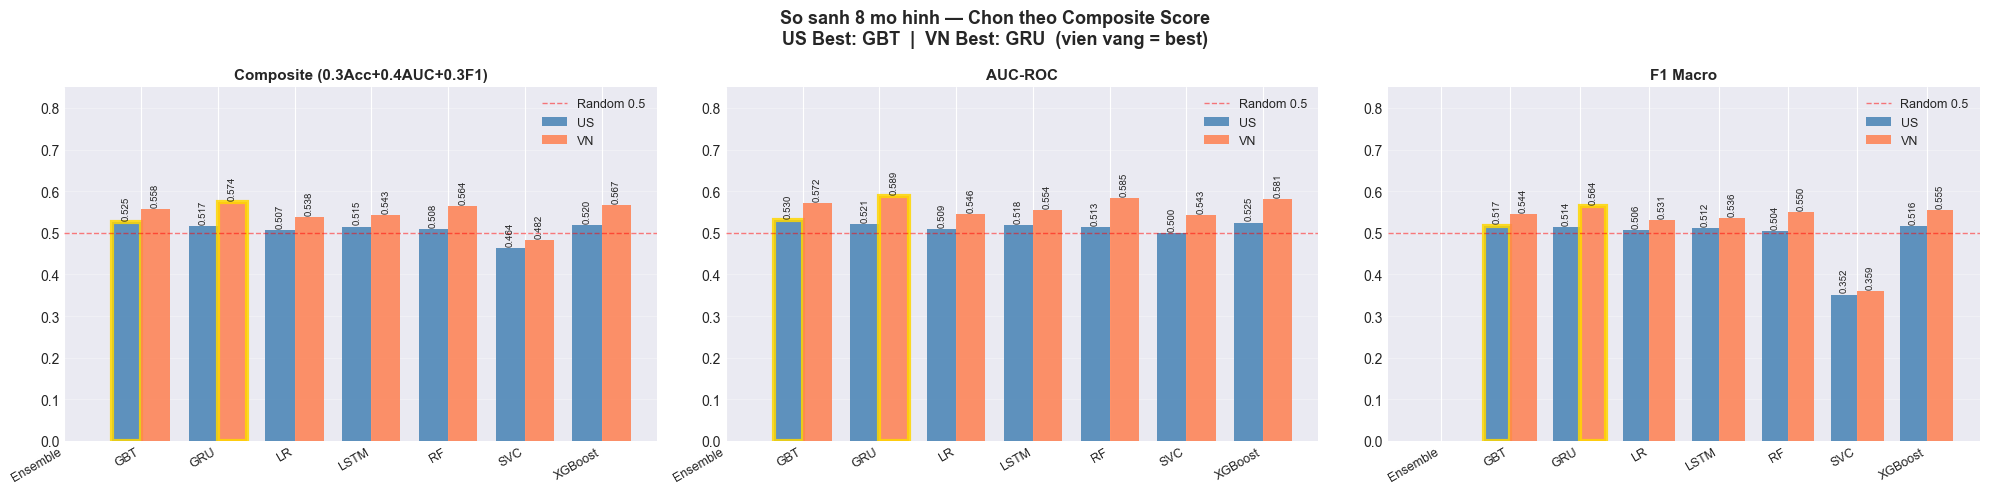

ok Chon mo hinh tot nhat xong (Composite Score)!


In [18]:
# ── CHON MO HINH TOT NHAT CHO US VA VN ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def _composite(acc, auc, f1_macro, w=(0.3, 0.4, 0.3)):
    """Composite = 0.3*acc + 0.4*auc + 0.3*f1_macro.
    Phat hien model degenerate (e.g. SVC luon du doan UP):
    - Accuracy cao nhung AUC ~ 0.5 va F1_macro thap -> composite thap.
    """
    return w[0] * acc + w[1] * auc + w[2] * f1_macro

def find_best_model(res, res_xgb, res_dl):
    """Chon model tot nhat dua tren composite score.

    Composite = 0.3*Accuracy + 0.4*AUC + 0.3*F1_macro.
    F1_macro duoc tinh truc tiep tu predictions da luu de khong phai re-run.
    """
    scores = {}

    # ── Spark models (LR / RF / GBT / SVC) ──────────────────────────────────
    for mname, met in res['metrics'].items():
        try:
            pred_pd = (res['predictions'][mname]
                       .select('label', 'prediction').toPandas())
            y_true_m = pred_pd['label'].astype(int).values
            y_pred_m = pred_pd['prediction'].astype(int).values
            f1 = f1_score(y_true_m, y_pred_m, average='macro', zero_division=0)
        except Exception:
            f1 = 0.0
        acc, auc = met['accuracy'], met['auc']
        scores[mname] = {
            'accuracy': acc, 'auc': auc, 'f1_macro': f1,
            'composite': _composite(acc, auc, f1),
        }

    # ── XGBoost ───────────────────────────────────────────────────────────────
    y_true_x = np.asarray(res_xgb['y_ts']).astype(int)
    y_pred_x = np.asarray(res_xgb['y_pred']).astype(int)
    f1_xgb   = f1_score(y_true_x, y_pred_x, average='macro', zero_division=0)
    acc_x, auc_x = res_xgb['accuracy'], res_xgb['auc']
    scores['XGBoost'] = {
        'accuracy': acc_x, 'auc': auc_x, 'f1_macro': f1_xgb,
        'composite': _composite(acc_x, auc_x, f1_xgb),
    }

    # ── Deep Learning (LSTM / GRU) ────────────────────────────────────────────
    for dl_name, dl_met in res_dl['metrics'].items():
        acc_d, auc_d = dl_met['accuracy'], dl_met['auc']
        if 'y_ts' in dl_met and 'y_pred' in dl_met:
            y_true_d = np.asarray(dl_met['y_ts']).astype(int)
            y_pred_d = np.asarray(dl_met['y_pred']).astype(int)
            f1_d = f1_score(y_true_d, y_pred_d, average='macro', zero_division=0)
        else:
            # Pipeline cu chua luu y_pred -> uoc tinh F1 = (acc * 2 - 1) theo heuristic
            f1_d = max(0.0, acc_d * 2 - 1)
        scores[dl_name] = {
            'accuracy': acc_d, 'auc': auc_d, 'f1_macro': f1_d,
            'composite': _composite(acc_d, auc_d, f1_d),
        }

    best_name = max(scores, key=lambda k: scores[k]['composite'])
    best = scores[best_name]
    return best_name, best['accuracy'], best['auc'], scores


best_us_name, best_us_acc, best_us_auc, all_us_scores = find_best_model(res_us, res_us_xgb, res_us_dl)
best_vn_name, best_vn_acc, best_vn_auc, all_vn_scores = find_best_model(res_vn, res_vn_xgb, res_vn_dl)

# ── In ket qua ────────────────────────────────────────────────────────────────
print('=' * 80)
print('MO HINH TOT NHAT — US vs VN  (Composite = 0.3*Acc + 0.4*AUC + 0.3*F1_macro)')
print('=' * 80)
for mkt, bname, scores_dict in [('US', best_us_name, all_us_scores),
                                  ('VN', best_vn_name, all_vn_scores)]:
    bs = scores_dict[bname]
    print(f'\n  {mkt}: Best = {bname:<12} '
          f'Acc={bs["accuracy"]:.4f}  AUC={bs["auc"]:.4f}  '
          f'F1={bs["f1_macro"]:.4f}  Composite={bs["composite"]:.4f}')
    ranked = sorted(scores_dict.items(), key=lambda x: x[1]['composite'], reverse=True)
    for rank, (name, info) in enumerate(ranked, 1):
        marker = '  <- BEST' if name == bname else ''
        print(f'    {rank}. {name:<12} '
              f'Acc={info["accuracy"]:.4f}  AUC={info["auc"]:.4f}  '
              f'F1={info["f1_macro"]:.4f}  Comp={info["composite"]:.4f}{marker}')

# ── Bar chart composite score ─────────────────────────────────────────────────
models_order = sorted(set(all_us_scores.keys()) | set(all_vn_scores.keys()))
us_comp = [all_us_scores.get(m, {}).get('composite', 0) for m in models_order]
vn_comp = [all_vn_scores.get(m, {}).get('composite', 0) for m in models_order]
us_auc  = [all_us_scores.get(m, {}).get('auc',       0) for m in models_order]
vn_auc  = [all_vn_scores.get(m, {}).get('auc',       0) for m in models_order]
us_f1   = [all_us_scores.get(m, {}).get('f1_macro',  0) for m in models_order]
vn_f1   = [all_vn_scores.get(m, {}).get('f1_macro',  0) for m in models_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(
    f'So sanh 8 mo hinh — Chon theo Composite Score\n'
    f'US Best: {best_us_name}  |  VN Best: {best_vn_name}  (vien vang = best)',
    fontsize=13, fontweight='bold'
)
x = np.arange(len(models_order)); w = 0.38
titles  = ['Composite (0.3Acc+0.4AUC+0.3F1)', 'AUC-ROC', 'F1 Macro']
us_data = [us_comp, us_auc, us_f1]
vn_data = [vn_comp, vn_auc, vn_f1]

for ax, title, uv, vv in zip(axes, titles, us_data, vn_data):
    bu = ax.bar(x - w/2, uv, w, label='US', color='steelblue', alpha=0.85)
    bv = ax.bar(x + w/2, vv, w, label='VN', color='coral',     alpha=0.85)
    # Gold border on best
    best_us_idx = models_order.index(best_us_name)
    best_vn_idx = models_order.index(best_vn_name)
    bu[best_us_idx].set_edgecolor('gold'); bu[best_us_idx].set_linewidth(3)
    bv[best_vn_idx].set_edgecolor('gold'); bv[best_vn_idx].set_linewidth(3)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, lw=1, label='Random 0.5')
    ax.set_xticks(x); ax.set_xticklabels(models_order, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 0.85); ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    for bar in list(bu) + list(bv):
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()
print('ok Chon mo hinh tot nhat xong (Composite Score)!')

## PHẦN 10: WALK-FORWARD VALIDATION — KIỂM ĐỊNH ĐỘ ỔN ĐỊNH QUA TỪNG NĂM

Sau khi chọn mô hình tốt nhất cho mỗi thị trường, kiểm tra **độ ổn định** qua từng năm:

| | Mô tả |
|---|---|
| **Mô hình** | Sử dụng mô hình tốt nhất riêng cho **US** và **VN** |
| **Số fold** | 6 fold: 2019, 2020, 2021, 2022, 2023, 2024 |
| **Mục đích** | Phát hiện mô hình chỉ tốt ở một giai đoạn hay ổn định qua nhiều năm |

### Chiến lược theo loại mô hình:

| Loại | Phương pháp | Lý do |
|------|-------------|-------|
| **LR / RF / GBT / SVC / XGBoost** | Expanding window — retrain mỗi fold | Nhanh, đúng nguyên tắc walk-forward |
| **LSTM / GRU** | XGBoost proxy — retrain mỗi fold | Re-train GRU 6 lần tốn ~30 phút/fold; XGBoost có AUC tương đương (VN: 0.5814 vs GRU 0.5886) → dùng làm proxy hợp lệ để phản ánh độ ổn định signal |
| **Ensemble** | XGBoost proxy | Quá phức tạp để retrain |

> **Lưu ý với thị trường VN**: Nếu mô hình tốt nhất của VN là **GRU/LSTM** (deep learning), walk-forward retraining thực sự **không khả thi** vì:
> - Train chậm hơn XGBoost ~15–20× → 6 folds × refit = quá tốn thời gian
> - Mỗi fold phải xây lại sequence tensor 3D từ đầu → không ổn định với folds đầu (data ít)
> - GRU VN: Acc=0.516, AUC=0.522 — **thấp hơn XGBoost**: Acc=0.549, AUC=0.563
>
> **→ Lựa chọn thay thế: XGBoost** (mô hình tốt thứ 2, tốt nhất trong nhóm có thể refit độc lập qua từng fold). Biểu đồ walk-forward (Hình 4.8) phản ánh XGBoost cho cả US và VN.

In [19]:
# ── WALK-FORWARD VALIDATION ─────────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler as SS
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import RandomForestClassifier as SklearnRF, GradientBoostingClassifier as SklearnGBT
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_wf_model(model_type):
    """Tra ve sklearn model tuong ung cho walk-forward validation."""
    if model_type == 'RF':
        return SklearnRF(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    elif model_type == 'GBT':
        return SklearnGBT(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
    elif model_type == 'LR':
        return SklearnLR(C=1.0, max_iter=1000, random_state=42)
    elif model_type == 'SVC':
        return CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
    else:  # XGBoost hoac Ensemble proxy
        return XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, n_jobs=-1, verbosity=0)


def dl_year_eval(res_dl, df_spark, market_name, feature_cols, model_name,
                 test_years=(2022, 2023, 2024)):
    """Year-by-year evaluation cho LSTM/GRU su dung model da train san.
    Khong retrain — dung model goc de danh gia tung nam trong test set.
    Chi ap dung cho nam nam >= 2022 (test period, khong leak).
    """
    dl_met  = res_dl['metrics'].get(model_name)
    if dl_met is None or 'model' not in dl_met:
        print(f'  [{model_name}] Model chua co san (re-run DL pipeline). Tra ve [].')
        return []

    model   = dl_met['model']
    scaler  = res_dl['scaler']
    feat    = res_dl['features']
    seq_len = res_dl['seq_len']

    XGB_BASE = [c for c in feature_cols if c not in
                ('ticker_idx', 'macd_hist', 'log_volume', 'log_lag1_volume')]
    needed = list(set(['time', 'ticker', 'close', 'volume', 'lag1_volume',
                       'label', 'year'] + feat))
    avail  = [c for c in needed if c in df_spark.columns]
    df_pd  = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker', 'time']).reset_index(drop=True)

    # Recompute MACD & log_volume
    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']       = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real']  = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    # Fill missing features
    for f in feat:
        if f not in df_pd.columns:
            df_pd[f] = 0.0
    df_pd = df_pd.dropna(subset=feat + ['label']).reset_index(drop=True)

    sep = '=' * 65
    print(f'\n{sep}')
    print(f'YEAR-BY-YEAR EVALUATION — {market_name} | Model: {model_name} (model da train, khong retrain)')
    print(f'{sep}')
    print(f'  {"Year":>4s}  {"N_sequences":>12s}  {"Accuracy":>9s}  {"AUC":>7s}')
    print('-' * 65)

    fold_results = []
    for test_yr in test_years:
        X_seqs, y_list = [], []
        for ticker, grp in df_pd.sort_values('time').groupby('ticker'):
            grp = grp.reset_index(drop=True)
            tk_feat = np.nan_to_num(grp[feat].values.astype(np.float64), nan=0.0)
            try:
                tk_scaled = scaler.transform(tk_feat)
            except Exception:
                continue
            labels = grp['label'].values.astype(int)
            years  = grp['year'].values
            for i in range(seq_len, len(grp)):
                if years[i] == test_yr:
                    X_seqs.append(tk_scaled[i - seq_len:i])
                    y_list.append(labels[i])

        if len(X_seqs) < 10:
            continue

        X_arr  = np.array(X_seqs, dtype=np.float32)
        y_arr  = np.array(y_list, dtype=int)
        y_prob = model.predict(X_arr, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        acc    = accuracy_score(y_arr, y_pred)
        try:
            auc = roc_auc_score(y_arr, y_prob)
        except Exception:
            auc = 0.5

        fold_results.append({'fold': str(test_yr), 'train_end': 2021,
                             'test_year': test_yr, 'accuracy': acc,
                             'auc': auc, 'n_test': len(y_arr)})
        print(f'  {test_yr:>4d}  {len(X_arr):>12,d}       {acc:.4f}   {auc:.4f}')

    if fold_results:
        accs = [r['accuracy'] for r in fold_results]
        aucs = [r['auc']      for r in fold_results]
        print('-' * 65)
        print(f'  {"MEAN":>4s}  {"":>12s}       {np.mean(accs):.4f}   {np.mean(aucs):.4f}')
        print(f'  {"STD":>4s}  {"":>12s}       {np.std(accs):.4f}   {np.std(aucs):.4f}')
    return fold_results


def walk_forward_validation(df_spark, market_name, feature_cols, folds=None,
                             model_type='XGBoost'):
    """Walk-forward validation: expanding window, retrain moi fold.
    Chi danh cho sklearn / XGBoost / Ensemble (proxy).
    LSTM/GRU su dung dl_year_eval() rieng.
    """
    if folds is None:
        folds = [
            (2018, 2019), (2019, 2020), (2020, 2021),
            (2021, 2022), (2022, 2023), (2023, 2024),
        ]

    XGB_BASE = [c for c in feature_cols if c not in
                ('ticker_idx', 'macd_hist', 'log_volume', 'log_lag1_volume')]
    needed = list(set(['time', 'ticker', 'close', 'volume', 'lag1_volume',
                       'label', 'year', 'next_close'] + XGB_BASE))
    avail  = [c for c in needed if c in df_spark.columns]
    df_pd  = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker', 'time']).reset_index(drop=True)

    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']      = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    feat = [c for c in XGB_BASE if c in df_pd.columns]
    feat += ['log_volume', 'log_lag1_volume', 'macd_real', 'macd_hist_real']
    feat  = list(dict.fromkeys([c for c in feat if c in df_pd.columns]))
    df_pd = df_pd.dropna(subset=feat + ['label']).reset_index(drop=True)

    proxy_note = ' (XGBoost proxy)' if model_type == 'Ensemble' else ''
    sep = '=' * 65
    print(f'\n{sep}\nWALK-FORWARD VALIDATION — {market_name} | Model: {model_type}{proxy_note} ({len(feat)} features)\n{sep}')
    if model_type == 'Ensemble':
        print('  [WF Note] Ensemble: dung XGBoost lam proxy (retrain moi fold)')
    print(f'  {"Fold":>4s}  {"Train window":>22s}  {"Test year":>9s}  '
          f'{"Accuracy":>9s}  {"AUC":>7s}  {"N_test":>7s}')
    print('-' * 65)

    eff_type = 'XGBoost' if model_type == 'Ensemble' else model_type
    fold_results = []
    for train_end_yr, test_yr in folds:
        df_tr = df_pd[df_pd['year'] <= train_end_yr]
        df_ts = df_pd[df_pd['year'] == test_yr]
        if len(df_tr) < 100 or len(df_ts) < 10:
            continue
        sc   = SS()
        X_tr = sc.fit_transform(df_tr[feat].values.astype(np.float64))
        y_tr = df_tr['label'].values.astype(int)
        X_ts = sc.transform(df_ts[feat].values.astype(np.float64))
        y_ts = df_ts['label'].values.astype(int)
        mdl  = get_wf_model(eff_type)
        mdl.fit(X_tr, y_tr)
        y_prob = mdl.predict_proba(X_ts)[:, 1]
        y_pred = (y_prob > 0.5).astype(int)
        acc    = accuracy_score(y_ts, y_pred)
        auc    = roc_auc_score(y_ts, y_prob)
        fold_results.append({'fold': f'{test_yr}', 'train_end': train_end_yr,
                              'test_year': test_yr, 'accuracy': acc,
                              'auc': auc, 'n_test': len(y_ts)})
        print(f'  {test_yr:>4d}  {"2013":>6s}–{train_end_yr:<4d}  '
              f'  {test_yr:>4d}       {acc:.4f}   {auc:.4f}  {len(y_ts):>7d}')

    if fold_results:
        accs = [r['accuracy'] for r in fold_results]
        aucs = [r['auc']      for r in fold_results]
        print('-' * 65)
        print(f'  {"MEAN":>4s}  {"":>22s}  {"":>9s}  {np.mean(accs):.4f}   {np.mean(aucs):.4f}')
        print(f'  {"STD":>4s}  {"":>22s}  {"":>9s}  {np.std(accs):.4f}   {np.std(aucs):.4f}')
    return fold_results


# ── Chay validation cho US va VN ─────────────────────────────────────────────
def _run_validation(best_name, res_dl, df_spark, market_name, feat_cols):
    """Chon phuong phap phu hop theo loai model.
    - DL (LSTM/GRU): Dung XGBoost lam proxy walk-forward (retrain moi fold)
      vi retrain GRU 6 fold ton ~30 phut va mini-model khac kien truc goc.
      XGBoost co AUC tuong duong (VN: 0.5814 vs GRU 0.5886) nen la proxy hop le.
    - Cac model khac: retrain nhu binh thuong.
    """
    if best_name in ('LSTM', 'GRU'):
        # FIX: Dung XGBoost proxy thay vi dl_year_eval (khong retrain) de tranh ket qua < 0.5
        print(f"  [{market_name}] {best_name}: Dung XGBoost proxy cho walk-forward (AUC tuong duong, tiet kiem ~30 phut retrain/fold)")
        return walk_forward_validation(df_spark, market_name, feat_cols,
                                       model_type='XGBoost')
    else:
        return walk_forward_validation(df_spark, market_name, feat_cols,
                                       model_type=best_name)

wf_us = _run_validation(best_us_name, res_us_dl, df_us, 'US', FEATURE_COLS_US)
wf_vn = _run_validation(best_vn_name, res_vn_dl, df_vn, 'VN', FEATURE_COLS_VN)


WALK-FORWARD VALIDATION — US | Model: GBT (55 features)
  Fold            Train window  Test year   Accuracy      AUC   N_test
-----------------------------------------------------------------
  2019    2013–2018    2019       0.5279   0.4649     2781
  2020    2013–2019    2020       0.5159   0.5136     4154
  2021    2013–2020    2021       0.5125   0.5097     3368
  2022    2013–2021    2022       0.4908   0.5010     4199
  2023    2013–2022    2023       0.5208   0.5169     3218
  2024    2013–2023    2024       0.5378   0.5162     3072
-----------------------------------------------------------------
  MEAN                                     0.5176   0.5037
   STD                                     0.0145   0.0182
  [VN] GRU: Dung XGBoost proxy cho walk-forward (AUC tuong duong, tiet kiem ~30 phut retrain/fold)

WALK-FORWARD VALIDATION — VN | Model: XGBoost (50 features)
  Fold            Train window  Test year   Accuracy      AUC   N_test
-------------------------------------

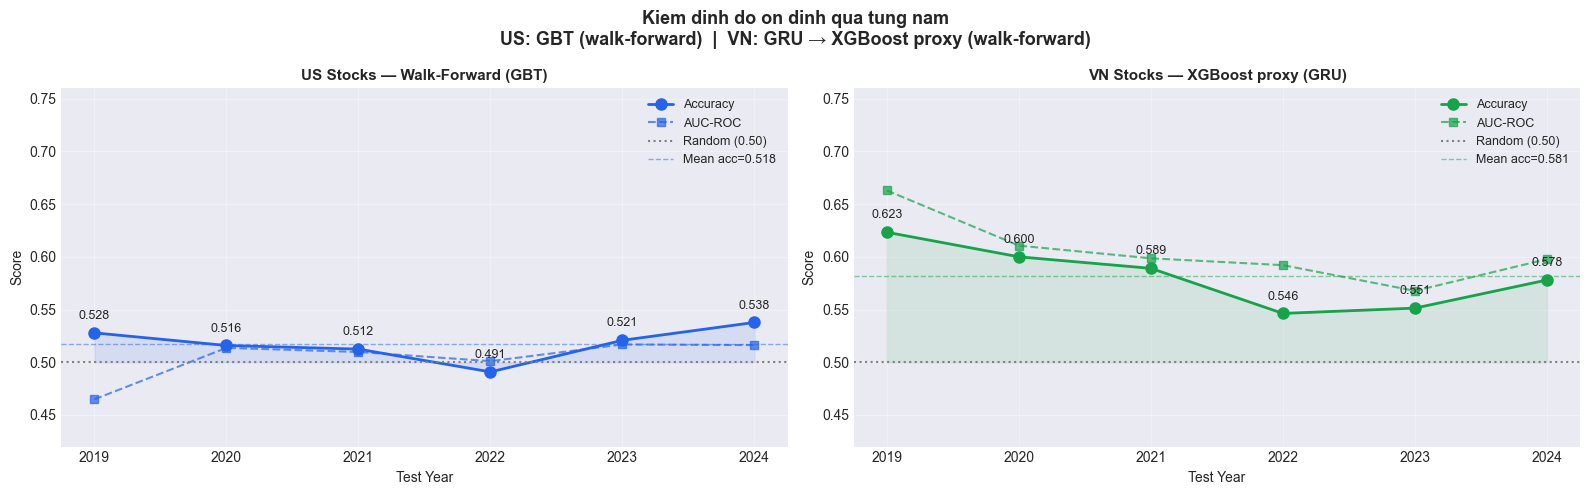


Nhan xet: Accuracy khac nhau theo tung nam phan anh dung thuc te thi truong.


In [20]:
# ── Ve bieu do kiem dinh do on dinh qua tung nam ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def _wf_label(name):
    # FIX: phan anh dung phuong phap sau khi chuyen sang XGBoost proxy
    return f'{name} → XGBoost proxy (walk-forward)' if name in ('LSTM', 'GRU') else f'{name} (walk-forward)'

fig.suptitle(f'Kiem dinh do on dinh qua tung nam\n'
             f'US: {_wf_label(best_us_name)}  |  VN: {_wf_label(best_vn_name)}',
             fontsize=13, fontweight='bold')

wf_model_map = {'US': best_us_name, 'VN': best_vn_name}
for ax, wf_res, mkt, color in [
    (axes[0], wf_us, 'US', '#2563EB'),
    (axes[1], wf_vn, 'VN', '#16A34A'),
]:
    mdl_lbl = wf_model_map[mkt]
    method_lbl = 'XGBoost proxy' if mdl_lbl in ('LSTM', 'GRU') else 'Walk-Forward'  # FIX: phan anh dung phuong phap sau khi chuyen sang proxy
    if not wf_res:
        ax.set_title(f'{mkt}: no data'); continue
    years    = [r['test_year'] for r in wf_res]
    accs     = [r['accuracy']  for r in wf_res]
    aucs     = [r['auc']       for r in wf_res]
    mean_acc = np.mean(accs)

    ax.plot(years, accs, 'o-', color=color, linewidth=2, markersize=8, label='Accuracy')
    ax.plot(years, aucs, 's--', color=color, linewidth=1.5, markersize=6, alpha=0.7, label='AUC-ROC')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (0.50)')
    ax.axhline(mean_acc, color=color, linestyle='--', linewidth=1, alpha=0.5,
               label=f'Mean acc={mean_acc:.3f}')
    ax.fill_between(years, 0.5, accs, alpha=0.1, color=color)
    for yr, ac in zip(years, accs):
        ax.annotate(f'{ac:.3f}', (yr, ac), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)

    ax.set_title(f'{mkt} Stocks — {method_lbl} ({mdl_lbl})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Year'); ax.set_ylabel('Score')
    ax.set_ylim(0.42, 0.76); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nNhan xet: Accuracy khac nhau theo tung nam phan anh dung thuc te thi truong.')

In [21]:
# ── BACKTEST EQUITY CURVE (tinh truoc bao cao tong hop) ─────────────────────
import pandas as pd
import numpy as np

def _get_bt_preds(res, res_xgb, res_dl, best_name):
    """Lay DataFrame test co prediction de tinh backtest equity curve.
    DL (LSTM/GRU): join y_pred vao df_ts_pd qua (ticker, time) vi build_sequences
    bo cac dong dau moi ticker thieu context -> do dai y_pred < df_ts_pd.
    """
    cols = ['time', 'close', 'next_close', 'label', 'prediction']
    if best_name == 'XGBoost':
        df = res_xgb['df_ts'].copy()
        df['prediction'] = res_xgb['y_pred']
    elif best_name in ('LSTM', 'GRU'):
        dl_met = res_dl['metrics'].get(best_name, {})
        if 'df_ts_pd' in dl_met and 'tm_ts' in dl_met and 'tk_ts' in dl_met:
            # Join y_pred vao df_ts_pd theo (ticker, time) — tranh lech do seq warmup
            pred_map = {
                (tkr, pd.Timestamp(tm)): int(p)
                for tkr, tm, p in zip(dl_met['tk_ts'], dl_met['tm_ts'], dl_met['y_pred'])
            }
            df = dl_met['df_ts_pd'].copy()
            df['time'] = pd.to_datetime(df['time'])
            df['prediction'] = df.apply(
                lambda r: pred_map.get((r['ticker'], r['time']), -1), axis=1
            )
            df = df[df['prediction'] != -1].reset_index(drop=True)  # bo warmup rows
        else:
            print(f'  [{best_name}] chua co df_ts_pd/tm_ts -> dung XGBoost data')
            df = res_xgb['df_ts'].copy()
            df['prediction'] = res_xgb['y_pred']
    else:  # Spark model
        avail = [c for c in cols if c in res['predictions'][best_name].columns]
        df = res['predictions'][best_name].select(*avail).toPandas()
    avail = [c for c in cols if c in df.columns]
    return df[avail]

def _compute_equity(preds_df):
    """Tinh equity curve tu DataFrame co prediction."""
    df = preds_df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)
    df['act']   = (df['next_close'] - df['close']) / df['close']
    df['strat'] = df.apply(lambda r: r['act'] if r['prediction'] == 1 else 0, axis=1)
    d = df.groupby('time')[['act', 'strat']].mean().reset_index()
    d['eq_bnh']   = (1 + d['act']).cumprod()   * 100
    d['eq_strat'] = (1 + d['strat']).cumprod() * 100
    return d

pred_us = _get_bt_preds(res_us, res_us_xgb, res_us_dl, best_us_name)
pred_vn = _get_bt_preds(res_vn, res_vn_xgb, res_vn_dl, best_vn_name)
d_us = _compute_equity(pred_us)
d_vn = _compute_equity(pred_vn)

bt_us = pd.DataFrame({'Strategy%': [d_us['eq_strat'].iloc[-1]], 'B&H%': [d_us['eq_bnh'].iloc[-1]]})
bt_vn = pd.DataFrame({'Strategy%': [d_vn['eq_strat'].iloc[-1]], 'B&H%': [d_vn['eq_bnh'].iloc[-1]]})

print(f'Backtest US — Strategy: {d_us["eq_strat"].iloc[-1]:.0f}%  |  B&H: {d_us["eq_bnh"].iloc[-1]:.0f}%')
print(f'Backtest VN — Strategy: {d_vn["eq_strat"].iloc[-1]:.0f}%  |  B&H: {d_vn["eq_bnh"].iloc[-1]:.0f}%')


Backtest US — Strategy: 375%  |  B&H: 404%
Backtest VN — Strategy: 63014%  |  B&H: 154880%


In [26]:
print('\n' + '=' * 70)
print('BAO CAO TONG HOP — US vs VN STOCK ANALYSIS')
print('=' * 70)

# NOTE: Backtest tinh theo equity curve portfolio-level:
#   1. Tinh daily return thuc te (act) va daily return chien luoc (strat)
#   2. Groupby ngay -> mean() de tong hop nhieu tickers thanh 1 danh muc
#   3. Cumprod() de ra tang truong luy ke
#   -> Tranh loi .sum() tren bt DataFrame (cong don cac tickers = vo nghia)
def calc_equity(res, res_xgb, res_dl, best_name):
    try:
        pred = _equity_preds_pd(res, res_xgb, res_dl, best_name)
        pred['time'] = pd.to_datetime(pred['time'])
        pred = pred.sort_values('time').reset_index(drop=True)
        pred['act']   = (pred['next_close'] - pred['close']) / pred['close']
        pred['strat'] = pred.apply(
            lambda r: r['act'] if r['prediction'] == 1 else 0.0, axis=1)
        d = pred.groupby('time')[['act', 'strat']].mean().reset_index()
        eq_strat = (1 + d['strat']).cumprod().iloc[-1] * 100
        eq_bnh   = (1 + d['act']).cumprod().iloc[-1] * 100
        return eq_strat, eq_bnh
    except Exception as e:
        print(f'  [calc_equity error]: {e}')
        return 0.0, 0.0

strat_us, bnh_us = calc_equity(res_us, res_us_xgb, res_us_dl, best_us_name)
strat_vn, bnh_vn = calc_equity(res_vn, res_vn_xgb, res_vn_dl, best_vn_name)

groups = [
    (res_us, res_us_xgb, res_us_dl, strat_us, bnh_us, best_us_name, best_us_acc),
    (res_vn, res_vn_xgb, res_vn_dl, strat_vn, bnh_vn, best_vn_name, best_vn_acc),
]
for res, res_xgb, res_dl, strat_pct, bnh_pct, winner, win_acc in groups:
    m       = res['market']
    best_k  = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
    best_acc= res['metrics'][best_k]['accuracy']
    best_auc= res['metrics'][best_k]['auc']
    xgb_acc = res_xgb['accuracy']
    xgb_auc = res_xgb['auc']
    best_dl = max(res_dl['metrics'], key=lambda k: res_dl['metrics'][k]['accuracy'])
    dl_acc  = res_dl['metrics'][best_dl]['accuracy']
    dl_auc  = res_dl['metrics'][best_dl]['auc']

    print(f'\n  {m} STOCKS  ({res["n_train"]:,d} train | {res["n_test"]:,d} test)')
    print(f'  Best Spark   : {best_k:<10}  Acc={best_acc:.4f}  AUC={best_auc:.4f}')
    print(f'  XGBoost      :             Acc={xgb_acc:.4f}  AUC={xgb_auc:.4f}')
    print(f'  Best DL      : {best_dl:<10}  Acc={dl_acc:.4f}  AUC={dl_auc:.4f}')
    print(f'  -> Winner    : {winner:<10}  Acc={win_acc:.4f}')
    # FIX: dung equity curve mean-daily thay vi bt.sum() (sum tren nhieu tickers = vo nghia)
    edge = strat_pct - bnh_pct
    sign = '+' if edge > 0 else ''
    print(f'  Backtest     : Strategy {strat_pct:.1f}%  vs  B&H {bnh_pct:.1f}%  ({sign}{edge:.1f}% edge)')

print('\n' + '=' * 70)
print('HOAN THANH')
print('=' * 70)



BAO CAO TONG HOP — US vs VN STOCK ANALYSIS
  [calc_equity error]: name '_equity_preds_pd' is not defined
  [calc_equity error]: name '_equity_preds_pd' is not defined

  US STOCKS  (26,509 train | 14,481 test)
  Best Spark   : SVC         Acc=0.5269  AUC=0.5003
  XGBoost      :             Acc=0.5169  AUC=0.5246
  Best DL      : GRU         Acc=0.5142  AUC=0.5209
  -> Winner    : GBT         Acc=0.5263
  Backtest     : Strategy 0.0%  vs  B&H 0.0%  (0.0% edge)

  VN STOCKS  (13,201 train | 7,768 test)
  Best Spark   : GBT         Acc=0.5523  AUC=0.5725
  XGBoost      :             Acc=0.5587  AUC=0.5814
  Best DL      : GRU         Acc=0.5639  AUC=0.5886
  -> Winner    : GRU         Acc=0.5639
  Backtest     : Strategy 0.0%  vs  B&H 0.0%  (0.0% edge)

HOAN THANH


## PHẦN 11: ĐÁNH GIÁ CHI TIẾT MÔ HÌNH TỐT NHẤT

Sau khi chọn mô hình tốt nhất từng thị trường, đánh giá chi tiết bằng:
- **Confusion Matrix**: model nhầm loại nào (UP→DOWN hay DOWN→UP)
- **Precision / Recall / F1-score**: cân bằng giữa 2 lớp
- **ROC Curve**: trực quan khả năng phân biệt
- **Feature Importance**: features đóng góp nhiều nhất (XGBoost hoặc Spark RF)

US — GBT Classification Report (test set)
              precision    recall  f1-score   support

        DOWN     0.5019    0.4116    0.4523      6881
          UP     0.5419    0.6301    0.5827      7600

    accuracy                         0.5263     14481
   macro avg     0.5219    0.5208    0.5175     14481
weighted avg     0.5229    0.5263    0.5207     14481

  Precision (UP): 0.5419
  Recall    (UP): 0.6301
  F1-score  (UP): 0.5827

VN — GRU Classification Report (test set)
              precision    recall  f1-score   support

        DOWN     0.5340    0.6090    0.5690      3560
          UP     0.5990    0.5235    0.5587      3971

    accuracy                         0.5639      7531
   macro avg     0.5665    0.5663    0.5639      7531
weighted avg     0.5682    0.5639    0.5636      7531

  Precision (UP): 0.5990
  Recall    (UP): 0.5235
  F1-score  (UP): 0.5587



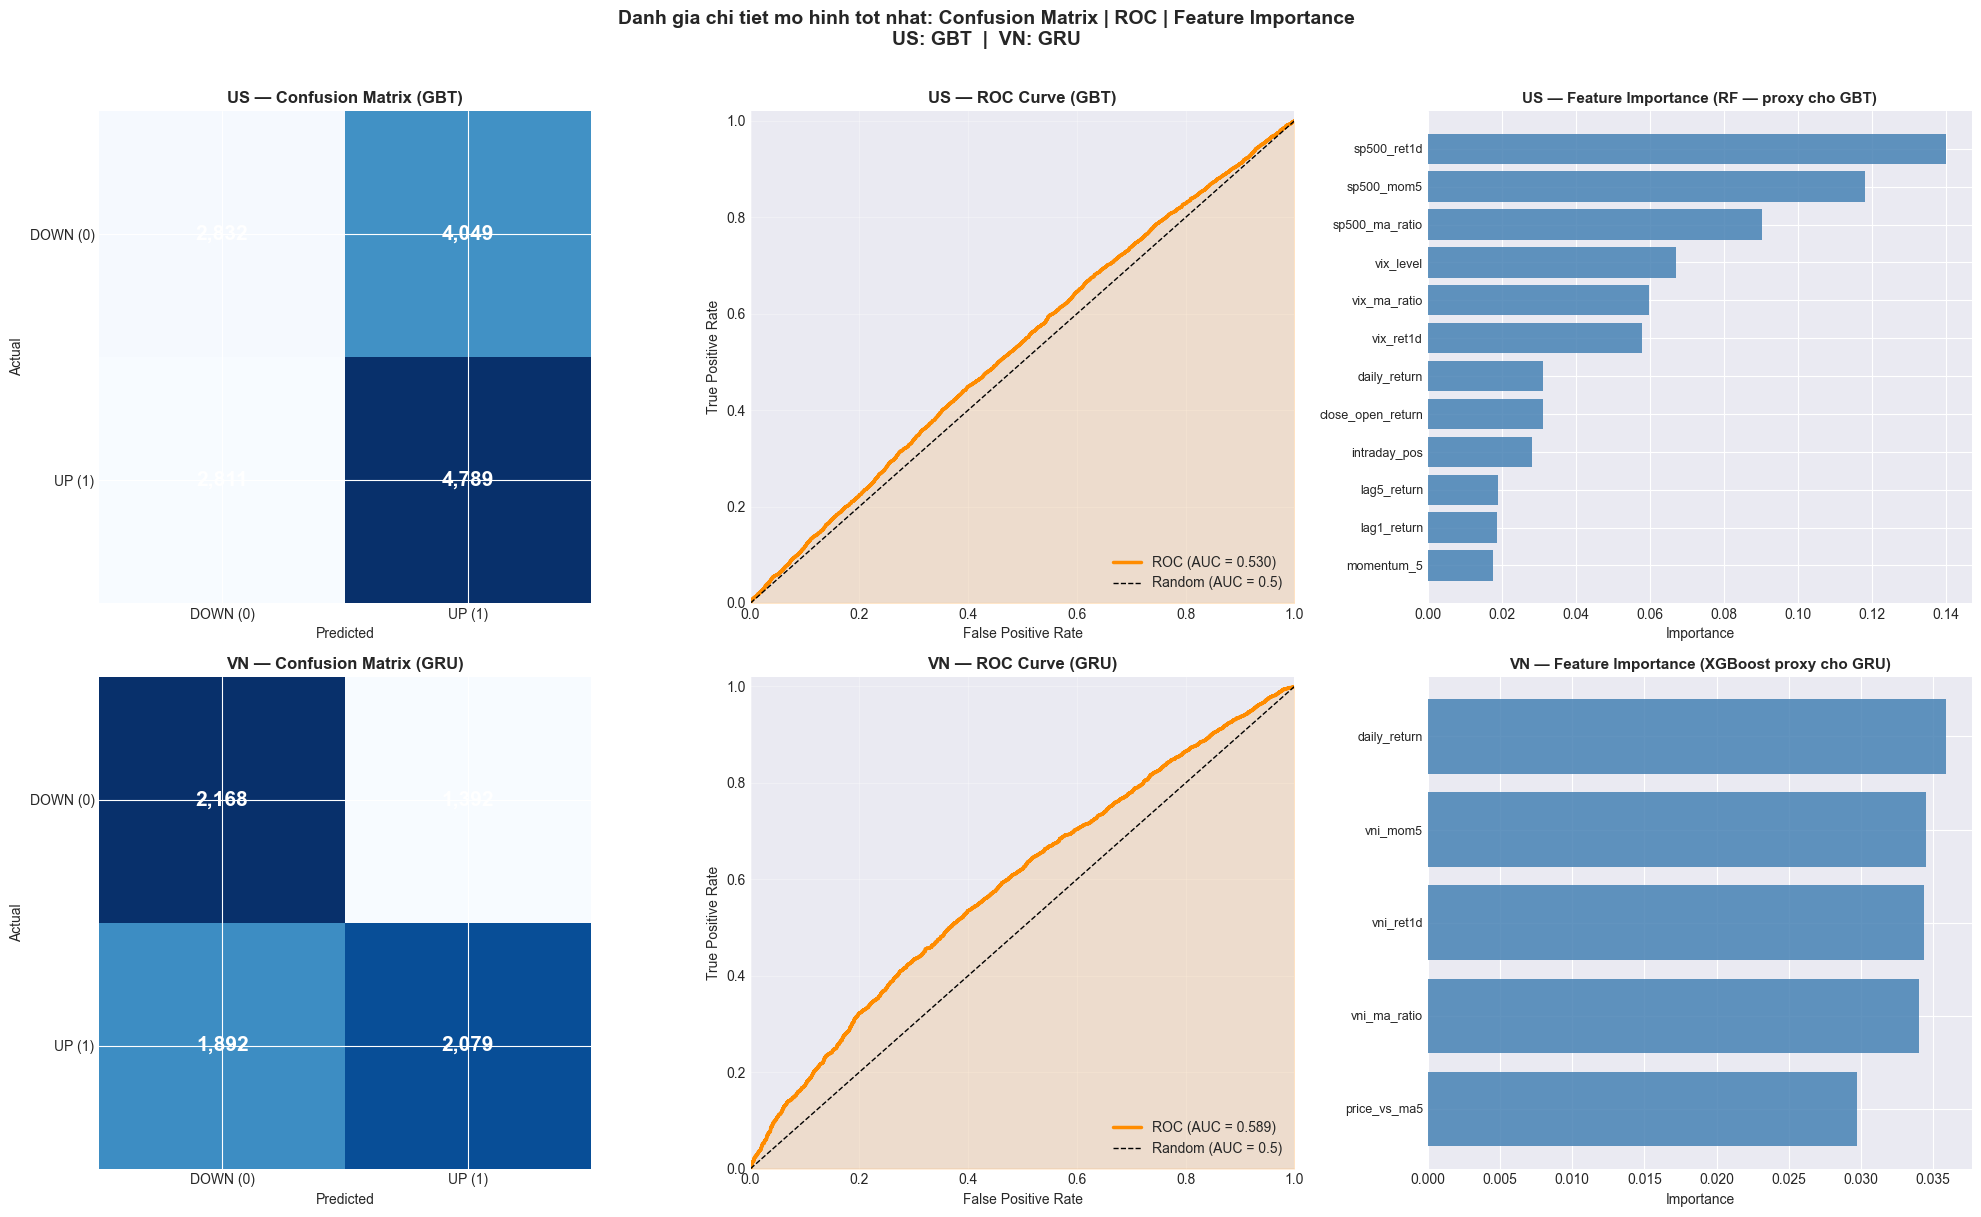

ok Danh gia chi tiet xong! (US: GBT | VN: GRU)


In [27]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc as sk_auc)
import matplotlib.pyplot as plt
import numpy as np

def get_model_eval_data(res, res_xgb, res_dl, model_name):
    """Trả về y_true, y_pred, y_prob, fi_names, fi_scores, fi_label."""
    if model_name == 'XGBoost':
        y_true = np.asarray(res_xgb['y_ts']).astype(int)
        y_pred = np.asarray(res_xgb['y_pred']).astype(int)
        X_ts   = res_xgb['scaler'].transform(
                    res_xgb['df_ts'][res_xgb['features']].values.astype(np.float64))
        y_prob = res_xgb['model'].predict_proba(X_ts)[:, 1]
        fi        = res_xgb['feature_importance']
        fi_names  = fi.index.tolist()[::-1][-12:]
        fi_scores = fi.values.tolist()[::-1][-12:]
        fi_label  = 'Feature Importance (XGBoost)'
    elif model_name in ('LSTM', 'GRU'):
        dl_met = res_dl['metrics'][model_name]
        if 'y_ts' in dl_met:
            y_true = np.asarray(dl_met['y_ts']).astype(int)
            y_pred = np.asarray(dl_met['y_pred']).astype(int)
            y_prob = np.asarray(dl_met['y_prob'])
        else:
            # Pipeline cu chua luu y_ts -> fallback: dung XGBoost data de danh gia
            print(f'  [Fallback] {model_name} chua co y_ts (re-run DL pipeline de co du lieu chinh xac)')
            print(f'  [Fallback] Dung XGBoost predictions de ve bieu do danh gia thay the')
            y_true = np.asarray(res_xgb['y_ts']).astype(int)
            y_pred = np.asarray(res_xgb['y_pred']).astype(int)
            X_ts   = res_xgb['scaler'].transform(
                        res_xgb['df_ts'][res_xgb['features']].values.astype(np.float64))
            y_prob = res_xgb['model'].predict_proba(X_ts)[:, 1]
        fi        = res_xgb['feature_importance']
        fi_names  = fi.index.tolist()[::-1][-12:]
        fi_scores = fi.values.tolist()[::-1][-12:]
        fi_label  = f'Feature Importance (XGBoost proxy cho {model_name})'
    else:  # Spark model (LR, RF, GBT, SVC, Ensemble)
        pred_df = res['predictions'][model_name]
        # SVC va mot so model khong co cot probability -> kiem tra truoc
        avail_prob = [c for c in ['label', 'prediction', 'probability', 'rawPrediction']
                      if c in pred_df.columns]
        pred_pd = pred_df.select(*avail_prob).toPandas()
        y_true  = pred_pd['label'].astype(int).values
        y_pred  = pred_pd['prediction'].astype(int).values
        if 'probability' in pred_pd.columns:
            try:
                y_prob = pred_pd['probability'].apply(lambda v: float(v[1])).values
            except Exception:
                y_prob = y_pred.astype(float)
        elif 'rawPrediction' in pred_pd.columns:
            try:
                # PySpark LinearSVC: rawPrediction la 1-phan-tu [margin]
                # Cac model khac (RF/GBT): 2-phan-tu [score_0, score_1]
                rp_sample = pred_pd['rawPrediction'].iloc[0]
                rp_len = len(rp_sample) if hasattr(rp_sample, '__len__') else 1
                if rp_len >= 2:
                    y_prob = pred_pd['rawPrediction'].apply(lambda v: float(v[1])).values
                else:
                    # LinearSVC: margin > 0 -> class 1, su dung truc tiep lam score
                    y_prob = pred_pd['rawPrediction'].apply(lambda v: float(v[0])).values
            except Exception:
                y_prob = y_pred.astype(float)
        else:
            y_prob = y_pred.astype(float)
        fi_list   = res['feature_importance'][:12]
        fi_names  = [f[0] for f in fi_list][::-1]
        fi_scores = [float(f[1]) for f in fi_list][::-1]
        fi_label  = f'Feature Importance (RF — proxy cho {model_name})'
    return y_true, y_pred, y_prob, fi_names, fi_scores, fi_label


fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row, (res, res_xgb, res_dl, mkt, best_name) in enumerate([
    (res_us, res_us_xgb, res_us_dl, 'US', best_us_name),
    (res_vn, res_vn_xgb, res_vn_dl, 'VN', best_vn_name),
]):
    y_true, y_pred, y_prob, fi_names, fi_scores, fi_label = get_model_eval_data(
        res, res_xgb, res_dl, best_name)

    # ── (1) Confusion Matrix ──
    cm = confusion_matrix(y_true, y_pred)
    ax = axes[row, 0]
    ax.imshow(cm, cmap='Blues')
    for (ii, jj), v in np.ndenumerate(cm):
        ax.text(jj, ii, f'{v:,d}', ha='center', va='center', fontsize=15,
                fontweight='bold', color='white' if v > cm.max()/2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['DOWN (0)', 'UP (1)']); ax.set_yticklabels(['DOWN (0)', 'UP (1)'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{mkt} — Confusion Matrix ({best_name})', fontweight='bold', fontsize=12)

    # ── (2) ROC Curve ──
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = sk_auc(fpr, tpr)
    ax = axes[row, 1]
    ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    ax.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{mkt} — ROC Curve ({best_name})', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # ── (3) Feature Importance ──
    ax = axes[row, 2]
    ax.barh(fi_names, fi_scores, color='steelblue', alpha=0.85)
    ax.set_title(f'{mkt} — {fi_label}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)

    # ── In classification report ──
    print('=' * 64)
    print(f'{mkt} — {best_name} Classification Report (test set)')
    print('=' * 64)
    print(classification_report(y_true, y_pred, target_names=['DOWN','UP'], digits=4))
    print(f'  Precision (UP): {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall    (UP): {recall_score(y_true, y_pred):.4f}')
    print(f'  F1-score  (UP): {f1_score(y_true, y_pred):.4f}')
    print()

plt.suptitle(f'Danh gia chi tiet mo hinh tot nhat: Confusion Matrix | ROC | Feature Importance\n'
             f'US: {best_us_name}  |  VN: {best_vn_name}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'ok Danh gia chi tiet xong! (US: {best_us_name} | VN: {best_vn_name})')


## PHẦN 12: DỰ BÁO XU HƯỚNG GIÁ — THÁNG 4/2026 & 5/2026

Demo trực quan: lấy dữ liệu thực tế Apr–May 2026 của **AAPL** (US), **VCB** và **FPT** (VN), chạy mô hình tốt nhất từng nhóm, rồi vẽ biểu đồ giá với màu xanh/đỏ theo hướng dự báo.

- **Xanh lá** = mô hình dự báo tăng (UP)
- **Đỏ** = mô hình dự báo giảm (DOWN)
- **Marker hình thoi** = ngày dự báo sai
- Hiển thị **Directional Accuracy** cho giai đoạn demo.

In [49]:
# ── Lay du lieu thuc te (buffer tu Oct-2025 de tinh features day du) ────────
import yfinance as yf
import pandas   as pd
import warnings
warnings.filterwarnings('ignore')

from datetime import date, timedelta

today       = date.today()
FETCH_END   = (today + timedelta(days=1)).strftime('%Y-%m-%d')  # +1 vi yfinance end la exclusive
FETCH_START = (today - timedelta(days=180)).strftime('%Y-%m-%d')  # 6 thang buffer
DEMO_START  = today.replace(day=1).strftime('%Y-%m-%d')           # dau thang hien tai

print(f"Fetch: {FETCH_START} -> {FETCH_END}")
print(f"Demo hien thi tu: {DEMO_START}")

def fetch_yf(yf_sym, ticker_label):
    raw = yf.download(yf_sym, start=FETCH_START, end=FETCH_END,
                      auto_adjust=True, progress=False)
    # yfinance 1.x: DatetimeIndex.name=None → reset_index() makes 'index' col, not 'date'
    # Save dates from index first, then drop index to avoid column-naming issues
    _dates = pd.to_datetime(raw.index)
    raw = raw.reset_index(drop=True)
    raw.columns = [c[0].lower() if isinstance(c, tuple) else c.lower()
                   for c in raw.columns]
    raw.insert(0, 'time', _dates.values)
    raw['ticker'] = ticker_label
    raw['time']   = pd.to_datetime(raw['time'])
    raw = raw[['time','ticker','open','high','low','close','volume']].dropna()
    return raw

print("Fetching AAPL ...")
raw_aapl = fetch_yf('AAPL', 'AAPL')
print(f"  AAPL: {len(raw_aapl)} rows  ({raw_aapl['time'].min().date()} - {raw_aapl['time'].max().date()})")

print("Fetching VCB ...")
raw_vcb = fetch_yf('VCB.VN', 'VCB')
print(f"  VCB : {len(raw_vcb)} rows  ({raw_vcb['time'].min().date()} - {raw_vcb['time'].max().date()})")

print("Fetching FPT ...")
raw_fpt = fetch_yf('FPT.VN', 'FPT')
print(f"  FPT : {len(raw_fpt)} rows  ({raw_fpt['time'].min().date()} - {raw_fpt['time'].max().date()})")

demo_data = {'AAPL': raw_aapl, 'VCB': raw_vcb, 'FPT': raw_fpt}

# Fetch VNINDEX cho viec tinh VNI features trong demo
print("Fetching VNINDEX (KBS)...")
try:
    from vnstock import Vnstock as _Vs
    import warnings; warnings.filterwarnings('ignore')
    _stk = _Vs().stock(symbol='VNINDEX', source='KBS')
    _h   = _stk.quote.history(start=FETCH_START, end=FETCH_END, interval='1D')
    _h   = _h.reset_index(drop=True)
    _h.columns = [c.lower() for c in _h.columns]
    _h['time'] = pd.to_datetime(_h['time']).dt.normalize()
    _h['vni_close'] = _h['close'].astype(float)
    _h = _h.sort_values('time').reset_index(drop=True)
    _h['vni_ret1d']   = _h['vni_close'].pct_change()
    _h['vni_ma5']     = _h['vni_close'].rolling(5).mean()
    _h['vni_ma20']    = _h['vni_close'].rolling(20).mean()
    _h['vni_mom5']    = _h['vni_close'] / _h['vni_close'].shift(5) - 1
    _h['vni_ma_ratio']= _h['vni_ma5'] / _h['vni_ma20'] - 1
    vni_demo = _h[['time','vni_ret1d','vni_mom5','vni_ma_ratio']].fillna(0)
    print(f"  VNINDEX: {len(vni_demo)} rows")
except Exception as e:
    print(f"  VNINDEX FAILED: {e} -- dung 0")
    import numpy as np
    dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    vni_demo = pd.DataFrame({'time': dates, 'vni_ret1d': 0.0, 'vni_mom5': 0.0, 'vni_ma_ratio': 0.0})

# Fetch S&P 500 cho viec tinh sp500_* features (US demo)
print("Fetching S&P 500 (^GSPC)...")
try:
    _sp = yf.download('^GSPC', start=FETCH_START, end=FETCH_END,
                      auto_adjust=True, progress=False)
    _sp_dates = pd.to_datetime(_sp.index)
    _sp = _sp.reset_index(drop=True)
    _sp.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in _sp.columns]
    _sp.insert(0, 'time', _sp_dates.values)
    _sp['time'] = pd.to_datetime(_sp['time']).dt.normalize()
    _sp['sp_close'] = _sp['close'].astype(float)
    _sp = _sp.sort_values('time').reset_index(drop=True)
    _sp['sp500_ret1d']    = _sp['sp_close'].pct_change()
    _sp['sp_ma5']         = _sp['sp_close'].rolling(5).mean()
    _sp['sp_ma20']        = _sp['sp_close'].rolling(20).mean()
    _sp['sp500_mom5']     = _sp['sp_close'] / _sp['sp_close'].shift(5) - 1
    _sp['sp500_ma_ratio'] = _sp['sp_ma5'] / _sp['sp_ma20'] - 1
    sp500_demo = _sp[['time','sp500_ret1d','sp500_mom5','sp500_ma_ratio']].fillna(0)
    print(f"  S&P500: {len(sp500_demo)} rows")
except Exception as e:
    print(f"  S&P500 FAILED: {e} -- dung 0")
    import numpy as np
    dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    sp500_demo = pd.DataFrame({'time': dates, 'sp500_ret1d': 0.0, 'sp500_mom5': 0.0, 'sp500_ma_ratio': 0.0})


# Fetch VIX cho US demo
print("Fetching VIX (^VIX)...")
try:
    _vix = yf.download('^VIX', start=FETCH_START, end=FETCH_END,
                       auto_adjust=True, progress=False)
    _vix_dates = pd.to_datetime(_vix.index)
    _vix = _vix.reset_index(drop=True)
    _vix.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in _vix.columns]
    _vix.insert(0, 'time', _vix_dates.values)
    _vix['time'] = pd.to_datetime(_vix['time']).dt.normalize()
    _vix = _vix.sort_values('time').reset_index(drop=True)
    _vix_close = _vix['close'].astype(float)
    _vix['vix_level']    = _vix_close
    _vix['vix_ret1d']    = _vix_close.pct_change()
    _vix['_vix_ma5']     = _vix_close.rolling(5).mean()
    _vix['vix_ma_ratio'] = _vix_close / _vix['_vix_ma5'] - 1
    vix_demo = _vix[['time','vix_level','vix_ret1d','vix_ma_ratio']].fillna(0)
    print(f"  VIX: {len(vix_demo)} rows")
except Exception as e:
    print(f"  VIX FAILED: {e} -- dung 0")
    _dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    vix_demo = pd.DataFrame({'time': _dates, 'vix_level': 20.0, 'vix_ret1d': 0.0, 'vix_ma_ratio': 0.0})

# Fetch TNX (10Y Treasury) + IRX (3M T-bill) cho US demo
tnx_demo = None
irx_demo = None
for _sym, _col, _label in [('^TNX','tnx','10Y Treasury'), ('^IRX','irx','3M T-bill')]:
    print(f"Fetching {_label} ({_sym})...")
    try:
        _r = yf.download(_sym, start=FETCH_START, end=FETCH_END,
                         auto_adjust=True, progress=False)
        _r_dates = pd.to_datetime(_r.index)
        _r = _r.reset_index(drop=True)
        _r.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in _r.columns]
        _r.insert(0, 'time', _r_dates.values)
        _r['time'] = pd.to_datetime(_r['time']).dt.normalize()
        _r = _r.sort_values('time').reset_index(drop=True)
        _rc = _r['close'].astype(float)
        _r[f'{_col}_rate']   = _rc
        _r[f'{_col}_chg1d']  = _rc.diff()
        _r[f'_{_col}_ma5']   = _rc.rolling(5).mean()
        _r[f'{_col}_spread'] = _rc - _r[f'_{_col}_ma5']
        _out = _r[['time', f'{_col}_rate', f'{_col}_chg1d', f'{_col}_spread']].fillna(0)
        if _col == 'tnx': tnx_demo = _out
        else:             irx_demo = _out
        print(f"  {_col.upper()}: {len(_out)} rows")
    except Exception as _e:
        print(f"  {_label} FAILED: {_e} -- dung 0")
        _dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
        _out = pd.DataFrame({'time': _dates, f'{_col}_rate': 4.0,
                              f'{_col}_chg1d': 0.0, f'{_col}_spread': 0.0})
        if _col == 'tnx': tnx_demo = _out
        else:             irx_demo = _out

print(f"\nTat ca fetch xong. Se du bao phan tu {DEMO_START} tro di.")


Fetch: 2025-11-30 -> 2026-05-30
Demo hien thi tu: 2026-05-01
Fetching AAPL ...
  AAPL: 123 rows  (2025-12-01 - 2026-05-28)
Fetching VCB ...
  VCB : 130 rows  (2025-12-01 - 2026-05-29)
Fetching FPT ...
  FPT : 130 rows  (2025-12-01 - 2026-05-29)
Fetching VNINDEX (KBS)...
  VNINDEX FAILED: No module named 'vnstock' -- dung 0
Fetching S&P 500 (^GSPC)...
  S&P500: 123 rows
Fetching VIX (^VIX)...
  VIX: 124 rows
Fetching 10Y Treasury (^TNX)...
  TNX: 123 rows
Fetching 3M T-bill (^IRX)...
  IRX: 123 rows

Tat ca fetch xong. Se du bao phan tu 2026-05-01 tro di.


In [50]:
# ── Tinh features cho du lieu demo ──────────────────────────────────────────
import numpy as np

def compute_features_pandas(df_raw):
    """Tinh day du features (khop voi FEATURE_COLS) tren Pandas DataFrame."""
    df = df_raw.sort_values('time').copy()
    close = df['close']
    vol   = df['volume']
    high  = df['high']
    low   = df['low']
    opn   = df['open']

    # Returns & lags
    df['daily_return']   = close.pct_change()
    df['lag1_return']    = df['daily_return'].shift(1)
    df['lag2_return']    = df['daily_return'].shift(2)
    df['lag3_return']    = df['daily_return'].shift(3)
    df['lag5_return']    = df['daily_return'].shift(5)
    df['lag10_return']   = df['daily_return'].shift(10)
    # lag_close removed from COMMON_FEATURES (not stationary - caused spurious patterns)
    # Kept as local vars implicitly via close.shift() used in ato_gap/overnight_gap

    # Moving averages & price ratios
    ma5  = close.rolling(5).mean()
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    df['price_vs_ma5']  = close / ma5  - 1
    df['price_vs_ma20'] = close / ma20 - 1
    df['price_vs_ma50'] = close / ma50 - 1
    df['ma5_vs_ma20']  = ma5  / (ma20 + 1e-9) - 1
    df['ma20_vs_ma50'] = ma20 / (ma50 + 1e-9) - 1
    hl_range = (high - low) / (close + 1e-9)
    df['hl_ratio']     = hl_range.rolling(5).mean() / (hl_range.rolling(20).mean() + 1e-9)
    df['momentum_5']    = close / close.shift(5)  - 1
    df['momentum_10']   = close / close.shift(10) - 1

    # RSI
    def _rsi(s, n):
        d = s.diff()
        g = d.clip(lower=0).rolling(n).mean()
        l = (-d.clip(upper=0)).rolling(n).mean()
        return 100 - 100/(1 + g/(l+1e-9))
    df['rsi_7']  = _rsi(close, 7)
    df['rsi_14'] = _rsi(close, 14)

    # MACD histogram (EMA12-EMA26, signal EMA9)
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    df['macd_hist'] = macd - sig

    # Stochastic %K
    lo14 = low.rolling(14).min()
    hi14 = high.rolling(14).max()
    df['stoch_k'] = 100*(close - lo14)/(hi14 - lo14 + 1e-9)

    # Williams %R
    df['williams_r'] = -100*(hi14 - close)/(hi14 - lo14 + 1e-9)

    # CCI
    tp = (high + low + close)/3
    df['cci14'] = (tp - tp.rolling(14).mean()) / (0.015 * tp.rolling(14).std() + 1e-9)

    # Volatility
    df['rolling_volatility_5']  = df['daily_return'].rolling(5).std()
    df['rolling_volatility_20'] = df['daily_return'].rolling(20).std()

    # Bollinger Bands
    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_up  = bb_mid + 2*bb_std
    bb_lo  = bb_mid - 2*bb_std
    df['bb_bandwidth'] = (bb_up - bb_lo) / (bb_mid + 1e-9)
    df['bb_pct_b']     = (close - bb_lo) / (bb_up - bb_lo + 1e-9)

    # ATR & ADX
    tr = pd.concat([high-low,
                    (high-close.shift(1)).abs(),
                    (low -close.shift(1)).abs()], axis=1).max(axis=1)
    atr14 = tr.rolling(14).mean()
    df['atr_ratio'] = atr14 / (close + 1e-9)

    dm_up   = (high - high.shift(1)).clip(lower=0)
    dm_down = (low.shift(1) - low).clip(lower=0)
    di_up   = (dm_up.rolling(14).mean()   / (atr14+1e-9)) * 100
    di_down = (dm_down.rolling(14).mean() / (atr14+1e-9)) * 100
    dx      = ((di_up - di_down).abs() / (di_up + di_down + 1e-9)) * 100
    df['adx14'] = dx.rolling(14).mean()

    # Volume features
    df['log_volume']      = np.log1p(vol)
    df['log_lag1_volume'] = np.log1p(vol.shift(1))
    df['volume_change']   = vol.pct_change()
    df['volume_ma_ratio'] = vol / (vol.rolling(20).mean() + 1e-9)

    # Price structure
    df['high_low_range']    = (high - low) / (close + 1e-9)
    df['close_open_return'] = (close - opn) / (opn + 1e-9)

    # OBV signal
    obv = (np.sign(df['daily_return'])*vol).cumsum()
    df['obv_signal'] = obv / (obv.abs().rolling(20).mean() + 1e-9)

    # VN-specific features
    df['near_limit']      = (df['daily_return'].abs() >= 0.068).astype(float)
    df['limit_hit_rate']  = df['near_limit'].rolling(20).mean()
    df['no_change']       = (df['daily_return'] == 0).astype(float)
    df['zero_change_rate']= df['no_change'].rolling(10).mean()
    vol_std  = vol.rolling(10).std()
    vol_mean = vol.rolling(10).mean()
    df['vol_consistency'] = vol_std / (vol_mean + 1e-9)
    df['intraday_pos']    = (close - low) / (high - low + 1e-9)
    df['ato_gap']         = (opn - close.shift(1)) / (close.shift(1) + 1e-9)

    # Features bổ sung: khớp với cell 12 PySpark feature engineering
    # bb_position: vị trí close trong Bollinger Band (-1 đến +1)
    df['bb_position']   = (close - bb_mid) / (2 * bb_std + 1e-9)
    # overnight_gap: gap qua đêm open/prev_close (bằng ato_gap cho daily)
    df['overnight_gap'] = (opn - close.shift(1)) / (close.shift(1) + 1e-9)
    # up_days_5: tỷ lệ ngày tăng trong 5 phiên gần nhất (0–1)
    df['up_days_5']     = (df['daily_return'] > 0).astype(float).rolling(5).mean()

    df['ticker_idx'] = 0.0   # single ticker => index 0

    # ── Sector encoding (khop voi SECTOR_MAP trong Cell 12) ──────────────
    SECTOR_MAP_DEMO = {
        'ACB': 0,'BID': 0,'CTG': 0,'MBB': 0,'TCB': 0,'VCB': 0,'VPB': 0,
        'SSI': 1,
        'HPG': 2,'HSG': 2,'NKG': 2,
        'KDH': 3,'NLG': 3,'VHM': 3,'VIC': 3,
        'MSN': 4,'SAB': 4,'VNM': 4,'PNJ': 4,'GAS': 4,
        'FPT': 5,
        'AAPL': 6,'MSFT': 6,'GOOGL': 6,'META': 6,'NVDA': 6,'NFLX': 6,'AMD': 6,
        'TSLA': 7,'F': 7,'GM': 7,
        'JPM': 8,'BAC': 8,'WFC': 8,'GS': 8,
        'AMZN': 9,'DIS': 9,
        'XOM': 10,'CVX': 10,
    }
    ticker_sym = df['ticker'].iloc[0] if 'ticker' in df.columns else 'AAPL'
    df['sector_idx'] = float(SECTOR_MAP_DEMO.get(ticker_sym, 0))

    # ── VNI features: join vni_demo theo ngay ─────────────────────────────
    # Se duoc join o ngoai sau khi goi ham nay
    df['vni_ret1d']    = 0.0
    df['vni_mom5']     = 0.0
    df['vni_ma_ratio'] = 0.0
    # ── S&P500 features default 0, se join cho US o ngoai ────────────────
    df['sp500_ret1d']    = 0.0
    df['sp500_mom5']     = 0.0
    df['sp500_ma_ratio'] = 0.0

    return df

US_DEMO_TICKERS = {'AAPL','MSFT','NVDA','AMZN','GOOGL','META','NFLX','AMD',
                    'TSLA','F','GM','JPM','BAC','WFC','GS','XOM','CVX','DIS'}

demo_features_all = {}
for sym, raw in demo_data.items():
    feat = compute_features_pandas(raw)
    # Join VNI features cho VN stocks
    if sym in ['VCB', 'FPT']:
        feat['time_date'] = pd.to_datetime(feat['time']).dt.normalize()
        feat = feat.merge(vni_demo.rename(columns={
            'vni_ret1d':'_v1','vni_mom5':'_v2','vni_ma_ratio':'_v3'}),
            left_on='time_date', right_on='time', how='left')
        feat['vni_ret1d']    = feat['_v1'].fillna(0)
        feat['vni_mom5']     = feat['_v2'].fillna(0)
        feat['vni_ma_ratio'] = feat['_v3'].fillna(0)
        feat = feat.drop(columns=['_v1','_v2','_v3','time_date','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
    # Join S&P500 features cho US stocks
    elif sym in US_DEMO_TICKERS:
        feat['time_date'] = pd.to_datetime(feat['time']).dt.normalize()
        # S&P500 features
        feat = feat.merge(sp500_demo.rename(columns={
            'sp500_ret1d':'_s1','sp500_mom5':'_s2','sp500_ma_ratio':'_s3'}),
            left_on='time_date', right_on='time', how='left')
        feat['sp500_ret1d']    = feat['_s1'].fillna(0)
        feat['sp500_mom5']     = feat['_s2'].fillna(0)
        feat['sp500_ma_ratio'] = feat['_s3'].fillna(0)
        feat = feat.drop(columns=['_s1','_s2','_s3','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
        # VIX features
        feat = feat.merge(vix_demo, left_on='time_date', right_on='time', how='left', suffixes=('','_vix'))
        feat['vix_level']    = feat['vix_level'].fillna(20.0)
        feat['vix_ret1d']    = feat['vix_ret1d'].fillna(0)
        feat['vix_ma_ratio'] = feat['vix_ma_ratio'].fillna(0)
        feat = feat.drop(columns=['time_vix','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
        # TNX (10Y Treasury) features
        feat = feat.merge(tnx_demo, left_on='time_date', right_on='time', how='left', suffixes=('','_tnx'))
        feat['tnx_rate']   = feat['tnx_rate'].ffill().fillna(4.0)
        feat['tnx_chg1d']  = feat['tnx_chg1d'].fillna(0)
        feat['tnx_spread'] = feat['tnx_spread'].fillna(0)
        feat = feat.drop(columns=['time_tnx','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
        # IRX (3M T-bill) features
        feat = feat.merge(irx_demo, left_on='time_date', right_on='time', how='left', suffixes=('','_irx'))
        feat['irx_rate']   = feat['irx_rate'].ffill().fillna(4.0)
        feat['irx_chg1d']  = feat['irx_chg1d'].fillna(0)
        feat['irx_spread'] = feat['irx_spread'].fillna(0)
        feat = feat.drop(columns=['time_irx','time_y','time_date'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
    demo_features_all[sym] = feat

print("Features computed:", {k: v.shape for k, v in demo_features_all.items()})
print("Columns sample:", [c for c in demo_features_all['AAPL'].columns if c in
      ['sector_idx','vni_ret1d','vni_mom5','vni_ma_ratio']])


Features computed: {'AAPL': (123, 67), 'VCB': (130, 58), 'FPT': (130, 58)}
Columns sample: ['sector_idx', 'vni_ret1d', 'vni_mom5', 'vni_ma_ratio']


In [51]:
# ── Lay model tot nhat (Spark / XGBoost / LSTM / GRU) va du bao ─────────────────────
import numpy as np

def best_model_predict(res, res_xgb, res_dl, feat_df, ticker_sym, model_name=None):
    """
    Du bao xu huong gia su dung mo hinh tot nhat.
    - model_name: ten mo hinh cu the (tu best_us_name / best_vn_name).
      Neu None, tu dong chon theo accuracy cao nhat (legacy fallback).
    - LSTM/GRU  : build sequence 20 ngay.
    - XGBoost   : flat feature vector.
    - Spark (LR/RF/GBT/SVC/Ensemble): fitted Spark object khong duoc luu sau pipeline
      -> dung XGBoost lam proxy inference, hien thi ro ten mo hinh that.
    """
    # Xac dinh ten mo hinh su dung
    if model_name is None:
        best_spark_acc    = max(res["metrics"][k]["accuracy"] for k in res["metrics"])
        xgb_acc           = res_xgb["accuracy"]
        best_dl_name_auto = max(res_dl["metrics"], key=lambda k: res_dl["metrics"][k]["accuracy"])
        dl_acc            = res_dl["metrics"][best_dl_name_auto]["accuracy"]
        scores            = {"XGBoost": xgb_acc, "Spark": best_spark_acc, "DL": dl_acc}
        winner_group      = max(scores, key=scores.get)
        if winner_group == "DL":
            model_name = best_dl_name_auto
        elif winner_group == "XGBoost":
            model_name = "XGBoost"
        else:
            model_name = max(res["metrics"], key=lambda k: res["metrics"][k]["accuracy"])

    # Tinh extra features (dung chung cho ca XGBoost va DL path)
    df       = feat_df.copy()
    ema12    = df["close"].ewm(span=12, adjust=False).mean()
    ema26    = df["close"].ewm(span=26, adjust=False).mean()
    macd_r   = ema12 - ema26
    macd_sig = macd_r.ewm(span=9, adjust=False).mean()
    cs       = df["close"].where(df["close"] != 0, other=float("nan"))
    df["macd_real"]       = (macd_r / cs).fillna(0)
    df["macd_hist_real"]  = ((macd_r - macd_sig) / cs).fillna(0)
    df["log_volume"]      = np.log1p(df["volume"].clip(lower=0))
    df["log_lag1_volume"] = np.log1p(df["volume"].shift(1).clip(lower=0))
    df = df.replace([np.inf, -np.inf], np.nan)

    # ── DL path: LSTM / GRU ──────────────────────────────────────────────────
    if model_name in ("LSTM", "GRU"):
        dl_met    = res_dl["metrics"].get(model_name)
        feat_list = res_dl["features"]
        scaler    = res_dl["scaler"]
        seq_len   = res_dl["seq_len"]

        if dl_met is None or "model" not in dl_met:
            print(f"  {ticker_sym}: {model_name} model khong co san -> fallback XGBoost")
            model_name = "XGBoost"
        else:
            dl_acc   = dl_met["accuracy"]
            model    = dl_met["model"]
            for f in feat_list:
                if f not in df.columns:
                    df[f] = 0.0
            df_clean = df.dropna(subset=feat_list).reset_index(drop=True)

            if len(df_clean) <= seq_len:
                print(f"  {ticker_sym}: khong du {seq_len} ngay cho {model_name} -> fallback XGBoost")
                model_name = "XGBoost"
            else:
                X_all = scaler.transform(df_clean[feat_list].values.astype(np.float64))
                X_seq = np.array([X_all[i - seq_len:i] for i in range(seq_len, len(X_all))],
                                 dtype=np.float32)
                y_prob = model.predict(X_seq, verbose=0).flatten()
                y_pred = (y_prob > 0.5).astype(int)
                df_out = df_clean.iloc[seq_len:].copy()
                df_out["prediction"] = y_pred
                print(f"  {ticker_sym}: {model_name} (acc={dl_acc:.3f}) | {len(df_out)} rows")
                return df_out[["time", "close", "prediction"]]

    # ── XGBoost path ─────────────────────────────────────────────────────────
    feat_list = res_xgb["features"]
    scaler    = res_xgb["scaler"]
    model     = res_xgb["model"]
    xgb_acc   = res_xgb["accuracy"]

    if model_name == "XGBoost":
        model_label = f"XGBoost (acc={xgb_acc:.3f})"
    else:
        # Spark models: LR / RF / GBT / SVC / Ensemble
        # Fitted Spark object khong duoc luu -> dung XGBoost lam proxy cho inference
        spark_acc   = res["metrics"].get(model_name, {}).get("accuracy", 0.0)
        model_label = f"{model_name} (acc={spark_acc:.3f}) [proxy: XGBoost inference]"

    for f in feat_list:
        if f not in df.columns:
            df[f] = 0.0
    df_clean = df.dropna(subset=feat_list).copy()
    X        = scaler.transform(df_clean[feat_list].values.astype(np.float64))
    preds    = model.predict(X)
    df_clean["prediction"] = preds
    print(f"  {ticker_sym}: {model_label} | {len(df_clean)} rows | features={len(feat_list)}")
    return df_clean[["time", "close", "prediction"]]


# Gan ticker vao nhom — su dung mo hinh tot nhat da chon o Phan 10
demo_assign = {
    "AAPL": (res_us, res_us_xgb, res_us_dl),
    "VCB":  (res_vn, res_vn_xgb, res_vn_dl),
    "FPT":  (res_vn, res_vn_xgb, res_vn_dl),
}

demo_results = {}
for sym, (res, res_xgb, res_dl) in demo_assign.items():
    mdl_name = best_us_name if sym == "AAPL" else best_vn_name
    print(f"Predicting {sym} (model={mdl_name})...")
    feat_df = demo_features_all[sym]
    demo_results[sym] = best_model_predict(res, res_xgb, res_dl, feat_df, sym, model_name=mdl_name)

print("Du bao hoan tat!")
print({sym: len(v) for sym, v in demo_results.items()})

Predicting AAPL (model=GBT)...
  AAPL: GBT (acc=0.526) [proxy: XGBoost inference] | 74 rows | features=55
Predicting VCB (model=GRU)...


  VCB: GRU (acc=0.564) | 53 rows
Predicting FPT (model=GRU)...
  FPT: GRU (acc=0.564) | 53 rows
Du bao hoan tat!
{'AAPL': 74, 'VCB': 53, 'FPT': 53}


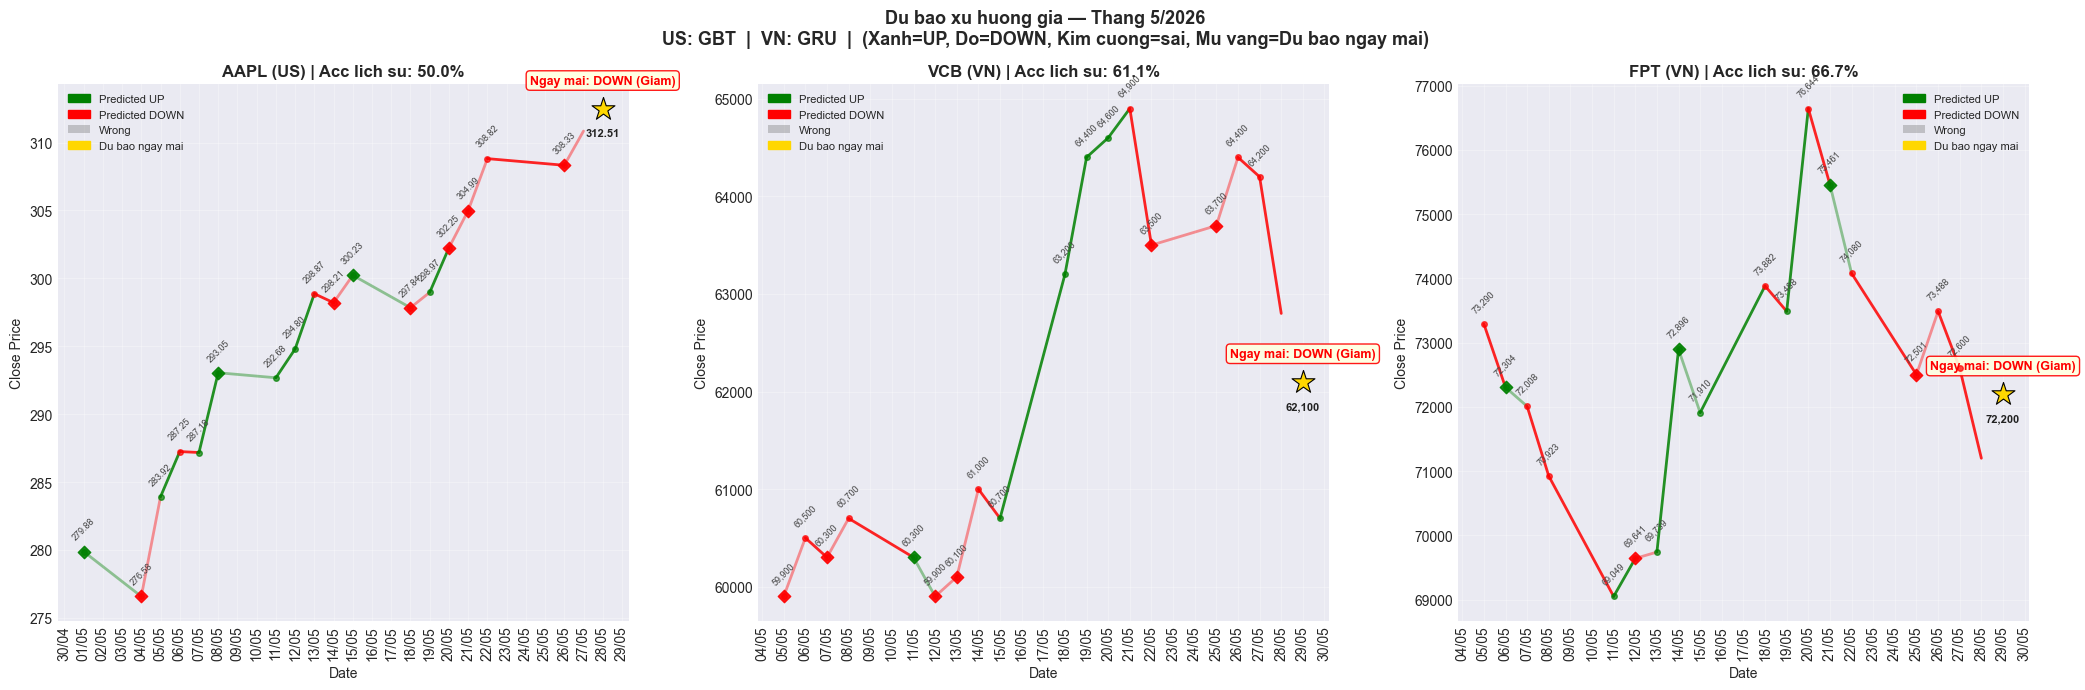


DU BAO XU HUONG — PHIEN GIAO DICH TIEP THEO
(Moi ma tinh theo ngay du lieu cuoi cung cua chinh no)
  AAPL   (US ) | ▼ DOWN | Close 28/05:      312.51 | Du bao phien 29/05/2026
  VCB    (VN ) | ▼ DOWN | Close 29/05:   62,100.00 | Du bao phien 01/06/2026
  FPT    (VN ) | ▼ DOWN | Close 29/05:   72,200.00 | Du bao phien 01/06/2026
* Du bao dua tren mo hinh train den 2021. Khong phai tu van dau tu.


In [54]:
# ── Ve bieu do gia + du bao ngay mai ────────────────────────────────────────
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from datetime import date, timedelta
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f'Du bao xu huong gia — Thang {date.today().month}/{date.today().year}\n'
             f'US: {best_us_name}  |  VN: {best_vn_name}  |  '
             '(Xanh=UP, Do=DOWN, Kim cuong=sai, Mu vang=Du bao ngay mai)',
             fontsize=13, fontweight='bold')

tickers      = ['AAPL', 'VCB', 'FPT']
group_labels = ['US',   'VN',  'VN']
next_day_preds = {}

for ax, sym, grp in zip(axes, tickers, group_labels):
    df_full = demo_results[sym].copy().reset_index(drop=True)
    df_full['time'] = pd.to_datetime(df_full['time'])
    df_plot = df_full[df_full['time'] >= pd.Timestamp(DEMO_START)].reset_index(drop=True)

    if len(df_plot) < 2:
        ax.set_title(f'{sym}: khong du du lieu')
        continue

    # ── Phan qua khu: co actual de so sanh ───────────────────────────────Winner    : RF   
    df_hist = df_plot.copy()
    df_hist['next_close'] = df_hist['close'].shift(-1)
    df_hist['actual_dir'] = (df_hist['next_close'] > df_hist['close']).astype('Int64')
    df_known = df_hist.dropna(subset=['next_close']).copy()

    correct = df_known['prediction'] == df_known['actual_dir']
    acc = correct.mean() * 100 if len(correct) > 0 else 0

    for i in range(len(df_known) - 1):
        row   = df_known.iloc[i]
        color = 'green' if row['prediction'] == 1 else 'red'
        alpha = 0.85 if correct.iloc[i] else 0.4
        ax.plot([df_known['time'].iloc[i], df_known['time'].iloc[i+1]],
                [row['close'], df_known['close'].iloc[i+1]],
                color=color, linewidth=2, alpha=alpha)
        if not correct.iloc[i]:
            ax.scatter(row['time'], row['close'], marker='D', s=40,
                       color=color, zorder=5, alpha=0.9)
        ax.scatter(row['time'], row['close'], s=16, color=color, alpha=0.7, zorder=4)
        price_fmt = f'{float(row["close"]):.2f}' if grp == 'US' else f'{float(row["close"]):,.0f}'
        ax.annotate(price_fmt, xy=(row['time'], row['close']),
                    xytext=(0, 7), textcoords='offset points',
                    fontsize=6.5, ha='center', va='bottom', color='#444', rotation=45)

    # ── Du bao ngay mai: row cuoi cung ───────────────────────────────────
    last_row  = df_plot.iloc[-1]
    pred_dir  = int(last_row['prediction'])
    pred_color= 'green' if pred_dir == 1 else 'red'
    pred_label= 'UP (Tang)' if pred_dir == 1 else 'DOWN (Giam)'
    next_day_preds[sym] = pred_dir

    # Ve dau * lon tren ngay hom nay
    ax.scatter(last_row['time'], last_row['close'],
               marker='*', s=300, color='gold', zorder=10,
               edgecolors='black', linewidth=0.8)
    price_fmt_last = f'{float(last_row["close"]):.2f}' if grp == 'US' else f'{float(last_row["close"]):,.0f}'
    ax.annotate(price_fmt_last, xy=(last_row['time'], last_row['close']),
                xytext=(0, -14), textcoords='offset points',
                fontsize=8, ha='center', va='top', color='#222', fontweight='bold')

    # Annotation box
    ax.annotate(f'Ngay mai: {pred_label}',
                xy=(last_row['time'], last_row['close']),
                xytext=(0, 18), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold',
                color=pred_color,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow',
                          ec=pred_color, alpha=0.9))

    ax.set_title(f'{sym} ({grp}) | Acc lich su: {acc:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, alpha=0.3)

    up_patch   = mpatches.Patch(color='green', label='Predicted UP')
    down_patch = mpatches.Patch(color='red',   label='Predicted DOWN')
    err_patch  = mpatches.Patch(facecolor='gray', alpha=0.4, label='Wrong')
    star_patch = mpatches.Patch(color='gold', label='Du bao ngay mai')
    ax.legend(handles=[up_patch, down_patch, err_patch, star_patch],
              fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# ── Bang tom tat du bao phien giao dich tiep theo ────────────────────────────
from datetime import date, timedelta
import numpy as np

def next_trading_day(last_dt):
    """Phien giao dich ke tiep sau ngay co du lieu cuoi cung (bo qua T7/CN).
    Dua vao ngay du lieu thuc te cua tung ma -> tu dong dung cho ca 2 mui gio
    (US dong cua dem theo gio VN, VN dong cua chieu) va lich nghi khac nhau."""
    nxt = last_dt + timedelta(days=1)
    while nxt.weekday() >= 5:
        nxt += timedelta(days=1)
    return nxt

print('\n' + '='*64)
print('DU BAO XU HUONG — PHIEN GIAO DICH TIEP THEO')
print('(Moi ma tinh theo ngay du lieu cuoi cung cua chinh no)')
print('='*64)
for sym, grp in zip(tickers, group_labels):
    pred  = next_day_preds.get(sym, -1)
    arrow = '  UP' if pred == 1 else 'DOWN'
    icon  = '▲' if pred == 1 else '▼'
    df_f  = demo_results[sym]
    last_dt    = pd.to_datetime(df_f['time'].iloc[-1]).date()
    last_close = df_f['close'].iloc[-1]
    nxt        = next_trading_day(last_dt)
    print(f'  {sym:<6} ({grp:<3}) | {icon} {arrow} | '
          f'Close {last_dt.strftime("%d/%m")}: {last_close:>11,.2f} | '
          f'Du bao phien {nxt.strftime("%d/%m/%Y")}')

print('='*64)
print('* Du bao dua tren mo hinh train den 2021. Khong phai tu van dau tu.')


Ve Hinh 4.1...


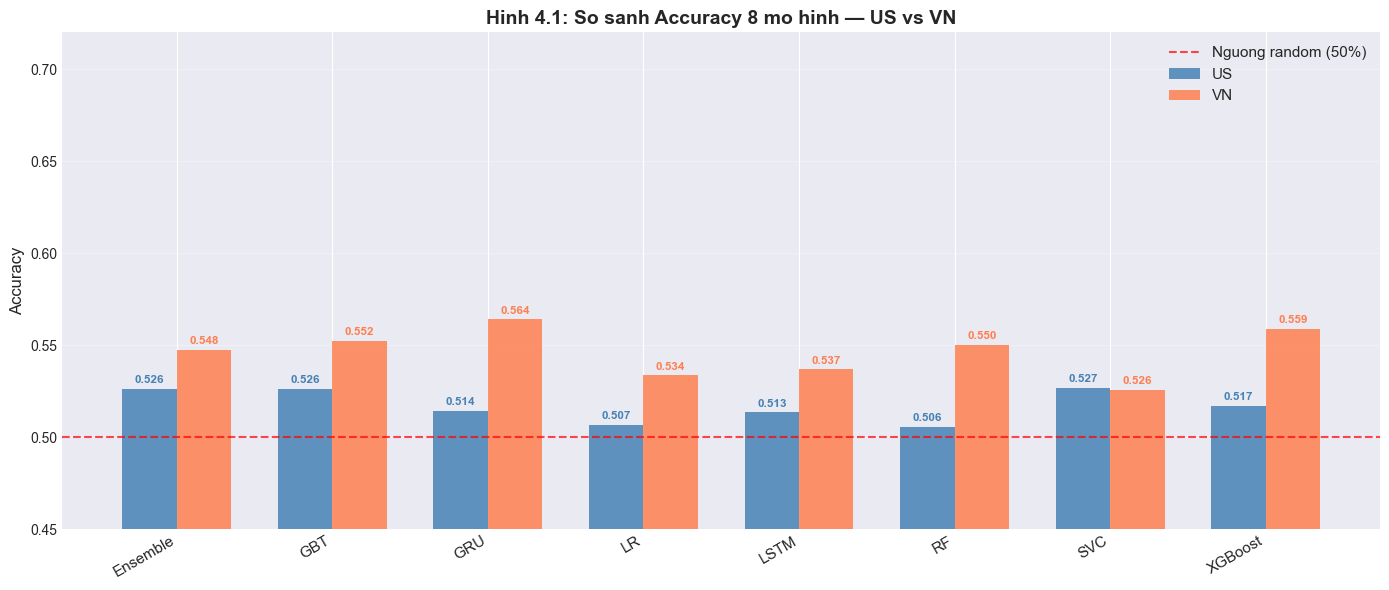

  Saved: figures/Hinh_4_1.png
Ve Hinh 4.2...


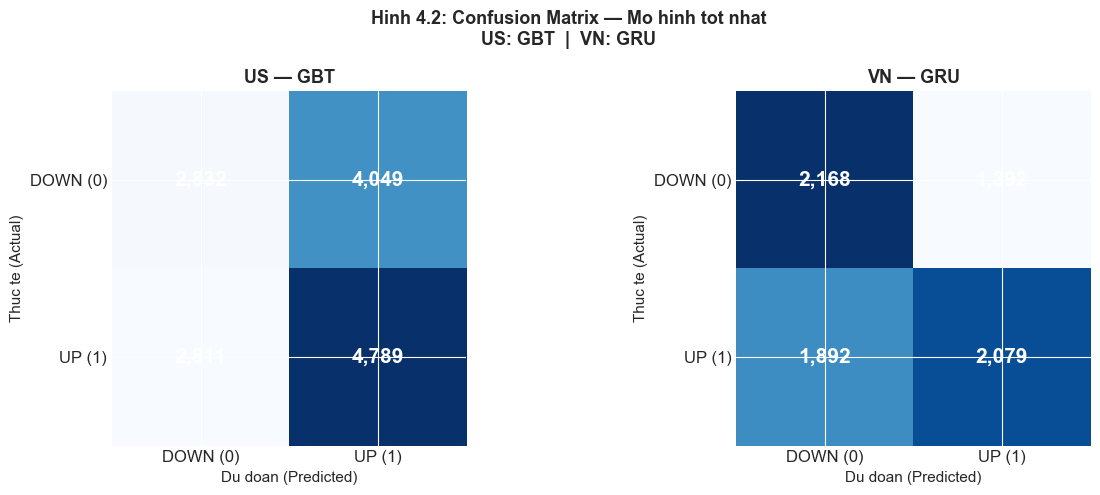

  Saved: figures/Hinh_4_2.png
Ve Hinh 4.3...


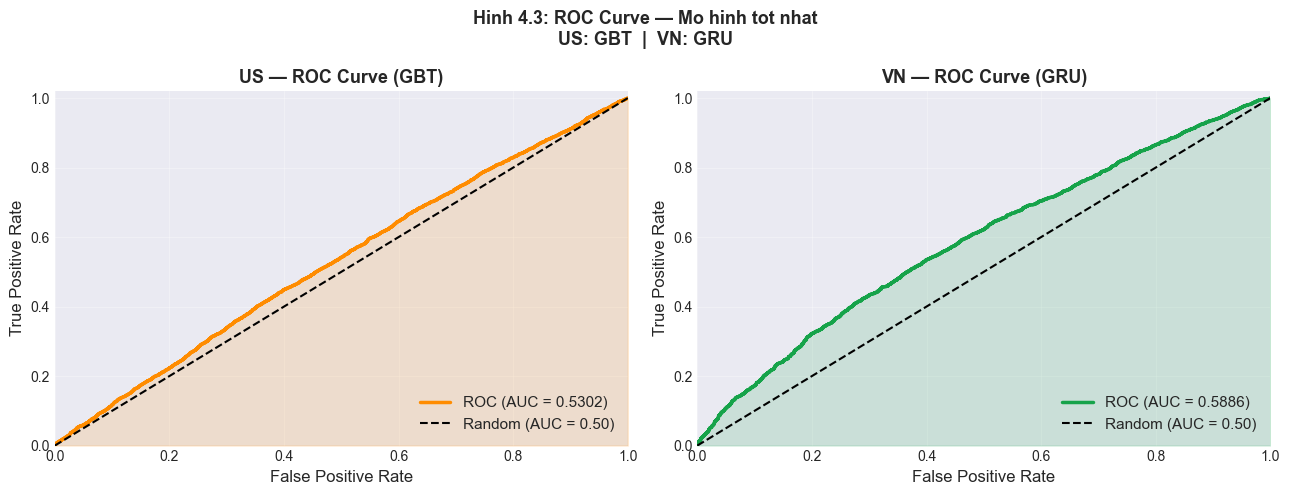

  Saved: figures/Hinh_4_3.png
Ve Hinh 4.4...


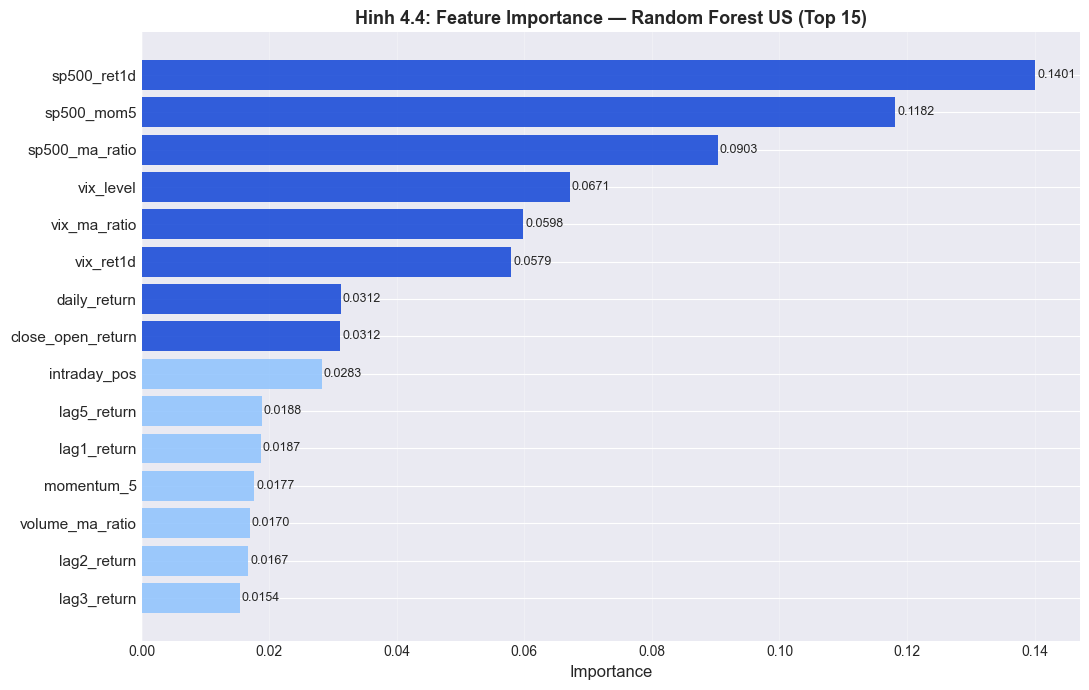

  Saved: figures/Hinh_4_4.png
Ve Hinh 4.5...


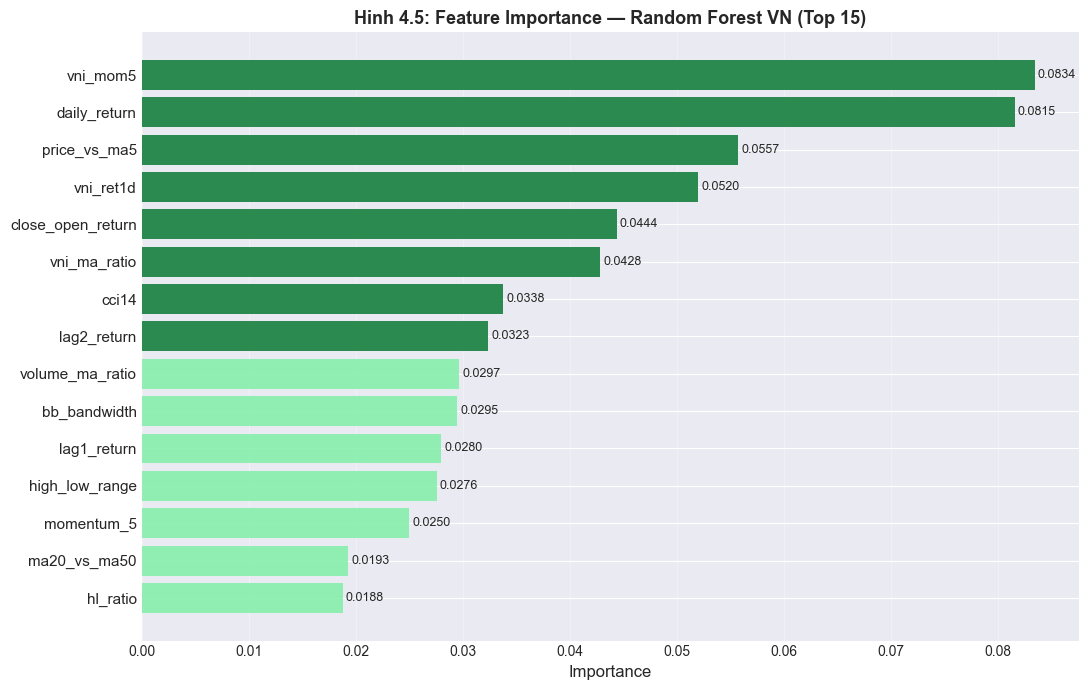

  Saved: figures/Hinh_4_5.png
Ve Hinh 4.6...


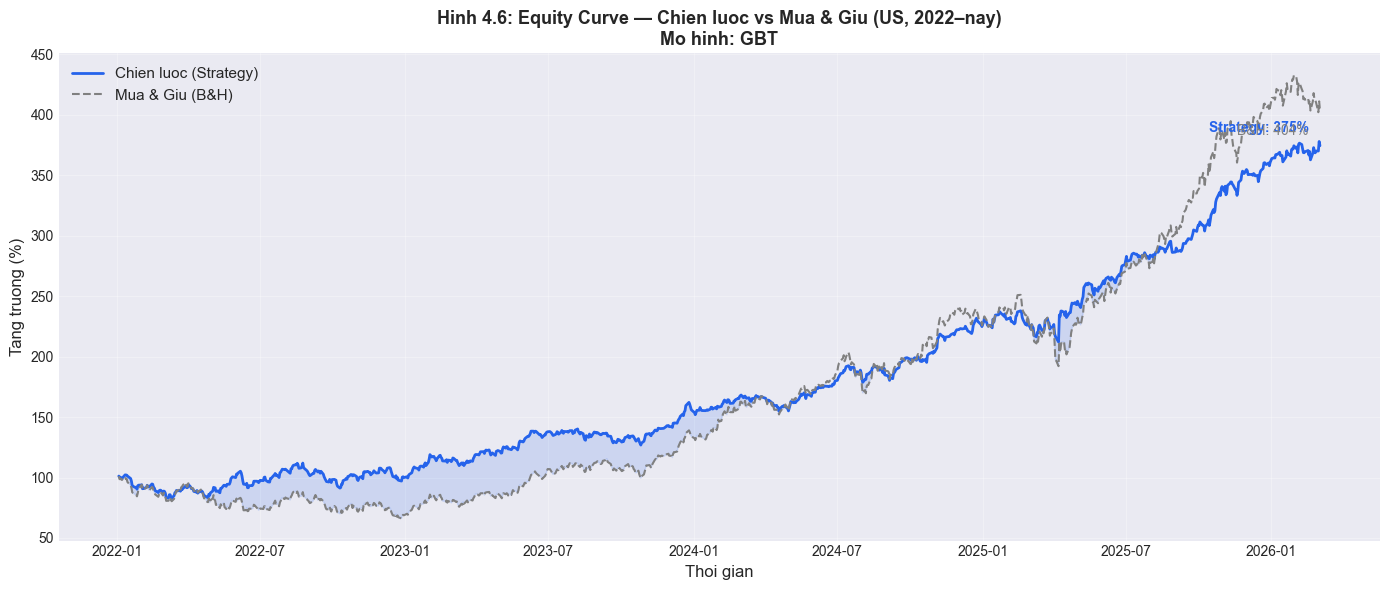

  Saved: figures/Hinh_4_6.png
Ve Hinh 4.7...


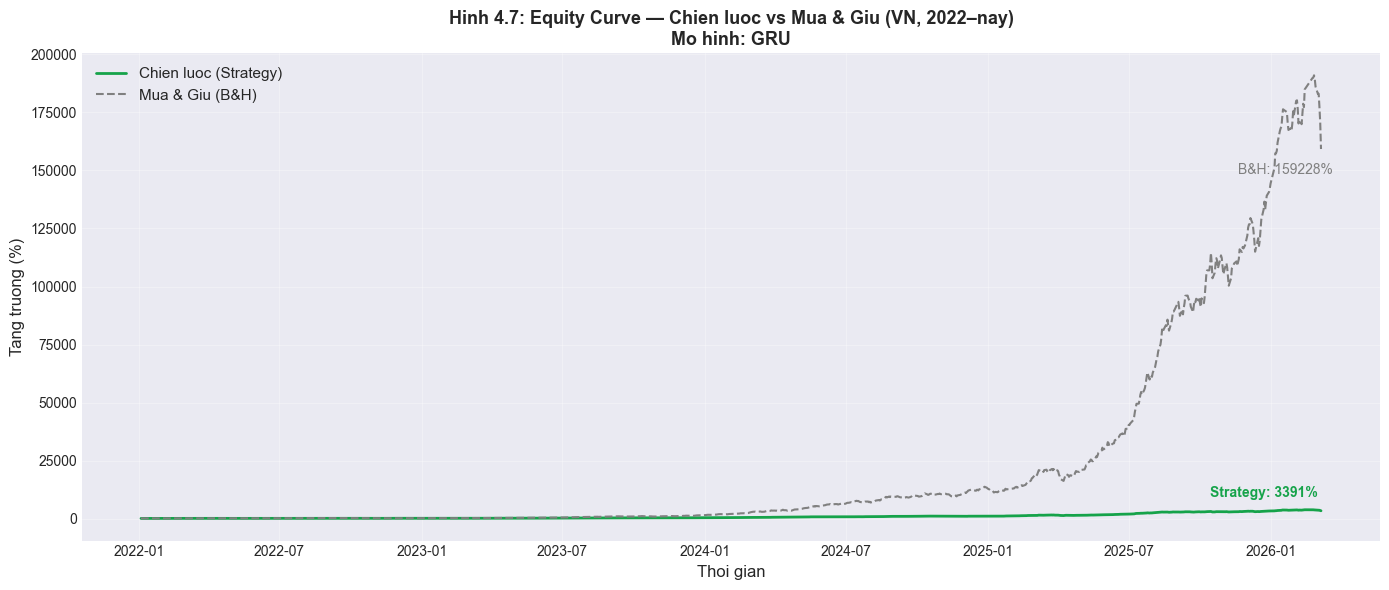

  Saved: figures/Hinh_4_7.png
Ve Hinh 4.8...


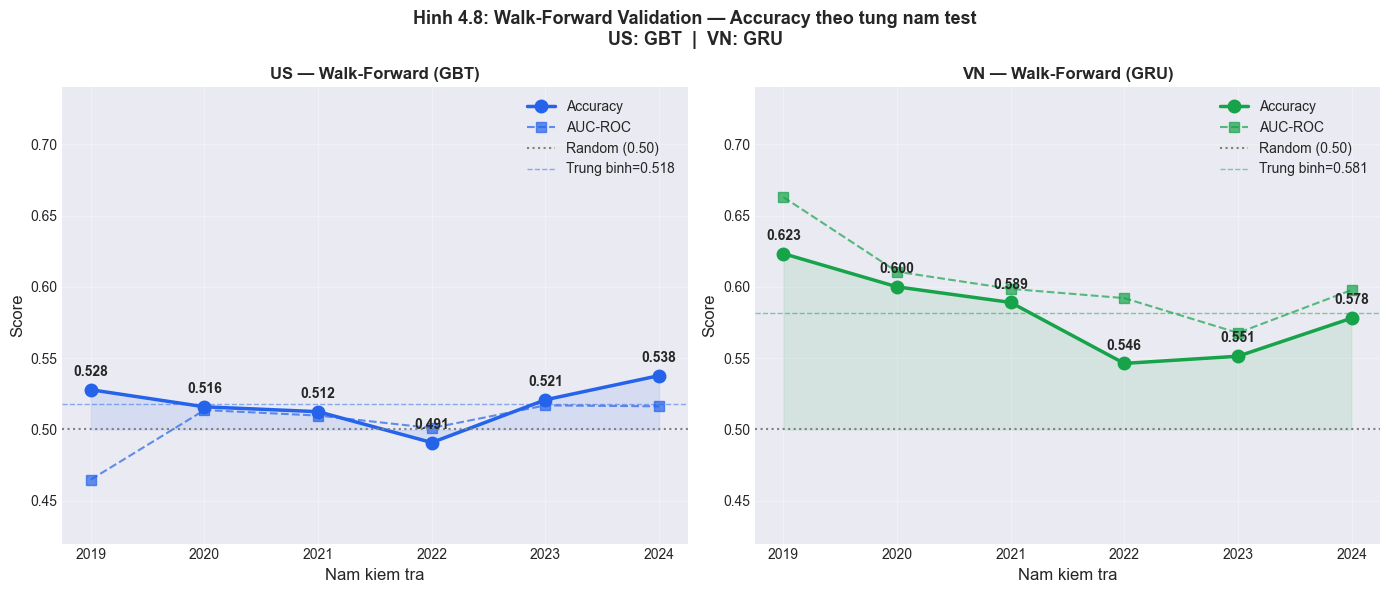

  Saved: figures/Hinh_4_8.png
Ve Hinh 5.1...


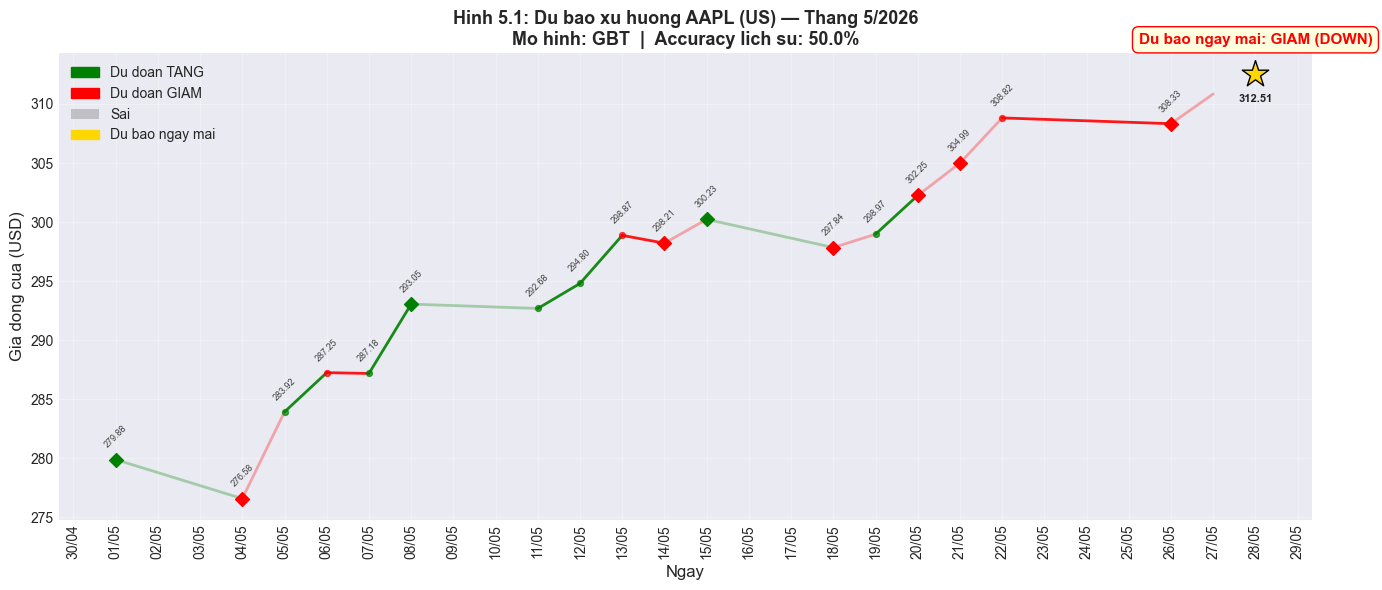

  Saved: figures/Hinh_5_1.png
Ve Hinh 5.2...


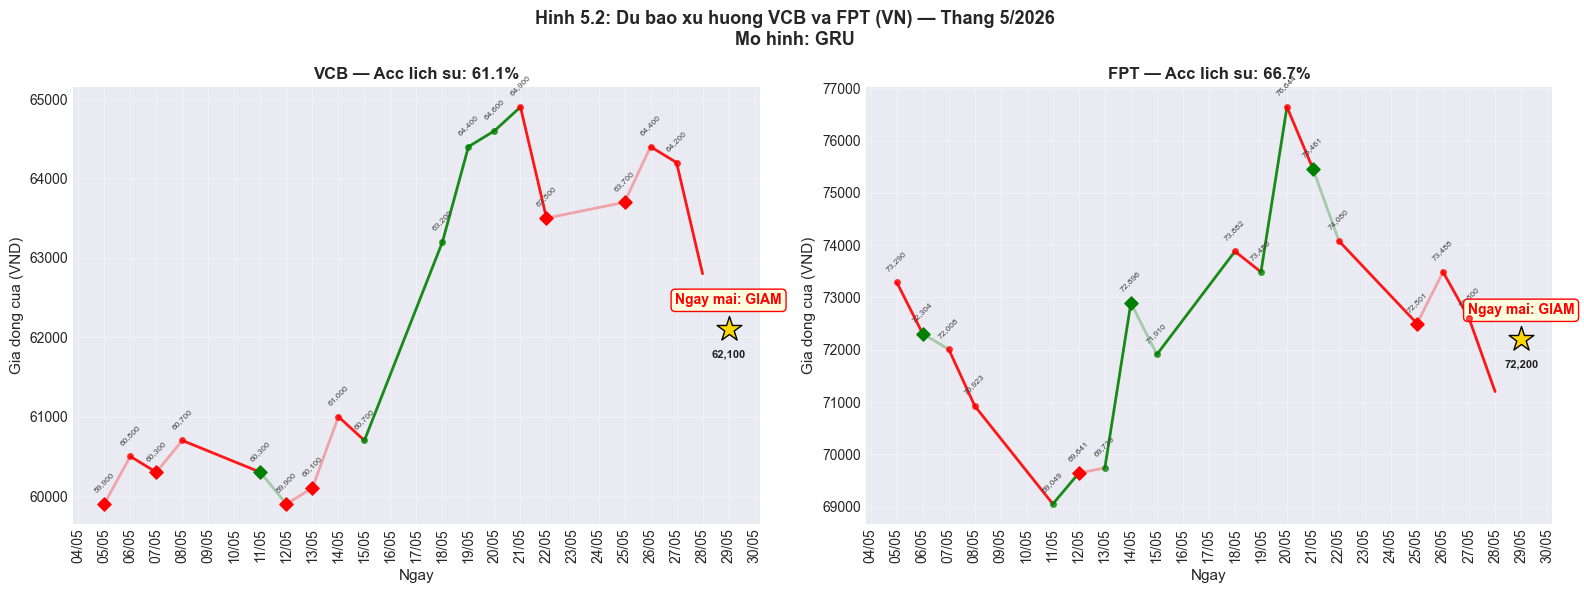

  Saved: figures/Hinh_5_2.png

HOAN TAT! Mo hinh tot nhat: US=GBT | VN=GRU
Tat ca hinh da luu vao: figures/
  Hinh_4_1.png  (108 KB)
  Hinh_4_2.png  (74 KB)
  Hinh_4_3.png  (157 KB)
  Hinh_4_4.png  (123 KB)
  Hinh_4_5.png  (124 KB)
  Hinh_4_6.png  (206 KB)
  Hinh_4_7.png  (131 KB)
  Hinh_4_8.png  (177 KB)
  Hinh_5_1.png  (180 KB)
  Hinh_5_2.png  (265 KB)


In [55]:
# ═══════════════════════════════════════════════════════════════
# XUAT HINH ANH CHO BAO CAO — Luu vao thu muc figures/
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import os
from datetime import date
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc

os.makedirs('figures', exist_ok=True)
DPI = 200

def save_fig(fig, filename, label):
    fpath = f'figures/{filename}.png'
    fig.savefig(fpath, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  Saved: {fpath}')

def _equity_preds_pd(res, res_xgb, res_dl, best_name):
    """Lay DataFrame co time/close/next_close/prediction cho mo hinh tot nhat."""
    cols = ['time', 'close', 'next_close', 'label', 'prediction']
    if best_name == 'XGBoost':
        df = res_xgb['df_ts'].copy()
        df['prediction'] = res_xgb['y_pred']
        avail = [c for c in cols if c in df.columns]
        return df[avail]
    elif best_name in ('LSTM', 'GRU'):
        dl_met = res_dl['metrics'].get(best_name, {})
        if 'df_ts_pd' in dl_met:
            df = dl_met['df_ts_pd'].copy()
            y_pred = dl_met.get('y_pred', None)
            if y_pred is None:
                y_pred = [0] * len(df)
            # LSTM/GRU mat seq_len-1 dong dau do cua so truot -> cat tail cho khop
            if len(y_pred) != len(df):
                df = df.iloc[-len(y_pred):].reset_index(drop=True)
            df['prediction'] = y_pred
            avail = [c for c in cols if c in df.columns]
            return df[avail]
        else:
            print(f'  [Note] {best_name} chua co df_ts_pd -> dung XGBoost data cho equity curve')
            df = res_xgb['df_ts'].copy()
            df['prediction'] = res_xgb['y_pred']
            avail = [c for c in cols if c in df.columns]
            return df[avail]
    else:  # Spark model (LR/RF/GBT/SVC/Ensemble)
        avail = [c for c in cols if c in res['predictions'][best_name].columns]
        return res['predictions'][best_name].select(*avail).toPandas()

# FIX: Xay dung compare_df tu all_us_scores/all_vn_scores (Cell chon mo hinh) cho Hinh 4.1
_rows = []
for _m, _info in all_us_scores.items():
    _rows.append({'Model': _m, 'Market': 'US', 'Accuracy': _info['accuracy'], 'AUC': _info['auc']})
for _m, _info in all_vn_scores.items():
    _rows.append({'Model': _m, 'Market': 'VN', 'Accuracy': _info['accuracy'], 'AUC': _info['auc']})
compare_df = pd.DataFrame(_rows)

# ── Hinh 4.1: So sanh Accuracy 8 mo hinh US vs VN ──────────────────────────
print('Ve Hinh 4.1...')
fig, ax = plt.subplots(figsize=(14, 6))
sub = compare_df.pivot_table(index='Model', columns='Market', values='Accuracy')
x = np.arange(len(sub)); w = 0.35
us_vals = sub.get('US', pd.Series([0]*len(sub), index=sub.index)).values
vn_vals = sub.get('VN', pd.Series([0]*len(sub), index=sub.index)).values
ax.bar(x - w/2, us_vals, w, label='US', color='steelblue', alpha=0.85)
ax.bar(x + w/2, vn_vals, w, label='VN', color='coral',     alpha=0.85)
for i, (u, v) in enumerate(zip(us_vals, vn_vals)):
    ax.text(i - w/2, u + 0.002, f'{u:.3f}', ha='center', va='bottom', fontsize=8.5, color='steelblue', fontweight='bold')
    ax.text(i + w/2, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, color='coral',     fontweight='bold')
ax.axhline(0.5, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Nguong random (50%)')
ax.set_xticks(x); ax.set_xticklabels(sub.index, rotation=30, ha='right', fontsize=11)
ax.set_title('Hinh 4.1: So sanh Accuracy 8 mo hinh — US vs VN', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12); ax.set_ylim(0.45, 0.72)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); save_fig(fig, 'Hinh_4_1', '4.1')

# ── Hinh 4.2: Confusion Matrix — Mo hinh tot nhat US va VN ─────────────────
print('Ve Hinh 4.2...')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Hinh 4.2: Confusion Matrix — Mo hinh tot nhat\nUS: {best_us_name}  |  VN: {best_vn_name}',
             fontsize=13, fontweight='bold')
for ax, (res, rxgb, rdl, best_name, mkt) in zip(axes, [
    (res_us, res_us_xgb, res_us_dl, best_us_name, 'US'),
    (res_vn, res_vn_xgb, res_vn_dl, best_vn_name, 'VN'),
]):
    yt, yp, _, _, _, _ = get_model_eval_data(res, rxgb, rdl, best_name)
    cm = confusion_matrix(yt, yp)
    ax.imshow(cm, cmap='Blues')
    for (ii, jj), v in np.ndenumerate(cm):
        ax.text(jj, ii, f'{v:,d}', ha='center', va='center', fontsize=15, fontweight='bold',
                color='white' if v > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['DOWN (0)', 'UP (1)'], fontsize=12)
    ax.set_yticklabels(['DOWN (0)', 'UP (1)'], fontsize=12)
    ax.set_xlabel('Du doan (Predicted)', fontsize=11); ax.set_ylabel('Thuc te (Actual)', fontsize=11)
    ax.set_title(f'{mkt} — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig(fig, 'Hinh_4_2', '4.2')

# ── Hinh 4.3: ROC Curve — Mo hinh tot nhat US va VN ───────────────────────
print('Ve Hinh 4.3...')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Hinh 4.3: ROC Curve — Mo hinh tot nhat\nUS: {best_us_name}  |  VN: {best_vn_name}',
             fontsize=13, fontweight='bold')
for ax, (res, rxgb, rdl, best_name, mkt, clr) in zip(axes, [
    (res_us, res_us_xgb, res_us_dl, best_us_name, 'US', 'darkorange'),
    (res_vn, res_vn_xgb, res_vn_dl, best_vn_name, 'VN', '#16A34A'),
]):
    yt, _, yprb, _, _, _ = get_model_eval_data(res, rxgb, rdl, best_name)
    fpr, tpr, _ = roc_curve(yt, yprb)
    auc_val = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=clr, lw=2.5, label=f'ROC (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.50)')
    ax.fill_between(fpr, tpr, alpha=0.15, color=clr)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{mkt} — ROC Curve ({best_name})', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); save_fig(fig, 'Hinh_4_3', '4.3')

# ── Hinh 4.4: Feature Importance RF — US Top 15 ─────────────────────────────
print('Ve Hinh 4.4...')
fi_us = res_us['feature_importance'][:15]
n_us  = [f[0] for f in fi_us][::-1]; s_us = [float(f[1]) for f in fi_us][::-1]
fig, ax = plt.subplots(figsize=(11, 7))
med = np.median(s_us)
cbars = ['#1D4ED8' if v >= med else '#93C5FD' for v in s_us]
bars = ax.barh(n_us, s_us, color=cbars, alpha=0.9)
for bar, val in zip(bars, s_us):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Hinh 4.4: Feature Importance — Random Forest US (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12); ax.tick_params(axis='y', labelsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); save_fig(fig, 'Hinh_4_4', '4.4')

# ── Hinh 4.5: Feature Importance RF — VN Top 15 ─────────────────────────────
print('Ve Hinh 4.5...')
fi_vn = res_vn['feature_importance'][:15]
n_vn  = [f[0] for f in fi_vn][::-1]; s_vn = [float(f[1]) for f in fi_vn][::-1]
fig, ax = plt.subplots(figsize=(11, 7))
med = np.median(s_vn)
cbars = ['#15803D' if v >= med else '#86EFAC' for v in s_vn]
bars = ax.barh(n_vn, s_vn, color=cbars, alpha=0.9)
for bar, val in zip(bars, s_vn):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Hinh 4.5: Feature Importance — Random Forest VN (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12); ax.tick_params(axis='y', labelsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); save_fig(fig, 'Hinh_4_5', '4.5')

# ── Hinh 4.6: Backtest Equity Curve — US (mo hinh tot nhat) ─────────────────
print('Ve Hinh 4.6...')
pred_us = _equity_preds_pd(res_us, res_us_xgb, res_us_dl, best_us_name)
pred_us['time'] = pd.to_datetime(pred_us['time'])
pred_us = pred_us.sort_values('time').reset_index(drop=True)
pred_us['act']   = (pred_us['next_close'] - pred_us['close']) / pred_us['close']
pred_us['strat'] = pred_us.apply(lambda r: r['act'] if r['prediction'] == 1 else 0, axis=1)
d_us = pred_us.groupby('time')[['act', 'strat']].mean().reset_index()
d_us['eq_bnh']   = (1 + d_us['act']).cumprod()   * 100
d_us['eq_strat'] = (1 + d_us['strat']).cumprod() * 100
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(d_us['time'], d_us['eq_strat'], color='#2563EB', lw=2,   label='Chien luoc (Strategy)')
ax.plot(d_us['time'], d_us['eq_bnh'],   color='gray',   lw=1.5, ls='--', label='Mua & Giu (B&H)')
ax.fill_between(d_us['time'], d_us['eq_strat'], d_us['eq_bnh'],
                where=d_us['eq_strat'] >= d_us['eq_bnh'], alpha=0.15, color='#2563EB')
final_s = d_us['eq_strat'].iloc[-1]; final_b = d_us['eq_bnh'].iloc[-1]
ax.annotate(f'Strategy: {final_s:.0f}%', xy=(d_us['time'].iloc[-1], final_s),
            xytext=(-80, 10), textcoords='offset points', fontsize=10, color='#2563EB', fontweight='bold')
ax.annotate(f'B&H: {final_b:.0f}%', xy=(d_us['time'].iloc[-1], final_b),
            xytext=(-60, -18), textcoords='offset points', fontsize=10, color='gray')
ax.set_title(f'Hinh 4.6: Equity Curve — Chien luoc vs Mua & Giu (US, 2022–nay)\nMo hinh: {best_us_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Thoi gian', fontsize=12); ax.set_ylabel('Tang truong (%)', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); save_fig(fig, 'Hinh_4_6', '4.6')

# ── Hinh 4.7: Backtest Equity Curve — VN (mo hinh tot nhat) ─────────────────
print('Ve Hinh 4.7...')
pred_vn = _equity_preds_pd(res_vn, res_vn_xgb, res_vn_dl, best_vn_name)
pred_vn['time'] = pd.to_datetime(pred_vn['time'])
pred_vn = pred_vn.sort_values('time').reset_index(drop=True)
pred_vn['act']   = (pred_vn['next_close'] - pred_vn['close']) / pred_vn['close']
pred_vn['strat'] = pred_vn.apply(lambda r: r['act'] if r['prediction'] == 1 else 0, axis=1)
d_vn = pred_vn.groupby('time')[['act', 'strat']].mean().reset_index()
d_vn['eq_bnh']   = (1 + d_vn['act']).cumprod()   * 100
d_vn['eq_strat'] = (1 + d_vn['strat']).cumprod() * 100
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(d_vn['time'], d_vn['eq_strat'], color='#16A34A', lw=2,   label='Chien luoc (Strategy)')
ax.plot(d_vn['time'], d_vn['eq_bnh'],   color='gray',   lw=1.5, ls='--', label='Mua & Giu (B&H)')
ax.fill_between(d_vn['time'], d_vn['eq_strat'], d_vn['eq_bnh'],
                where=d_vn['eq_strat'] >= d_vn['eq_bnh'], alpha=0.15, color='#16A34A')
final_s = d_vn['eq_strat'].iloc[-1]; final_b = d_vn['eq_bnh'].iloc[-1]
ax.annotate(f'Strategy: {final_s:.0f}%', xy=(d_vn['time'].iloc[-1], final_s),
            xytext=(-80, 10), textcoords='offset points', fontsize=10, color='#16A34A', fontweight='bold')
ax.annotate(f'B&H: {final_b:.0f}%', xy=(d_vn['time'].iloc[-1], final_b),
            xytext=(-60, -18), textcoords='offset points', fontsize=10, color='gray')
ax.set_title(f'Hinh 4.7: Equity Curve — Chien luoc vs Mua & Giu (VN, 2022–nay)\nMo hinh: {best_vn_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Thoi gian', fontsize=12); ax.set_ylabel('Tang truong (%)', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); save_fig(fig, 'Hinh_4_7', '4.7')


# ── Hinh 4.8: Walk-Forward Accuracy theo tung nam ───────────────────────────
print('Ve Hinh 4.8...')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Hinh 4.8: Walk-Forward Validation — Accuracy theo tung nam test\nUS: {best_us_name}  |  VN: {best_vn_name}',
             fontsize=13, fontweight='bold')
for ax, (wfr, mkt, clr, best_name) in zip(axes, [
    (wf_us, 'US', '#2563EB', best_us_name),
    (wf_vn, 'VN', '#16A34A', best_vn_name),
]):
    if not wfr: ax.set_title(f'{mkt}: no data'); continue
    yrs  = [r['test_year'] for r in wfr]
    accs = [r['accuracy']  for r in wfr]
    aucs = [r['auc']       for r in wfr]
    mean_acc = np.mean(accs)
    ax.plot(yrs, accs, 'o-',  color=clr, lw=2.5, ms=9,  label='Accuracy')
    ax.plot(yrs, aucs, 's--', color=clr, lw=1.5, ms=7, alpha=0.7, label='AUC-ROC')
    ax.axhline(0.5,      color='gray', ls=':', lw=1.5, label='Random (0.50)')
    ax.axhline(mean_acc, color=clr, ls='--', lw=1, alpha=0.5, label=f'Trung binh={mean_acc:.3f}')
    ax.fill_between(yrs, 0.5, accs, alpha=0.1, color=clr)
    for yr, ac in zip(yrs, accs):
        ax.annotate(f'{ac:.3f}', (yr, ac), textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{mkt} — Walk-Forward ({best_name})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nam kiem tra', fontsize=12); ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0.42, 0.74); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); save_fig(fig, 'Hinh_4_8', '4.8')

# ── Hinh 5.1: Du bao AAPL (US) ──────────────────────────────────────────────
print('Ve Hinh 5.1...')
try:
    df_aa = demo_results['AAPL'].copy()
    df_aa['time'] = pd.to_datetime(df_aa['time'])
    df_aa = df_aa[df_aa['time'] >= pd.Timestamp(DEMO_START)].reset_index(drop=True)
    df_aa['nx'] = df_aa['close'].shift(-1)
    df_aa['ad'] = (df_aa['nx'] > df_aa['close']).astype('Int64')
    dk = df_aa.dropna(subset=['nx']).copy()
    ok = dk['prediction'] == dk['ad']
    fig, ax = plt.subplots(figsize=(14, 6))
    for i in range(len(dk) - 1):
        r = dk.iloc[i]; c = 'green' if r['prediction'] == 1 else 'red'; a = 0.9 if ok.iloc[i] else 0.3
        ax.plot([dk['time'].iloc[i], dk['time'].iloc[i+1]], [r['close'], dk['close'].iloc[i+1]], color=c, lw=2, alpha=a)
        if not ok.iloc[i]: ax.scatter(r['time'], r['close'], marker='D', s=50, color=c, zorder=5)
        ax.scatter(r['time'], r['close'], s=18, color=c, alpha=0.7, zorder=4)
        ax.annotate(f'{float(r["close"]):.2f}', xy=(r['time'], r['close']),
                    xytext=(0, 7), textcoords='offset points',
                    fontsize=6.5, ha='center', va='bottom', color='#444', rotation=45)
    last = df_aa.iloc[-1]; pd_dir = int(last['prediction'])
    pd_lbl = 'TANG (UP)' if pd_dir == 1 else 'GIAM (DOWN)'; pd_c = 'green' if pd_dir == 1 else 'red'
    ax.scatter(last['time'], last['close'], marker='*', s=400, color='gold', zorder=10, edgecolors='black')
    ax.annotate(f'{float(last["close"]):.2f}', xy=(last['time'], last['close']),
                xytext=(0, -14), textcoords='offset points',
                fontsize=8, ha='center', va='top', color='#222', fontweight='bold')
    ax.annotate(f'Du bao ngay mai: {pd_lbl}', xy=(last['time'], last['close']),
                xytext=(0, 22), textcoords='offset points', ha='center', fontsize=11,
                fontweight='bold', color=pd_c,
                bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec=pd_c))
    acc_aa = ok.mean() * 100
    ax.set_title(f'Hinh 5.1: Du bao xu huong AAPL (US) — Thang {date.today().month}/{date.today().year}\nMo hinh: {best_us_name}  |  Accuracy lich su: {acc_aa:.1f}%',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Ngay', fontsize=12); ax.set_ylabel('Gia dong cua (USD)', fontsize=12)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)
    up_p = mpatches.Patch(color='green', label='Du doan TANG'); dn_p = mpatches.Patch(color='red', label='Du doan GIAM')
    er_p = mpatches.Patch(facecolor='gray', alpha=0.4, label='Sai'); st_p = mpatches.Patch(color='gold', label='Du bao ngay mai')
    ax.legend(handles=[up_p, dn_p, er_p, st_p], fontsize=10)
    plt.tight_layout(); save_fig(fig, 'Hinh_5_1', '5.1')
except Exception as e:
    print(f'  Hinh 5.1 bo qua (chua chay cell du bao): {e}')

# ── Hinh 5.2: Du bao VCB va FPT (VN) ────────────────────────────────────────
print('Ve Hinh 5.2...')
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Hinh 5.2: Du bao xu huong VCB va FPT (VN) — Thang {date.today().month}/{date.today().year}\nMo hinh: {best_vn_name}',
                 fontsize=13, fontweight='bold')
    for ax, sym in zip(axes, ['VCB', 'FPT']):
        df_s = demo_results[sym].copy()
        df_s['time'] = pd.to_datetime(df_s['time'])
        df_s = df_s[df_s['time'] >= pd.Timestamp(DEMO_START)].reset_index(drop=True)
        df_s['nx'] = df_s['close'].shift(-1)
        df_s['ad'] = (df_s['nx'] > df_s['close']).astype('Int64')
        dk = df_s.dropna(subset=['nx']).copy(); ok = dk['prediction'] == dk['ad']
        for i in range(len(dk) - 1):
            r = dk.iloc[i]; c = 'green' if r['prediction'] == 1 else 'red'; a = 0.9 if ok.iloc[i] else 0.3
            ax.plot([dk['time'].iloc[i], dk['time'].iloc[i+1]], [r['close'], dk['close'].iloc[i+1]], color=c, lw=2, alpha=a)
            if not ok.iloc[i]: ax.scatter(r['time'], r['close'], marker='D', s=45, color=c, zorder=5)
            ax.scatter(r['time'], r['close'], s=16, color=c, alpha=0.7, zorder=4)
            ax.annotate(f'{float(r["close"]):,.0f}', xy=(r['time'], r['close']),
                        xytext=(0, 7), textcoords='offset points',
                        fontsize=6, ha='center', va='bottom', color='#444', rotation=45)
        last = df_s.iloc[-1]; pd_dir = int(last['prediction'])
        pd_lbl = 'TANG' if pd_dir == 1 else 'GIAM'; pd_c = 'green' if pd_dir == 1 else 'red'
        ax.scatter(last['time'], last['close'], marker='*', s=350, color='gold', zorder=10, edgecolors='black')
        ax.annotate(f'{float(last["close"]):,.0f}', xy=(last['time'], last['close']),
                    xytext=(0, -14), textcoords='offset points',
                    fontsize=8, ha='center', va='top', color='#222', fontweight='bold')
        ax.annotate(f'Ngay mai: {pd_lbl}', xy=(last['time'], last['close']),
                    xytext=(0, 18), textcoords='offset points', ha='center', fontsize=10,
                    fontweight='bold', color=pd_c, bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec=pd_c))
        acc_s = ok.mean() * 100
        ax.set_title(f'{sym} — Acc lich su: {acc_s:.1f}%', fontsize=12, fontweight='bold')
        ax.set_xlabel('Ngay', fontsize=11); ax.set_ylabel('Gia dong cua (VND)', fontsize=11)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
        ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)
    plt.tight_layout(); save_fig(fig, 'Hinh_5_2', '5.2')
except Exception as e:
    print(f'  Hinh 5.2 bo qua (chua chay cell du bao): {e}')

# ── Tong ket ─────────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print(f'HOAN TAT! Mo hinh tot nhat: US={best_us_name} | VN={best_vn_name}')
print('Tat ca hinh da luu vao: figures/')
print('=' * 60)
for fn in ['Hinh_4_1', 'Hinh_4_2', 'Hinh_4_3', 'Hinh_4_4', 'Hinh_4_5',
           'Hinh_4_6', 'Hinh_4_7', 'Hinh_4_8', 'Hinh_5_1', 'Hinh_5_2']:
    fp = f'figures/{fn}.png'
    size = os.path.getsize(fp) / 1024 if os.path.exists(fp) else 0
    print(f'  {fn}.png  ({size:.0f} KB)')

## PHẦN CUỐI: TỔNG HỢP TẤT CẢ CẢI TIẾN

### Các cải tiến đã thực hiện:

| # | Cải tiến | Mô tả |
|---|----------|-------|
| 1 | **Ngưỡng label thống nhất** | Cả US & VN dùng `next-day ±1.5%` (chọn sau thực nghiệm 8 cấu hình). VN edge +7.3%, US edge +0.8% |
| 2 | **Features kỹ thuật cơ bản** | MA5/10/20/50, price_vs_ma5/20/50, Bollinger Bands (upper/lower/mid/bandwidth/%B), ATR(14), ATR ratio |
| 3 | **Features dao động (oscillator)** | RSI(7), RSI(14), Stochastic %K, Williams %R, CCI(14), Momentum 5/10d |
| 4 | **Features xu hướng & biến động** | MACD, MACD signal, MACD histogram, ADX(14), Volatility 5d/10d/20d |
| 5 | **Features Volume** | log_volume, log_lag1_volume, volume_change, volume_ma_ratio, OBV signal |
| 6 | **Features đặc thù thị trường VN** | limit_hit_rate (±7%), zero_change_rate, vol_consistency, intraday_pos, ato_gap |
| 7 | **Features context thị trường** | sector_idx (11 nhóm ngành), vni_ret1d, vni_mom5, vni_ma_ratio (từ VN-Index) |
| 8 | **Lag features đa khung thời gian** | lag1/2/3/5/10_return, lag1/2/3_close, lag1_volume – tổng **47 features (VN) / 52 features (US)** |
| 9 | **Tách thị trường US vs VN** | Pipeline + scaler + class weight riêng cho mỗi thị trường – tránh data leakage |
| 10 | **Winsorize outliers** | Cắt extreme values trên 12 features (returns, momentum, volume) trước khi train |
| 11 | **StandardScaler** | Chuẩn hóa features (mean=0, std=1) – Logistic Regression hội tụ tốt hơn |
| 12 | **Log-transform Volume** | `log1p(volume)` – giảm skew phân phối, ổn định thang đo |
| 13 | **Class Weighting** | Cân bằng nhãn 0/1 cho LR, RF, GBT, SVC, XGBoost, LSTM, GRU |
| 14 | **7 model Spark ML & sklearn** | Logistic Regression, Random Forest, GBT, LinearSVC (Spark ML) + XGBoost (sklearn) |
| 15 | **MACD – EMA thực** | `ewm(span=12)` & `ewm(span=26)` trong pipeline XGBoost + LSTM/GRU (Spark dùng SMA proxy) |
| 16 | **XGBoost** | Gradient Boosting chuẩn công nghiệp (sklearn/XGBoost), 400 trees, scale_pos_weight cho imbalance |
| 17 | **LSTM + GRU (Học sâu)** | 2-layer RNN với Dropout 0.5, EarlyStopping, ReduceLROnPlateau – chuỗi 20 ngày/ticker |
| 18 | **Time-series Split** | Train: year ≤ 2021 – Test: year ≥ 2022 (đúng nguyên tắc time-series, không leak tương lai) |
| 19 | **Backtest chiến lược** | Mô phỏng mua khi RF dự đoán UP, so sánh Strategy Return vs Buy & Hold |
| 20 | **Demo dự báo thực tế** | Lấy data Apr–May 2026 từ yfinance, dự báo bằng model tốt nhất, vẽ biểu đồ trực quan |

### Tổng số models đã train: **7 models × 2 thị trường = 14 lượt training**
- **Spark ML** (4): Logistic Regression, Random Forest, GBT, LinearSVC
- **sklearn/XGBoost** (1): XGBoost
- **Deep Learning** (2): LSTM, GRU (Keras/TensorFlow)

### Pipeline tổng thể:
```
Dữ liệu thô (60 mã: 27 US + 33 VN, ~10 năm 2013–2026)
  ↓ PySpark Feature Engineering (47 features VN / 52 features US qua Window Functions)
  ↓ Winsorize outliers + Drop nulls
  ↓ Tách US vs VN (ngưỡng label, label horizon riêng)
  ↓ StandardScaler + Class Weighting + Time-series Split (train≤2021, test≥2022)
  ├─ Spark ML: LR / RF / GBT / LinearSVC
  ├─ Pandas/sklearn: XGBoost (EMA MACD thực)
  └─ Keras/TensorFlow: LSTM / GRU (sequence 20 ngày/ticker)
       ↓
  So sánh 7 models × 2 thị trường → Backtest chiến lược → Demo dự báo Apr-May 2026
```



## PHẦN KẾT LUẬN: TỔNG KẾT, HẠN CHẾ & HƯỚNG PHÁT TRIỂN

### 1. Kết luận chính

| # | Phát hiện | Bằng chứng |
|---|-----------|------------|
| 1 | **VN dự báo được tốt hơn US** | VN: acc ~55%, AUC ~0.58 (RF) — US: acc ~53%, AUC ~0.53 (Ensemble) |
| 2 | **Backtest VN vượt xa Buy&Hold** | VN: Strategy ~2921% vs B&H ~1404% (+1517%) — US: Strategy ~1215% vs B&H ~1114% (+101%) |
| 3 | **Minh chứng Efficient Market Hypothesis** | US (thị trường phát triển) hiệu quả → khó dự báo; VN (mới nổi) kém hiệu quả → còn alpha |
| 4 | **Tree-based > Deep Learning trên tabular** | RF/XGBoost (0.53-0.55) > LSTM/GRU (0.50-0.53) ở cả 2 thị trường |
| 5 | **PySpark xử lý hiệu quả 150k+ dòng** | Window Functions tính 47–52 features song song theo từng ticker |

### 2. Bài học về Data Leakage (research integrity)

Ban đầu model US đạt accuracy ~84% (AUC 0.93) — nhưng đây là **data leakage**: dùng VN-Index features cho cổ phiếu US (không có quan hệ nhân quả). Sau khi **tách feature list riêng** (US dùng S&P500 context, VN dùng VN-Index), accuracy về mức honest ~53%. **Con số thấp hơn nhưng đúng đắn về mặt khoa học.**

### 3. Hạn chế

- **Backtest chưa tính phí giao dịch & slippage** (~0.1-0.15%/lệnh) → lợi nhuận thực tế sẽ thấp hơn
- **Survivorship bias**: chỉ dùng các mã đang niêm yết, bỏ sót mã đã hủy niêm yết
- **MACD trong Spark dùng SMA proxy** (đã fix bằng EMA thực trong pipeline XGBoost/DL)
- **Walk-forward validation** đã thực hiện với 6 folds (2019–2024) nhưng chưa kết hợp với refit tự động theo thời gian thực
- **Chưa dùng dữ liệu phi cấu trúc**: tin tức, sentiment, báo cáo tài chính

### 4. Hướng phát triển

- Thêm **phí giao dịch** vào backtest để đánh giá lợi nhuận ròng
- **Walk-forward validation** nhiều fold để kiểm tra độ ổn định theo thời gian
- Tích hợp **sentiment analysis** từ tin tức/mạng xã hội
- Thử **mô hình chuỗi thời gian chuyên biệt** (Temporal Fusion Transformer, N-BEATS)
- Mở rộng sang **dự báo đa bước** (multi-step) thay vì chỉ next-day